
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [2]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [3]:
xes_path = "Supermarket_Cashier.xes"
xes_path2 = "Supermarket_Clerk.xes"
xes_path3 = "Supermarket_Counter.xes"
xes_path4 = "Supermarket_Customer.xes"
xes_path5 = "Supermarket_Manager.xes"

log_cashier = xes_importer.apply(xes_path)
log_clerk = xes_importer.apply(xes_path2)
log_counter = xes_importer.apply(xes_path3)
log_customer = xes_importer.apply(xes_path4)
log_manager = xes_importer.apply(xes_path5)

d:\TUE Study Material\Q2\Advanced Process Mining\Assignment\Phase3\course-applied-processmining\.venv\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/9557 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [6]:

log_df_cashier = log_converter.apply(log_cashier, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_cashier.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10


In [7]:
log_df_clerk = log_converter.apply(log_clerk, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_clerk.head(10)

,id,lifecycle:transition,concept:name,time:timestamp,cid,q,pc,i,x,case:concept:name
0,NaN,complete,Cleanup abandoned item,2026-01-26 14:19:35.784000+00:00,NaN,NaN,NaN,NaN,10.0,100
1,5.0,complete,Start Price Check,2026-01-26 14:21:39.068000+00:00,0.0,NaN,NaN,NaN,NaN,100
2,5.0,complete,End price check,2026-01-26 14:21:57.123000+00:00,0.0,"[3,11,12]",1.0,147.0,NaN,100
3,NaN,complete,Cleanup abandoned item,2026-01-26 14:25:16.881000+00:00,NaN,NaN,NaN,NaN,56.0,100
4,NaN,complete,Cleanup abandoned item,2026-01-26 14:27:41.845000+00:00,NaN,NaN,NaN,NaN,57.0,100
5,NaN,complete,Cleanup abandoned item,2026-01-26 14:45:20.630000+00:00,NaN,NaN,NaN,NaN,61.0,100
6,NaN,complete,Cleanup abandoned item,2026-01-26 14:46:28.549000+00:00,NaN,NaN,NaN,NaN,46.0,100
7,NaN,complete,Cleanup abandoned item,2026-01-26 14:50:19.240000+00:00,NaN,NaN,NaN,NaN,24.0,100
8,NaN,complete,Cleanup abandoned item,2026-01-26 15:00:03.624000+00:00,NaN,NaN,NaN,NaN,4.0,100
9,36.0,complete,Start Price Check,2026-01-26 15:04:48.170000+00:00,4.0,NaN,NaN,NaN,NaN,100


In [8]:
log_df_counter = log_converter.apply(log_counter, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_counter.head(10)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [9]:
# Rows where case:concept:name changes
changed_rows = log_df_counter[
    log_df_counter['case:concept:name']
    != log_df_counter['case:concept:name'].shift()
]

# First 10 such rows
changed_rows.head(30)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
153860,"[(0,4,41,true),(1,0,0,false),(2,0,0,false),(3,...","[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,0.0,4.0,4.0,4.0,complete,41.0,2026-01-26 15:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
235987,"[(0,0,0,true),(1,1,0,true),(2,1,39,true),(3,1,...","[11,12,13,14,15,16,17]",Open counter,0.0,3.0,0.0,19.0,complete,0.0,2026-01-26 17:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
305038,"[(0,1,28,true),(1,1,19,true),(2,2,54,true),(3,...","[12,13,14,15,16,17]",Open counter,3.0,4.0,0.0,62.0,complete,0.0,2026-01-26 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11
382685,"[(0,1,50,false),(1,0,0,true),(2,0,0,true),(3,0...","[13,14,15,16,17,0]",Open counter,1.0,4.0,0.0,13.0,complete,0.0,2026-01-27 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
430108,"[(0,0,0,false),(1,0,0,false),(2,2,49,false),(3...","[14,15,16,17,0,5,1,4,2,3]",Open counter,6.0,3.0,0.0,22.0,complete,0.0,2026-01-27 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13
475221,"[(0,0,0,false),(1,0,0,false),(2,2,49,false),(3...","[15,16,17,0,5,1,4,2,3]",Open counter,6.0,3.0,0.0,21.0,complete,0.0,2026-01-27 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
502159,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[16,17,0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,5.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
525312,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[17,0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,3.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
543209,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[0,5,1,4,2,3,9,6,8,7]",Open counter,10.0,2.0,1.0,6.0,complete,0.0,2026-01-27 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17


In [10]:
print(log_df_counter['s'].unique())

[nan 'lItem' 'lRandom' 'lCust']


In [11]:
log_df_customer = log_converter.apply(log_customer, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_customer.head(50)

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,lItem,Pickup Item,NaN,4.0,NaN,complete,58.0,2026-01-26 14:00:11.957000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,lItem,Pickup Item,NaN,5.0,NaN,complete,58.0,2026-01-26 14:00:14.419000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,lItem,Pickup Item,NaN,6.0,NaN,complete,58.0,2026-01-26 14:00:17.540000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,lItem,Pickup Item,NaN,7.0,NaN,complete,58.0,2026-01-26 14:00:21.145000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,lItem,Pickup Item,NaN,8.0,NaN,complete,58.0,2026-01-26 14:00:25.491000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [29]:
log_df_customer['cid'].unique()

array([nan,  0.,  7.,  3.,  1.,  6.,  8.,  2.,  5.,  4., 12., 11.,  9.,
       10., 13., 14., 17., 15., 16.])

In [142]:
log_df_manager = log_converter.apply(log_manager, variant=log_converter.Variants.TO_DATA_FRAME)

log_df_manager.head(10)

,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201
5,complete,End Shift,2026-01-30 22:07:41.746000+00:00,1,201
6,complete,Start Shift,2026-01-31 14:00:00+00:00,1,201
7,complete,End Shift,2026-01-31 22:04:07.956000+00:00,1,201
8,complete,Start Shift,2026-02-03 14:00:00+00:00,1,201
9,complete,End Shift,2026-02-03 22:02:46.851000+00:00,1,201



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [6]:

# Ensure correct ordering
log_df_cashier_sorted = log_df_cashier.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_cashier_sorted.head(10)


,hr,lifecycle:transition,concept:name,d,day,time:timestamp,col,q,iMI,mC,mI,iMC,cid,cnt,x,pc,case:concept:name
0,16.0,complete,Start Shift,4.0,0.0,2026-01-26 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
1,NaN,complete,Open counter,4.0,NaN,2026-01-26 16:00:00+00:00,"[(0,0,0,true),(1,1,19,true),(2,0,0,true),(3,0,...","[7,8,9,10,11,12,13,14,15,16,17]",0.0,0.0,0.0,0.0,6.0,NaN,NaN,NaN,10
2,NaN,complete,Close counter,4.0,NaN,2026-01-26 20:00:00+00:00,"[(0,2,92,true),(1,0,0,false),(2,1,5,true),(3,2...","[4,5,1,12,13,14,15,16,17]",7.0,0.0,0.0,9.0,6.0,17.0,40.0,NaN,10
3,NaN,complete,End shift,NaN,NaN,2026-01-26 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,10
4,16.0,complete,Start Shift,4.0,1.0,2026-01-27 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
5,NaN,complete,Open counter,4.0,NaN,2026-01-27 16:00:00+00:00,"[(0,2,29,true),(1,1,52,true),(2,1,27,true),(3,...","[9,10,11,12,13,14,15,16,17]",4.0,0.0,0.0,4.0,8.0,NaN,NaN,NaN,10
6,NaN,complete,Close counter,4.0,NaN,2026-01-27 20:00:00+00:00,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[15,16,17,0,5,1,4,2,3,9,6]",10.0,1.0,0.0,8.0,8.0,21.0,40.0,NaN,10
7,NaN,complete,End shift,NaN,NaN,2026-01-27 20:01:49.936000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,0.0,10
8,16.0,complete,Start Shift,4.0,2.0,2026-01-28 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
9,NaN,complete,Open counter,4.0,NaN,2026-01-28 16:00:00+00:00,"[(0,1,60,true),(1,2,70,true),(2,0,0,true),(3,0...","[9,10,11,12,13,14,15,16,17]",2.0,0.0,0.0,2.0,8.0,NaN,NaN,NaN,10


In [7]:
# Ensure correct ordering
log_df_clerk_sorted = log_df_clerk.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_clerk_sorted.head(10)

,id,lifecycle:transition,concept:name,time:timestamp,cid,q,pc,i,x,case:concept:name
0,NaN,complete,Cleanup abandoned item,2026-01-26 14:19:35.784000+00:00,NaN,NaN,NaN,NaN,10.0,100
1,5.0,complete,Start Price Check,2026-01-26 14:21:39.068000+00:00,0.0,NaN,NaN,NaN,NaN,100
2,5.0,complete,End price check,2026-01-26 14:21:57.123000+00:00,0.0,"[3,11,12]",1.0,147.0,NaN,100
3,NaN,complete,Cleanup abandoned item,2026-01-26 14:25:16.881000+00:00,NaN,NaN,NaN,NaN,56.0,100
4,NaN,complete,Cleanup abandoned item,2026-01-26 14:27:41.845000+00:00,NaN,NaN,NaN,NaN,57.0,100
5,NaN,complete,Cleanup abandoned item,2026-01-26 14:45:20.630000+00:00,NaN,NaN,NaN,NaN,61.0,100
6,NaN,complete,Cleanup abandoned item,2026-01-26 14:46:28.549000+00:00,NaN,NaN,NaN,NaN,46.0,100
7,NaN,complete,Cleanup abandoned item,2026-01-26 14:50:19.240000+00:00,NaN,NaN,NaN,NaN,24.0,100
8,NaN,complete,Cleanup abandoned item,2026-01-26 15:00:03.624000+00:00,NaN,NaN,NaN,NaN,4.0,100
9,36.0,complete,Start Price Check,2026-01-26 15:04:48.170000+00:00,4.0,NaN,NaN,NaN,NaN,100


In [8]:
# Ensure correct ordering
log_df_counter_sorted = log_df_counter.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_counter_sorted.head(10)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [12]:
# Ensure correct ordering
log_df_customer_sorted = log_df_customer.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_customer_sorted.head(10)

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
0,lItem,Enter store,0.0,28.0,0.0,complete,58.0,2026-01-26 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,lItem,Pickup Item,NaN,0.0,NaN,complete,58.0,2026-01-26 14:00:00+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,lItem,Pickup Item,NaN,1.0,NaN,complete,58.0,2026-01-26 14:00:03.547000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,lItem,Pickup Item,NaN,2.0,NaN,complete,58.0,2026-01-26 14:00:06.578000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,lItem,Pickup Item,NaN,3.0,NaN,complete,58.0,2026-01-26 14:00:09.296000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,lItem,Pickup Item,NaN,4.0,NaN,complete,58.0,2026-01-26 14:00:11.957000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,lItem,Pickup Item,NaN,5.0,NaN,complete,58.0,2026-01-26 14:00:14.419000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,lItem,Pickup Item,NaN,6.0,NaN,complete,58.0,2026-01-26 14:00:17.540000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,lItem,Pickup Item,NaN,7.0,NaN,complete,58.0,2026-01-26 14:00:21.145000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,lItem,Pickup Item,NaN,8.0,NaN,complete,58.0,2026-01-26 14:00:25.491000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [35]:
# Ensure correct ordering
log_df_manager_sorted = log_df_manager.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_manager_sorted.head(70)

,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201
...,...,...,...,...,...
65,complete,End Shift,2026-02-19 22:03:12.422000+00:00,0,202
66,complete,Start Shift,2026-02-20 14:00:00+00:00,0,202
67,complete,End Shift,2026-02-20 22:00:00+00:00,0,202
68,complete,Start Shift,2026-02-23 14:00:00+00:00,0,202


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

**Temporal analysis wrt to events happening across along five logs followed by a case wise analysis as well for cross checking.**


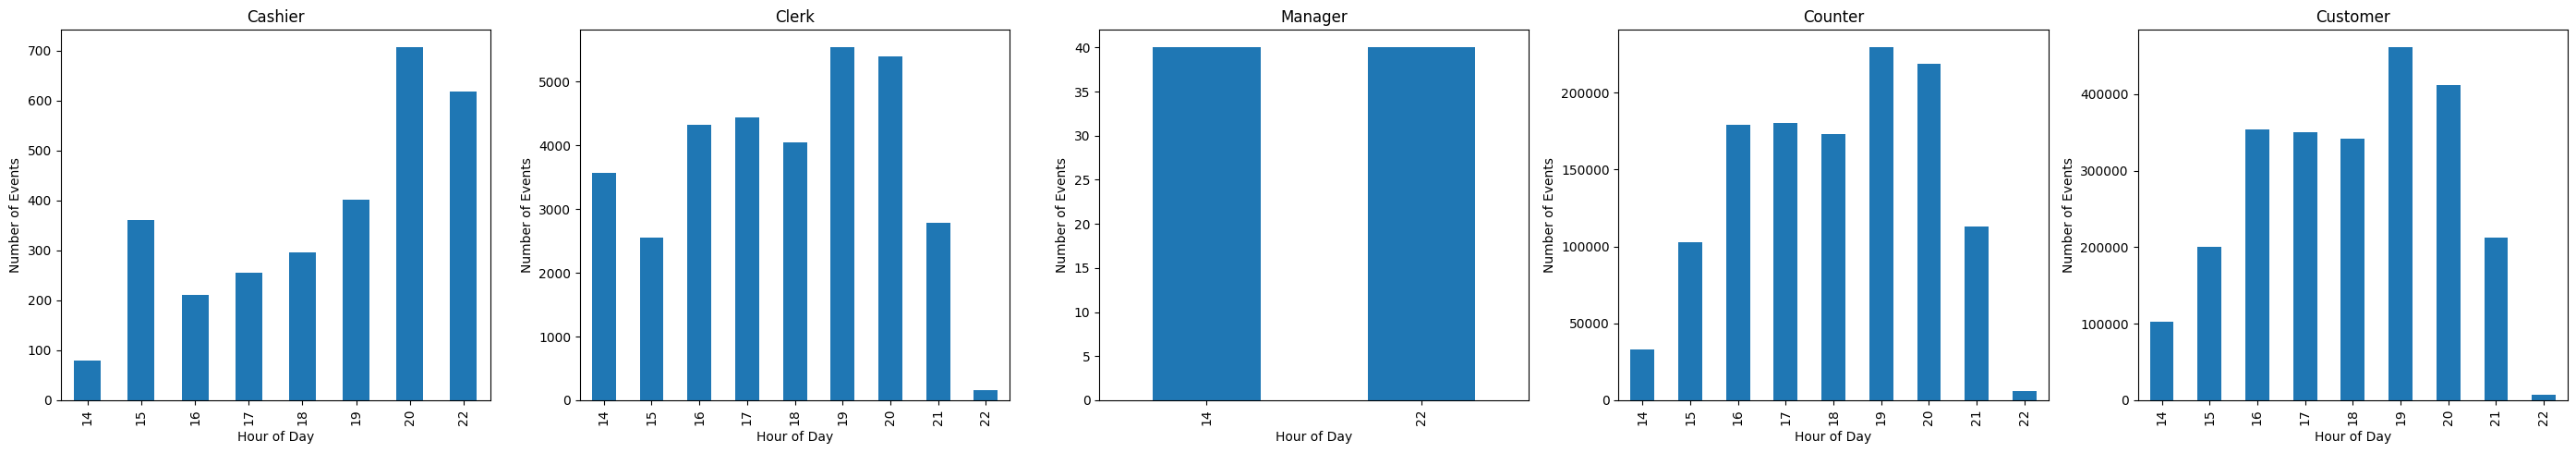

In [17]:
import matplotlib.pyplot as plt

# Add hour column to each log
log_df_cashier['hour'] = log_df_cashier['time:timestamp'].dt.hour
log_df_clerk['hour'] = log_df_clerk['time:timestamp'].dt.hour
log_df_manager['hour'] = log_df_manager['time:timestamp'].dt.hour
log_df_counter['hour'] = log_df_counter['time:timestamp'].dt.hour
log_df_customer['hour'] = log_df_customer['time:timestamp'].dt.hour

# Hourly arrivals/events
cashier_hourly = log_df_cashier.groupby('hour').size()
clerk_hourly = log_df_clerk.groupby('hour').size()
manager_hourly = log_df_manager.groupby('hour').size()
counter_hourly = log_df_counter.groupby('hour').size()
customer_hourly = log_df_customer.groupby('hour').size()

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

# Cashier
cashier_hourly.plot(kind='bar', ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Events")

# Clerk
clerk_hourly.plot(kind='bar', ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Events")

# Manager
manager_hourly.plot(kind='bar', ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Number of Events")

# Counter
counter_hourly.plot(kind='bar', ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Number of Events")

# Customer
customer_hourly.plot(kind='bar', ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Hour of Day")
axes[4].set_ylabel("Number of Events")

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

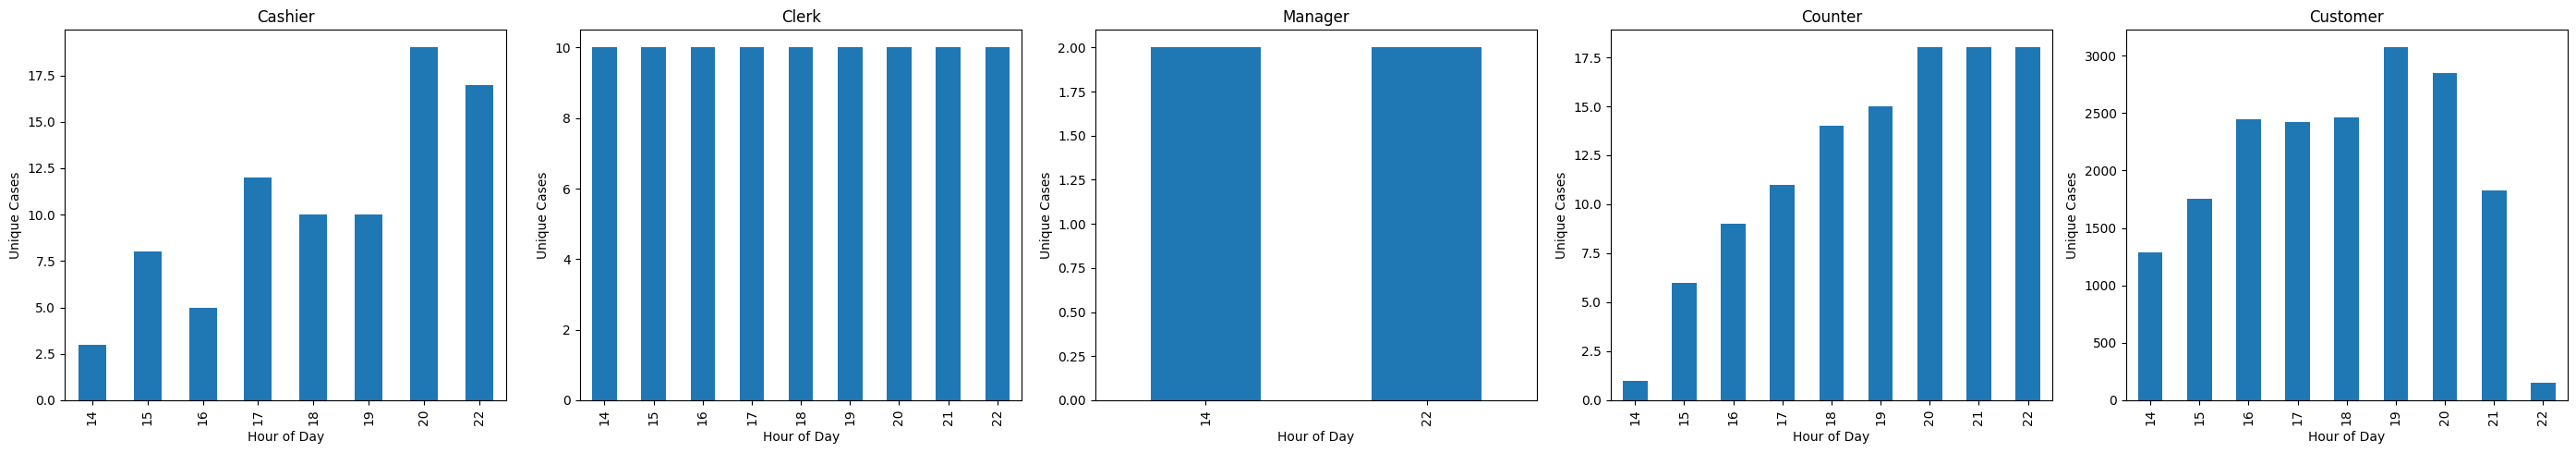

In [50]:
#cross checking with cases
import matplotlib.pyplot as plt

# Add hour column to each log
log_df_cashier['hour'] = (
    log_df_cashier['time:timestamp'].dt.hour
)

log_df_clerk['hour'] = (
    log_df_clerk['time:timestamp'].dt.hour
)

log_df_manager['hour'] = (
    log_df_manager['time:timestamp'].dt.hour
)

log_df_counter['hour'] = (
    log_df_counter['time:timestamp'].dt.hour
)

log_df_customer['hour'] = (
    log_df_customer['time:timestamp'].dt.hour
)

# -----------------------------------------
# UNIQUE CASES PER HOUR
# -----------------------------------------

cashier_hourly = (
    log_df_cashier.groupby('hour')
    ['case:concept:name']
    .nunique()
)

clerk_hourly = (
    log_df_clerk.groupby('hour')
    ['case:concept:name']
    .nunique()
)

manager_hourly = (
    log_df_manager.groupby('hour')
    ['case:concept:name']
    .nunique()
)

counter_hourly = (
    log_df_counter.groupby('hour')
    ['case:concept:name']
    .nunique()
)

customer_hourly = (
    log_df_customer.groupby('hour')
    ['case:concept:name']
    .nunique()
)

# -----------------------------------------
# CREATE SUBPLOTS
# -----------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(28,5)
)

# Cashier
cashier_hourly.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Cashier")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Unique Cases")

# Clerk
clerk_hourly.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Clerk")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Unique Cases")

# Manager
manager_hourly.plot(
    kind='bar',
    ax=axes[2]
)

axes[2].set_title("Manager")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Unique Cases")

# Counter
counter_hourly.plot(
    kind='bar',
    ax=axes[3]
)

axes[3].set_title("Counter")
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Unique Cases")

# Customer
customer_hourly.plot(
    kind='bar',
    ax=axes[4]
)

axes[4].set_title("Customer")
axes[4].set_xlabel("Hour of Day")
axes[4].set_ylabel("Unique Cases")

# Layout
plt.tight_layout()

# Show plots
plt.show()

**1. More counters are open than required indicating Resource wastage**

**2. The inflow of customers at 17:00 is lesser than 16:00 but we go on to open more counters which does not make sense**



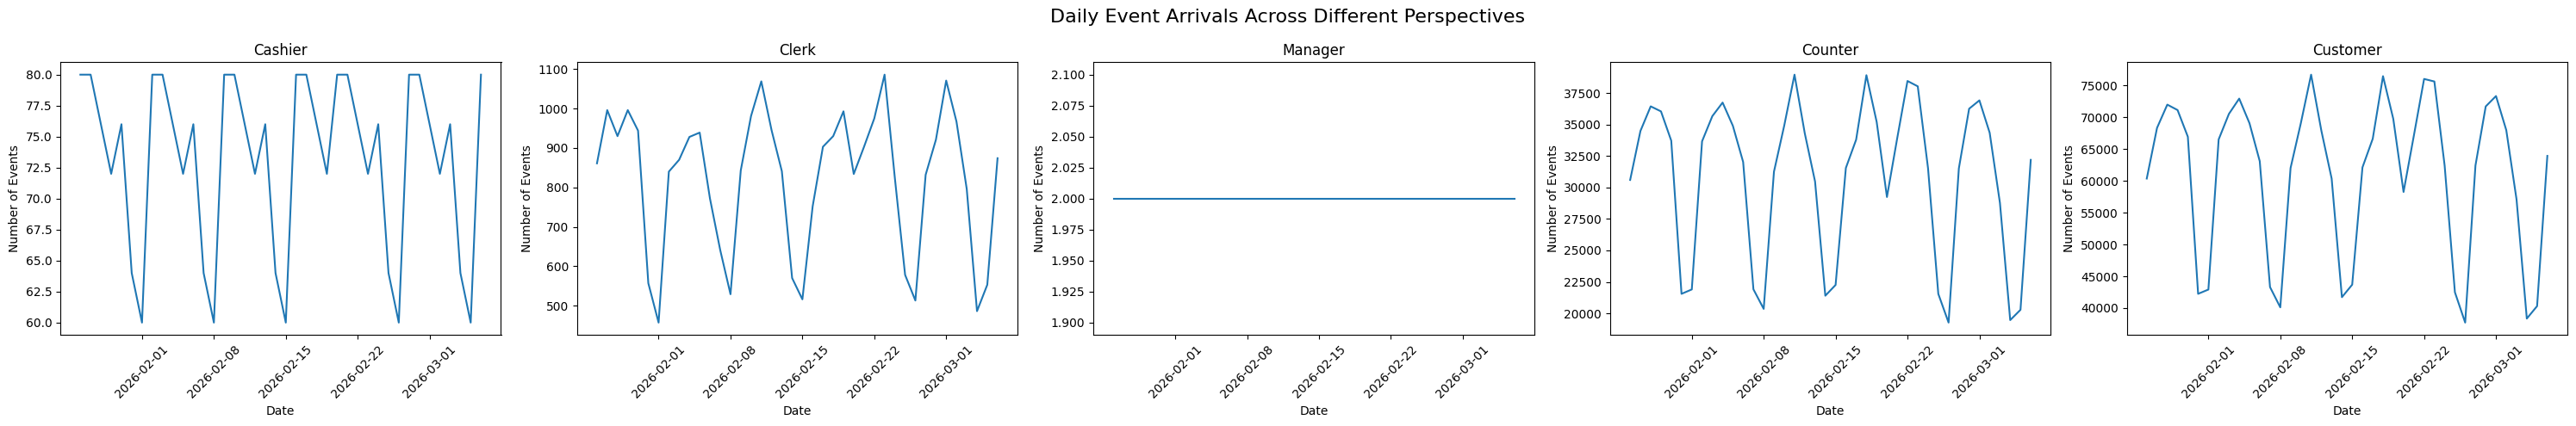

In [20]:

# Add date column to each log
log_df_cashier['date'] = log_df_cashier['time:timestamp'].dt.date
log_df_clerk['date'] = log_df_clerk['time:timestamp'].dt.date
log_df_manager['date'] = log_df_manager['time:timestamp'].dt.date
log_df_counter['date'] = log_df_counter['time:timestamp'].dt.date
log_df_customer['date'] = log_df_customer['time:timestamp'].dt.date

# Daily arrivals/events
cashier_daily = log_df_cashier.groupby('date').size()
clerk_daily = log_df_clerk.groupby('date').size()
manager_daily = log_df_manager.groupby('date').size()
counter_daily = log_df_counter.groupby('date').size()
customer_daily = log_df_customer.groupby('date').size()

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

# Cashier
cashier_daily.plot(ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Events")
axes[0].tick_params(axis='x', rotation=45)

# Clerk
clerk_daily.plot(ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Events")
axes[1].tick_params(axis='x', rotation=45)

# Manager
manager_daily.plot(ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Number of Events")
axes[2].tick_params(axis='x', rotation=45)

# Counter
counter_daily.plot(ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Number of Events")
axes[3].tick_params(axis='x', rotation=45)

# Customer
customer_daily.plot(ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Date")
axes[4].set_ylabel("Number of Events")
axes[4].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle("Daily Event Arrivals Across Different Perspectives", fontsize=16)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

**South (Zuid) Region: February 14 to February 22, 2026 more work due to spring break and carnival.For the South and Central regions, this holiday aligns precisely with Carnival 2026, which takes place from Sunday, February 15 through Tuesday, February 17, 2026. These exact dates align with festivities**

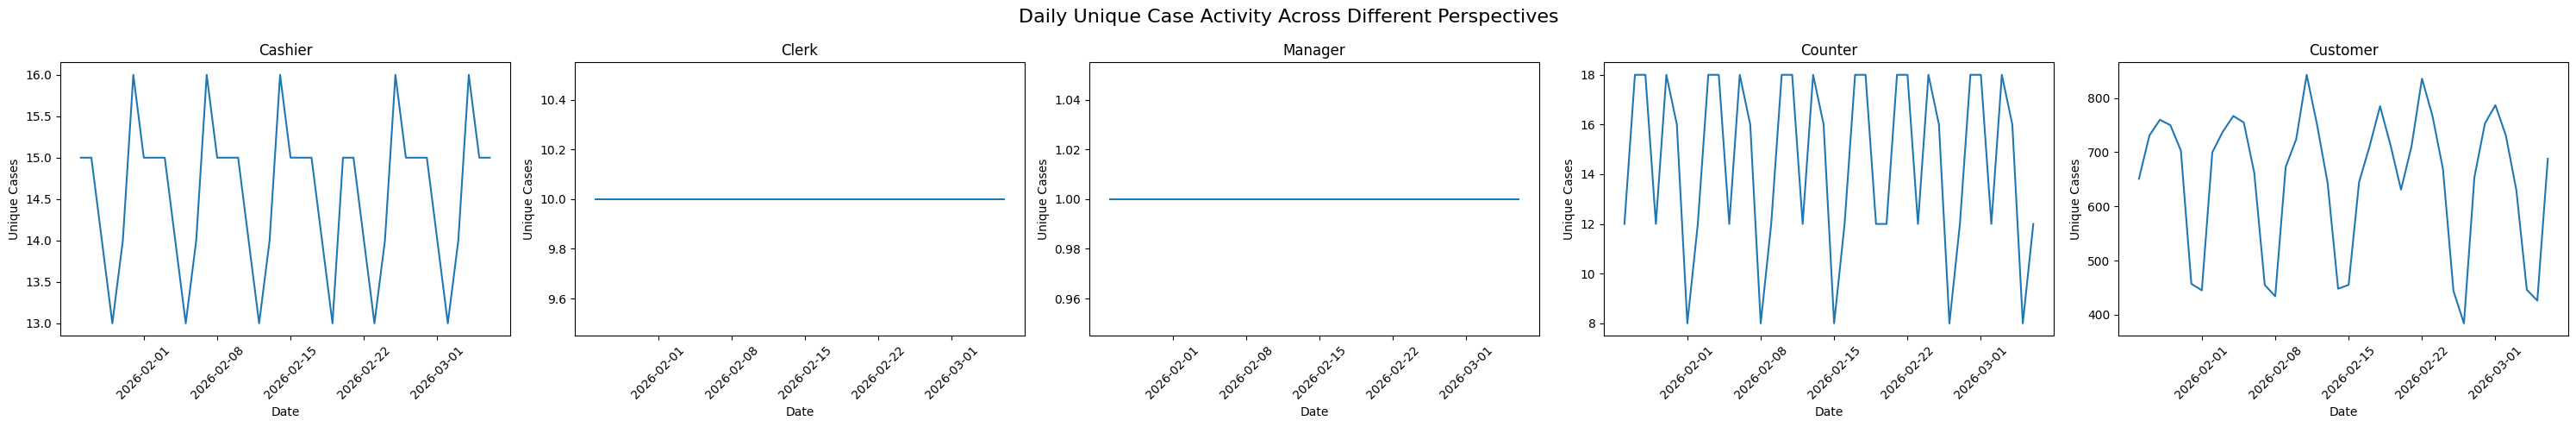

In [21]:
# Cross checking with cases
import matplotlib.pyplot as plt

# Add date column to each log
log_df_cashier['date'] = (
    log_df_cashier['time:timestamp'].dt.date
)

log_df_clerk['date'] = (
    log_df_clerk['time:timestamp'].dt.date
)

log_df_manager['date'] = (
    log_df_manager['time:timestamp'].dt.date
)

log_df_counter['date'] = (
    log_df_counter['time:timestamp'].dt.date
)

log_df_customer['date'] = (
    log_df_customer['time:timestamp'].dt.date
)

# ------------------------------------------------
# DAILY UNIQUE CASES
# ------------------------------------------------

cashier_daily = (
    log_df_cashier.groupby('date')
    ['case:concept:name']
    .nunique()
)

clerk_daily = (
    log_df_clerk.groupby('date')
    ['case:concept:name']
    .nunique()
)

manager_daily = (
    log_df_manager.groupby('date')
    ['case:concept:name']
    .nunique()
)

counter_daily = (
    log_df_counter.groupby('date')
    ['case:concept:name']
    .nunique()
)

customer_daily = (
    log_df_customer.groupby('date')
    ['case:concept:name']
    .nunique()
)

# ------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(30,5)
)

# Cashier
cashier_daily.plot(ax=axes[0])

axes[0].set_title("Cashier")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Unique Cases")

axes[0].tick_params(
    axis='x',
    rotation=45
)

# Clerk
clerk_daily.plot(ax=axes[1])

axes[1].set_title("Clerk")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Unique Cases")

axes[1].tick_params(
    axis='x',
    rotation=45
)

# Manager
manager_daily.plot(ax=axes[2])

axes[2].set_title("Manager")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Unique Cases")

axes[2].tick_params(
    axis='x',
    rotation=45
)

# Counter
counter_daily.plot(ax=axes[3])

axes[3].set_title("Counter")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Unique Cases")

axes[3].tick_params(
    axis='x',
    rotation=45
)

# Customer
customer_daily.plot(ax=axes[4])

axes[4].set_title("Customer")
axes[4].set_xlabel("Date")
axes[4].set_ylabel("Unique Cases")

axes[4].tick_params(
    axis='x',
    rotation=45
)

# Main title
fig.suptitle(
    "Daily Unique Case Activity Across Different Perspectives",
    fontsize=16
)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

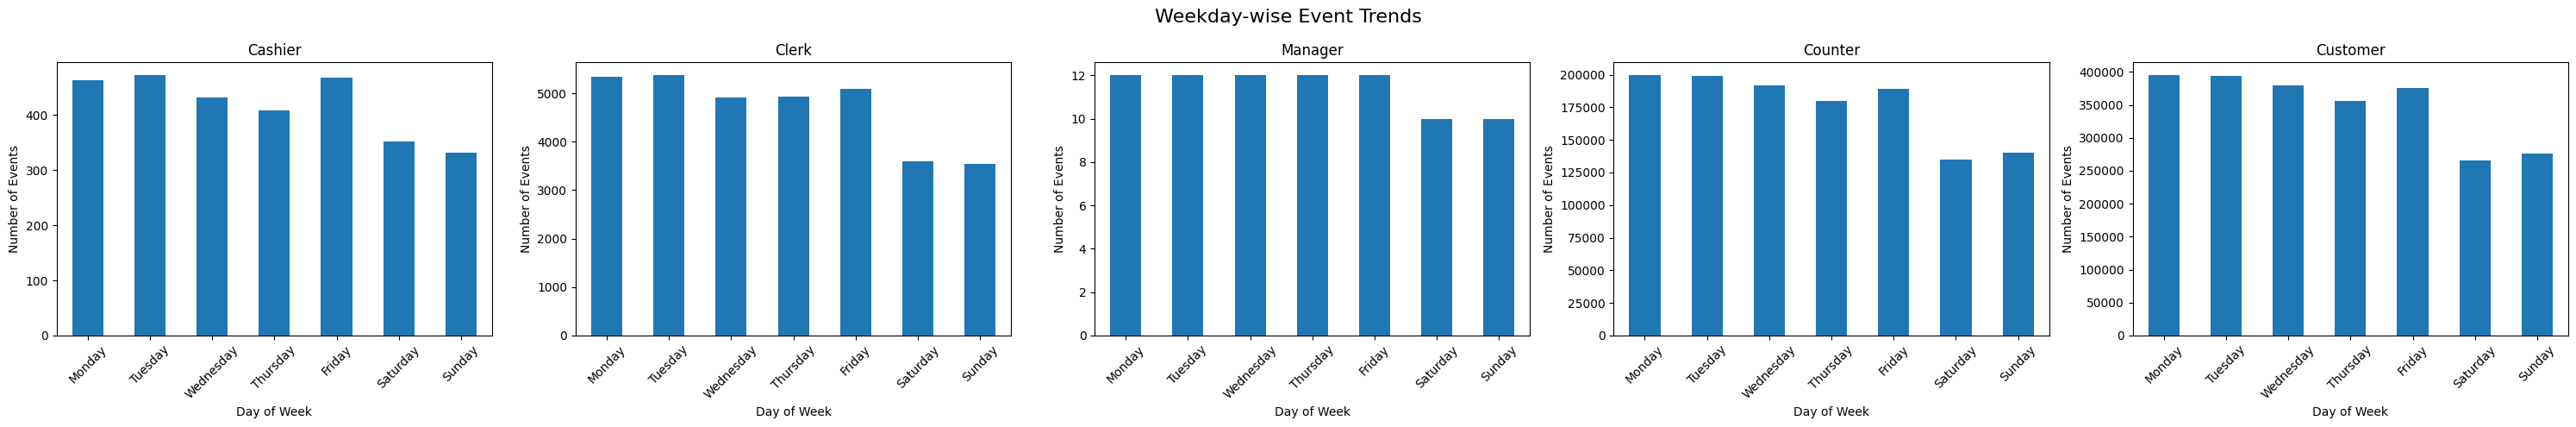

In [22]:


# Add weekday column to each log
log_df_cashier['weekday'] = log_df_cashier['time:timestamp'].dt.day_name()
log_df_clerk['weekday'] = log_df_clerk['time:timestamp'].dt.day_name()
log_df_manager['weekday'] = log_df_manager['time:timestamp'].dt.day_name()
log_df_counter['weekday'] = log_df_counter['time:timestamp'].dt.day_name()
log_df_customer['weekday'] = log_df_customer['time:timestamp'].dt.day_name()

# Define correct weekday order
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Count events by weekday and reorder
cashier_weekday = (
    log_df_cashier.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

clerk_weekday = (
    log_df_clerk.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

manager_weekday = (
    log_df_manager.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

counter_weekday = (
    log_df_counter.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

customer_weekday = (
    log_df_customer.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# Create subplots
fig, axes = plt.subplots(1, 5, figsize=(30, 5))

# Cashier
cashier_weekday.plot(kind='bar', ax=axes[0])
axes[0].set_title("Cashier")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Events")
axes[0].tick_params(axis='x', rotation=45)

# Clerk
clerk_weekday.plot(kind='bar', ax=axes[1])
axes[1].set_title("Clerk")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Events")
axes[1].tick_params(axis='x', rotation=45)

# Manager
manager_weekday.plot(kind='bar', ax=axes[2])
axes[2].set_title("Manager")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Number of Events")
axes[2].tick_params(axis='x', rotation=45)

# Counter
counter_weekday.plot(kind='bar', ax=axes[3])
axes[3].set_title("Counter")
axes[3].set_xlabel("Day of Week")
axes[3].set_ylabel("Number of Events")
axes[3].tick_params(axis='x', rotation=45)

# Customer
customer_weekday.plot(kind='bar', ax=axes[4])
axes[4].set_title("Customer")
axes[4].set_xlabel("Day of Week")
axes[4].set_ylabel("Number of Events")
axes[4].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle("Weekday-wise Event Trends", fontsize=16)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

Why are there less events taking place on Weekend should the Supermarket not be more busy on weekends?

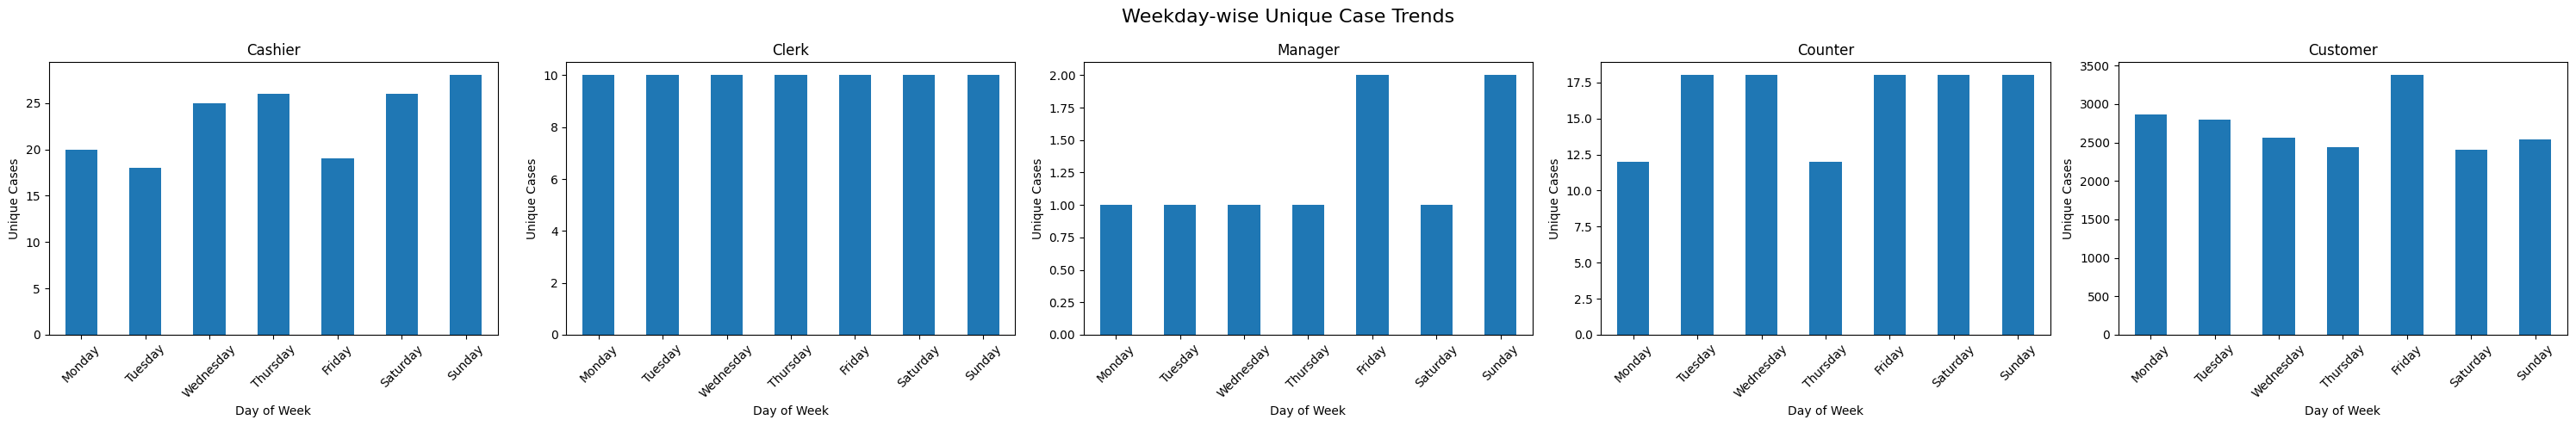

In [23]:
#cross checing with cse wie analysis as well
import matplotlib.pyplot as plt

# Add weekday column to each log
log_df_cashier['weekday'] = (
    log_df_cashier['time:timestamp']
    .dt.day_name()
)

log_df_clerk['weekday'] = (
    log_df_clerk['time:timestamp']
    .dt.day_name()
)

log_df_manager['weekday'] = (
    log_df_manager['time:timestamp']
    .dt.day_name()
)

log_df_counter['weekday'] = (
    log_df_counter['time:timestamp']
    .dt.day_name()
)

log_df_customer['weekday'] = (
    log_df_customer['time:timestamp']
    .dt.day_name()
)

# ------------------------------------------------
# Correct weekday order
# ------------------------------------------------

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# ------------------------------------------------
# UNIQUE CASES BY WEEKDAY
# ------------------------------------------------

cashier_weekday = (
    log_df_cashier.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

clerk_weekday = (
    log_df_clerk.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

manager_weekday = (
    log_df_manager.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

counter_weekday = (
    log_df_counter.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

customer_weekday = (
    log_df_customer.groupby('weekday')
    ['case:concept:name']
    .nunique()
    .reindex(weekday_order)
)

# ------------------------------------------------
# CREATE SUBPLOTS
# ------------------------------------------------

fig, axes = plt.subplots(
    1, 5,
    figsize=(30,5)
)

# Cashier
cashier_weekday.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Cashier")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Unique Cases")

axes[0].tick_params(
    axis='x',
    rotation=45
)

# Clerk
clerk_weekday.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Clerk")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Unique Cases")

axes[1].tick_params(
    axis='x',
    rotation=45
)

# Manager
manager_weekday.plot(
    kind='bar',
    ax=axes[2]
)

axes[2].set_title("Manager")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Unique Cases")

axes[2].tick_params(
    axis='x',
    rotation=45
)

# Counter
counter_weekday.plot(
    kind='bar',
    ax=axes[3]
)

axes[3].set_title("Counter")
axes[3].set_xlabel("Day of Week")
axes[3].set_ylabel("Unique Cases")

axes[3].tick_params(
    axis='x',
    rotation=45
)

# Customer
customer_weekday.plot(
    kind='bar',
    ax=axes[4]
)

axes[4].set_title("Customer")
axes[4].set_xlabel("Day of Week")
axes[4].set_ylabel("Unique Cases")

axes[4].tick_params(
    axis='x',
    rotation=45
)

# Main title
fig.suptitle(
    "Weekday-wise Unique Case Trends",
    fontsize=16
)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

In [24]:
import pandas as pd

# Ensure timestamp is datetime
log_df_cashier['time:timestamp'] = pd.to_datetime(
    log_df_cashier['time:timestamp']
)

# Extract date and weekday
log_df_cashier['date'] = log_df_cashier['time:timestamp'].dt.date
log_df_cashier['weekday'] = log_df_cashier['time:timestamp'].dt.day_name()

# Keep only weekends
weekend_df = log_df_cashier[
    log_df_cashier['weekday'].isin(['Saturday', 'Sunday'])
]

#Weekdays
weekday_df = log_df_cashier[
    log_df_cashier['weekday'].isin([
        'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'
    ])
]
# Find opening and closing times per day
weekend_hours = weekend_df.groupby('date')['time:timestamp'].agg(
    opening_time='min',
    closing_time='max'
)
#Find opening and closing times per day
weekday_hours = weekday_df.groupby('date')['time:timestamp'].agg(  
    opening_time='min',
    closing_time='max'
)

# Compute duration
weekend_hours['open_duration'] = (
    weekend_hours['closing_time']
    - weekend_hours['opening_time']
)

# Convert duration to hours
weekend_hours['open_duration_hours'] = (
    weekend_hours['open_duration'].dt.total_seconds() / 3600
)

#Compute duration
weekday_hours['open_duration'] = (
    weekday_hours['closing_time']
    - weekday_hours['opening_time']
)

# Convert duration to hours
weekday_hours['open_duration_hours'] = (
    weekday_hours['open_duration'].dt.total_seconds() / 3600
)



In [25]:
print(weekend_hours)

                        opening_time                     closing_time  \
date                                                                    
2026-01-31 2026-01-31 14:00:00+00:00 2026-01-31 22:04:07.956000+00:00   
2026-02-01 2026-02-01 14:00:00+00:00 2026-02-01 22:01:45.051000+00:00   
2026-02-07 2026-02-07 14:00:00+00:00        2026-02-07 22:00:00+00:00   
2026-02-08 2026-02-08 14:00:00+00:00 2026-02-08 22:05:50.433000+00:00   
2026-02-14 2026-02-14 14:00:00+00:00 2026-02-14 22:05:12.727000+00:00   
2026-02-15 2026-02-15 14:00:00+00:00 2026-02-15 22:07:29.910000+00:00   
2026-02-21 2026-02-21 14:00:00+00:00 2026-02-21 22:07:09.664000+00:00   
2026-02-22 2026-02-22 14:00:00+00:00 2026-02-22 22:09:03.237000+00:00   
2026-02-28 2026-02-28 14:00:00+00:00 2026-02-28 22:07:53.116000+00:00   
2026-03-01 2026-03-01 14:00:00+00:00 2026-03-01 22:02:51.305000+00:00   

                    open_duration  open_duration_hours  
date                                                    
2026-01-3

In [26]:
print(weekend_hours)

                        opening_time                     closing_time  \
date                                                                    
2026-01-31 2026-01-31 14:00:00+00:00 2026-01-31 22:04:07.956000+00:00   
2026-02-01 2026-02-01 14:00:00+00:00 2026-02-01 22:01:45.051000+00:00   
2026-02-07 2026-02-07 14:00:00+00:00        2026-02-07 22:00:00+00:00   
2026-02-08 2026-02-08 14:00:00+00:00 2026-02-08 22:05:50.433000+00:00   
2026-02-14 2026-02-14 14:00:00+00:00 2026-02-14 22:05:12.727000+00:00   
2026-02-15 2026-02-15 14:00:00+00:00 2026-02-15 22:07:29.910000+00:00   
2026-02-21 2026-02-21 14:00:00+00:00 2026-02-21 22:07:09.664000+00:00   
2026-02-22 2026-02-22 14:00:00+00:00 2026-02-22 22:09:03.237000+00:00   
2026-02-28 2026-02-28 14:00:00+00:00 2026-02-28 22:07:53.116000+00:00   
2026-03-01 2026-03-01 14:00:00+00:00 2026-03-01 22:02:51.305000+00:00   

                    open_duration  open_duration_hours  
date                                                    
2026-01-3

In [27]:
avg_duration = weekend_hours['open_duration_hours'].mean()

print("Average weekend opening duration:",
      round(avg_duration, 2), "hours")

Average weekend opening duration: 8.09 hours


In [30]:
avg_duration = weekday_hours['open_duration_hours'].mean()


print("Average weekday opening duration:",
      round(avg_duration, 2), "hours")

Average weekday opening duration: 8.1 hours


In [31]:
log_df_counter['case:concept:name'].unique()

array(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '2', '3',
       '4', '5', '6', '7', '8', '9'], dtype=object)

In [13]:
log_df_customer['cid'].unique()

array([nan,  0.,  7.,  3.,  1.,  6.,  8.,  2.,  5.,  4., 12., 11.,  9.,
       10., 13., 14., 17., 15., 16.])

In [33]:
import ast
import pandas as pd

# Function to compute queue length
def queue_length(q):
    
    # Skip NaN
    if pd.isna(q):
        return None
    
    # Convert string to list if needed
    if isinstance(q, str):
        q = ast.literal_eval(q)
    
    # Skip empty queues
    if len(q) == 0:
        return None
    
    # Return queue length
    return len(q)

# Create queue length column
log_df_counter['queue_length'] = (
    log_df_counter['q'].apply(queue_length)
)

# Remove empty queues
filtered_df = log_df_counter.dropna(
    subset=['queue_length']
)

# Keep only counter ID and queue length
result = filtered_df[
    ['case:concept:name', 'queue_length']
]

print(result.head(170000))

       case:concept:name  queue_length
0                      0          17.0
54                     0           1.0
55                     0           1.0
56                     0           1.0
57                     0           1.0
...                  ...           ...
581914                 2           1.0
581915                 2           1.0
581916                 2           1.0
581917                 2           1.0
581918                 2           1.0

[170000 rows x 2 columns]


In [66]:
log_df_customer_sorted.iloc[2000:2100]

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
2000,lRandom,Scan Item,NaN,NaN,NaN,complete,76.0,2026-02-10 18:22:40.107000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,76.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2001,lRandom,Scan Item,NaN,NaN,NaN,complete,75.0,2026-02-10 18:22:43.375000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,75.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2002,lRandom,Scan Item,NaN,NaN,NaN,complete,74.0,2026-02-10 18:22:45.862000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,74.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2003,lRandom,Scan Item,NaN,NaN,NaN,complete,73.0,2026-02-10 18:22:48.625000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,73.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
2004,lRandom,Scan Item,NaN,NaN,NaN,complete,72.0,2026-02-10 18:22:51.924000+00:00,Pin,"[(0,0,0,false),(1,0,0,true),(2,0,0,true),(3,1,...",...,72.0,[],0.0,0.0,0.0,1.0,8.0,False,NaN,1002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,lCust,Pickup Item,NaN,12.0,NaN,complete,60.0,2026-02-21 18:44:13.503000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2096,lCust,Pickup Item,NaN,13.0,NaN,complete,60.0,2026-02-21 18:44:17.233000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2097,lCust,Pickup Item,NaN,14.0,NaN,complete,60.0,2026-02-21 18:44:19.665000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002
2098,lCust,Pickup Item,NaN,15.0,NaN,complete,60.0,2026-02-21 18:44:22.126000+00:00,Pin,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002


In [77]:
log_df_counter_sorted.head(60)

,col,q,concept:name,iMI,d,mC,caid,lifecycle:transition,mI,time:timestamp,...,p,s,pc,id,items,b,clid,cnt,x,case:concept:name
0,"[(0,0,0,false),(1,0,0,false),(2,0,0,false),(3,...","[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]",Open counter,-1.0,4.0,0.0,2.0,complete,0.0,2026-01-26 14:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",[],Enter Queue,0.0,NaN,0.0,NaN,complete,0.0,2026-01-26 14:03:27.627000+00:00,...,Pin,lItem,0.0,0.0,58.0,NaN,NaN,NaN,NaN,0
2,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,58.0,2026-01-26 14:03:30.466000+00:00,...,Pin,lItem,0.0,0.0,58.0,False,NaN,NaN,NaN,0
3,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,57.0,2026-01-26 14:03:34.164000+00:00,...,Pin,lItem,0.0,0.0,57.0,True,NaN,NaN,NaN,0
4,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,56.0,2026-01-26 14:03:37.690000+00:00,...,Pin,lItem,1.0,0.0,56.0,False,NaN,NaN,NaN,0
5,NaN,NaN,Start Price Check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:37.690000+00:00,...,NaN,NaN,NaN,0.0,NaN,NaN,105.0,NaN,NaN,0
6,"[(0,1,55,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,55.0,2026-01-26 14:03:40.586000+00:00,...,Pin,lItem,1.0,0.0,55.0,False,NaN,NaN,NaN,0
7,"[(0,1,54,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,54.0,2026-01-26 14:03:42.967000+00:00,...,Pin,lItem,1.0,0.0,54.0,False,NaN,NaN,NaN,0
8,NaN,[],End price check,NaN,NaN,NaN,NaN,complete,NaN,2026-01-26 14:03:44.083000+00:00,...,NaN,NaN,1.0,0.0,NaN,NaN,105.0,NaN,NaN,0
9,"[(0,1,53,true),(1,0,0,false),(2,0,0,false),(3,...",[],Scan Item,0.0,NaN,1.0,NaN,complete,53.0,2026-01-26 14:03:45.388000+00:00,...,Pin,lItem,0.0,0.0,53.0,False,NaN,NaN,NaN,0


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
]

# Count unique customers per counter
customers_per_counter = (
    enter_queue_df.groupby('case:concept:name')['id']
    .nunique()
)

print(customers_per_counter)

case:concept:name
0     2726
1     1519
10    1276
11    1428
12     884
13     816
14     521
15     462
16     341
17     317
2     1672
3     1504
4     1502
5     1595
6     1778
7     1754
8     1606
9     1316
Name: id, dtype: int64


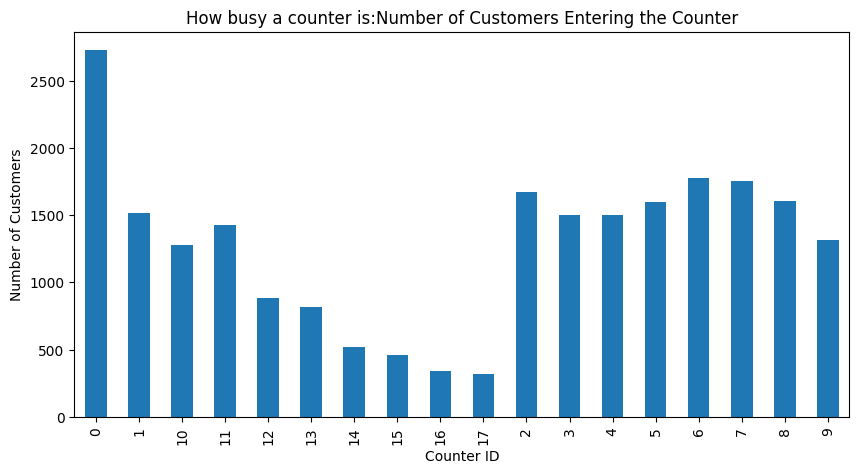

In [37]:
customers_per_counter.plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel("Counter ID")
plt.ylabel("Number of Customers")
plt.title("How busy a counter is:Number of Customers Entering the Counter")

plt.show()

(The timings and peak were extracted from Line Chart below)
1) Counter 0 opens at 14:00 (all day) peak observed at 14:00 (greatest) then at 20:00 in this counter
2) Counter 1-5 open at 15:00
3) Counter 6,7,8 open at 16:00   peak observed at 19:00 in this counter; follow same pattern
4) Counter 10,9 open at 17:00 but twice as many customers at counter 9 as opposed to counter 10 at 17:00 peak at 19:00
4) Counter 11,12, 13 opens at 18:00 peak at 19:00 customers at 500,350,300 at peak
6) Counter 14 opens at 19:00 peaks at 20:00
7) Counter 15,16,17 opens at 20:00 but more customers flock to 15 (300) as compared to 16(200).
-----------------------------------------------------------------------------------------------
2) Counters 12-17 are not fully utilised because the averages remain stable while customers drop showcasing wasted resources
3) Counters 14–16 serve comparatively fewer customers because they are activated only during late peak-demand intervals. However, their average queue lengths remain relatively high because their operational periods coincide almost exclusively with the supermarket’s highest congestion window between 19:00 and 20:00.



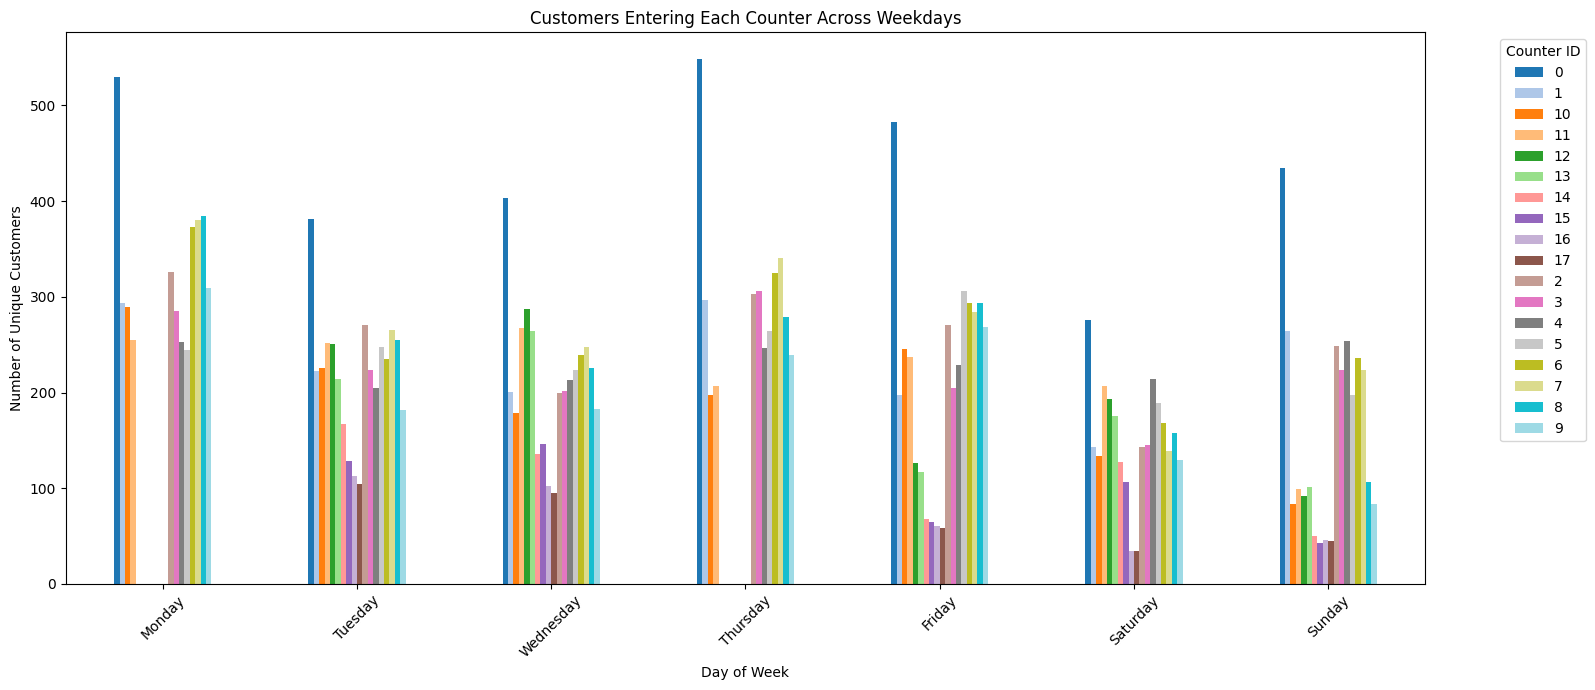

In [43]:
#Doing a weekday-wise analysis of the customers entering each counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Keep only Enter Queue events
enter_queue_df_weekday = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Correct weekday ordering
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Count unique customers per weekday per counter
customers_per_counter_weekday = (
    enter_queue_df_weekday.groupby(
        ['weekday', 'case:concept:name']
    )['id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)
# Number of counters
num_counters = len(
    customers_per_counter_weekday.columns
)
# Generate distinct colors
colors = plt.cm.tab20(
    np.linspace(0, 1, num_counters)
)
# Visualize
customers_per_counter_weekday.plot(
    kind='bar',
    figsize=(16,7), color=colors
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Unique Customers")

plt.title(
    "Customers Entering Each Counter Across Weekdays"
)

plt.legend(
    title="Counter ID",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Extract hour
enter_queue_df['hour'] = (
    enter_queue_df['time:timestamp'].dt.hour
)

# Count unique customers per hour per counter
hourly_customers = (
    enter_queue_df.groupby(
        ['hour', 'case:concept:name']
    )['id']
    .nunique()
    .unstack(fill_value=0)
)

print(hourly_customers)

case:concept:name    0    1   10   11   12   13   14   15   16   17    2    3  \
hour                                                                            
14                 734    0    0    0    0    0    0    0    0    0    0    0   
15                 349  370    0    0    0    0    0    0    0    0  358  393   
16                 417  423    0    0    0    0    0    0    0    0  423  446   
17                 352  324  189    0    0    0    0    0    0    0  281  302   
18                 143  270  255  270  154  120    0    0    0    0  300  252   
19                 265   62  516  524  343  306   83    0    0    0  117   71   
20                 461  104  226  426  277  265  295  304  219  210  173   72   
21                 254   46  129  249  144  142  148  167  120  109   77   30   
22                  16    2    3    8    3    5    6    4    7    3    2    0   

case:concept:name    4    5    6    7    8    9  
hour                                             
14      

In [45]:
import pandas as pd
import plotly.express as px

# Ensure timestamp is datetime
log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

# Keep only "Enter Queue" events
enter_queue_df = log_df_counter[
    log_df_counter['concept:name'] == 'Enter Queue'
].copy()

# Extract hour
enter_queue_df['hour'] = (
    enter_queue_df['time:timestamp'].dt.hour
)

# Count unique customers per hour per counter
hourly_customers = (
    enter_queue_df.groupby(
        ['hour', 'case:concept:name']
    )['id']
    .nunique()
    .reset_index(name='customer_count')
)

# Convert counter IDs to string for cleaner legend
hourly_customers['case:concept:name'] = (
    hourly_customers['case:concept:name'].astype(str)
)

# Interactive plot
fig = px.line(
    hourly_customers,
    x='hour',
    y='customer_count',
    color='case:concept:name',
    markers=True,
    title='Hourly Customer Arrivals per Counter',
    labels={
        'hour': 'Hour of Day',
        'customer_count': 'Number of Unique Customers',
        'case:concept:name': 'Counter ID'
    }
)

# Improve layout
fig.update_layout(
    hovermode='x unified',
    legend_title='Counter ID'
)

# Show interactive graph
fig.show()

1) Counter 0 opens at 14:00 (all day) peak observed at 14:00 (greatest) then at 20:00 in this counter however only counters 6,7,8 experience peak at 20:00 but only a decline observed  3,4,5
2) Counter 1-5 open at 15:00
3) Counter 6,7,8 open at 16:00   peak observed at 19:00 in this counter; follow same pattern
4) Counter 10,9 open at 17:00 but twice as many customers at counter 9 as opposed to counter 10 at 17:00 peak at 19:00; 
5) Counter 11,12, 13 opens at 18:00 peak at 19:00 customers at 500,350,300 at peak
6) Counter 14 opens at 19:00 peaks at 20:00
7) Counter 15,16,17 opens at 20:00 but more customers flock to 15 (300) as compared to 16(200).
8) Counters 20:00-22:00 not being fully utilised
----------------------------------------------------------------------------------------------------------------------

1) Counter 9,10:
spatial preference,
shorter walking distance,
cashier efficiency,
queue perception,
customer routing bias. 
This is valuable managerial insight because:
merely opening counters does not guarantee balanced utilization.

2) Counter 15 this may indicate:
customer preference,
physical positioning,
cashier speed reputation,



Key Insights You Can Report

You can formally state:

1) Counter 0 acts as the primary always-open counter and experiences the highest sustained congestion.
2) Counter activation follows a demand-driven temporal strategy, with additional counters progressively opening during later hours.
3) Peak supermarket activity occurs around 19:00–20:00.
4) Customer distribution across counters is uneven despite simultaneous availability of counters.
5) Some counters exhibit disproportionately high queue lengths relative to customer volume, suggesting efficiency differences.
6) Late-opened counters receive significantly lower traffic, indicating possible overprovisioning during late evening periods.

**Temporal Anlaysis-Visualising Cart Abandonments**


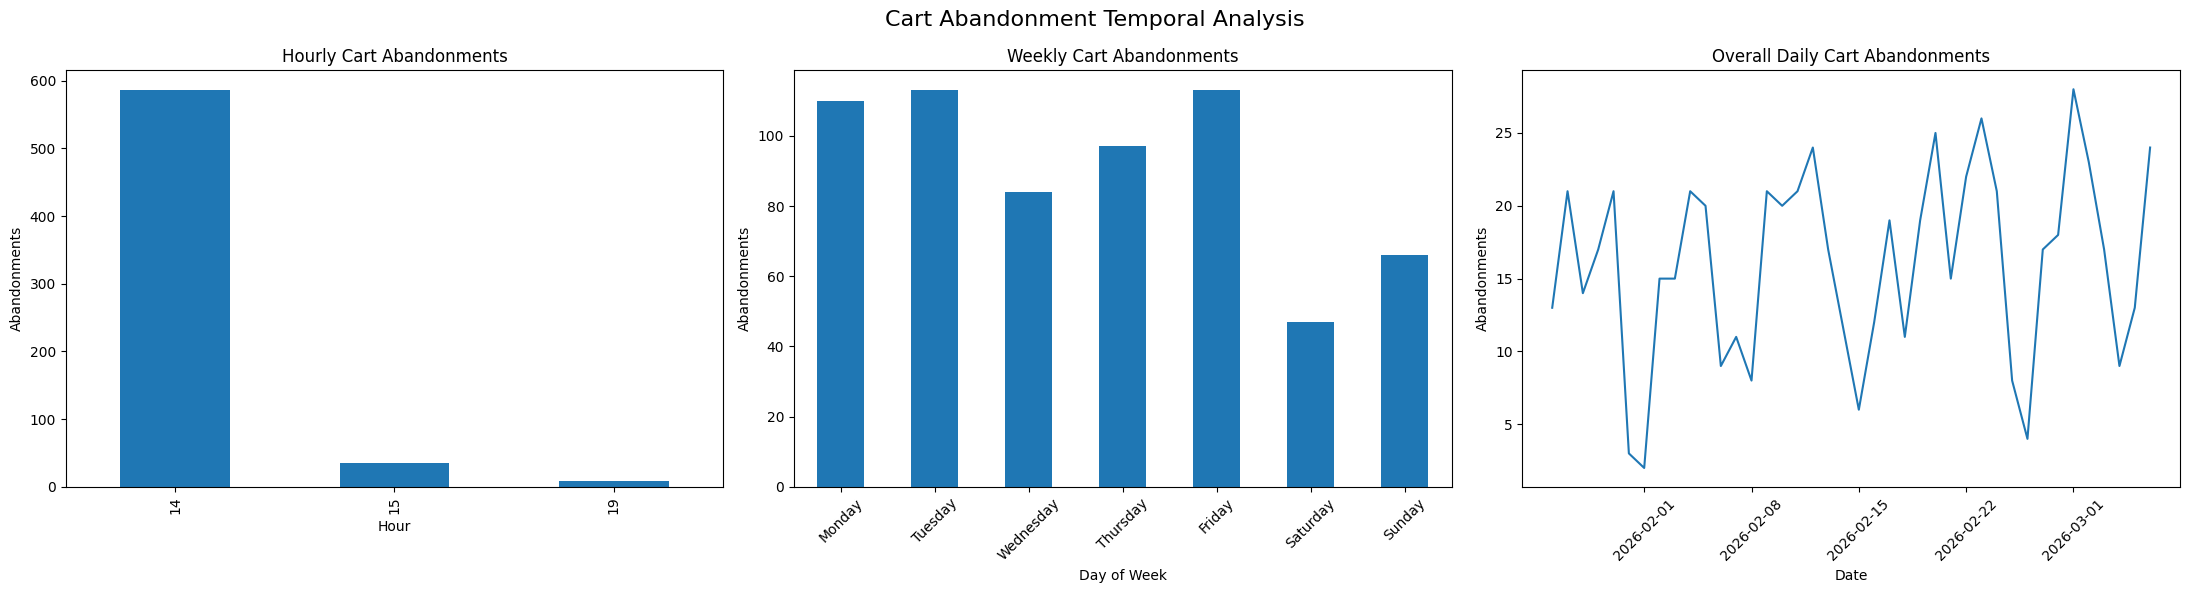

In [46]:


# Ensure timestamp is datetime
log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

# Filter abandonment events
abandonments = log_df_customer[
    log_df_customer['concept:name'] == 'Abandon cart and leave'
].copy()

# -----------------------------
# HOURLY ANALYSIS
# -----------------------------
abandonments['hour'] = (
    abandonments['time:timestamp'].dt.hour
)

hourly_abandonments = (
    abandonments.groupby('hour')
    .size()
)

# -----------------------------
# WEEKDAY ANALYSIS
# -----------------------------
abandonments['weekday'] = (
    abandonments['time:timestamp'].dt.day_name()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekly_abandonments = (
    abandonments.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# -----------------------------
# DAILY / OVERALL TREND
# -----------------------------
abandonments['date'] = (
    abandonments['time:timestamp'].dt.date
)

daily_abandonments = (
    abandonments.groupby('date')
    .size()
)

# -----------------------------
# VISUALIZATION
# Each plot has independent scale
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(22,6))

# Hourly
hourly_abandonments.plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Hourly Cart Abandonments")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Abandonments")

# Weekly
weekly_abandonments.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Weekly Cart Abandonments")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Abandonments")

axes[1].tick_params(axis='x', rotation=45)

# Daily / Overall
daily_abandonments.plot(
    ax=axes[2]
)

axes[2].set_title("Overall Daily Cart Abandonments")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Abandonments")

axes[2].tick_params(axis='x', rotation=45)

# Main title
fig.suptitle(
    "Cart Abandonment Temporal Analysis",
    fontsize=16
)

# Separate scales automatically maintained
plt.tight_layout()

plt.show()

1) Wednesday (essential buying, task oriented, maybe promotions as well) and Saturday (because more time) Lowest Abandonments
2) Carnival, Holiday Season a lot of cart Abandonments even on Sunday which is otherwise the lowest
3) Tuesday and Friday very high abandonments
4) Limited Counter at 14:00 can be reason why abandonement is so high here 
5) Counters open at 15:00, 19:00 so that long queues cannot be the sole reason of cart abandonment there
6) Similar customers on Sunday and Saturday but Sunday has more abandonments esp 22/02/2026 and 01/03/2026
7) By Sunday, popular items may be out of stock, causing shoppers to abandon their entire cart, particularly for "meal-for-tonight" or "special-occasion" missions.


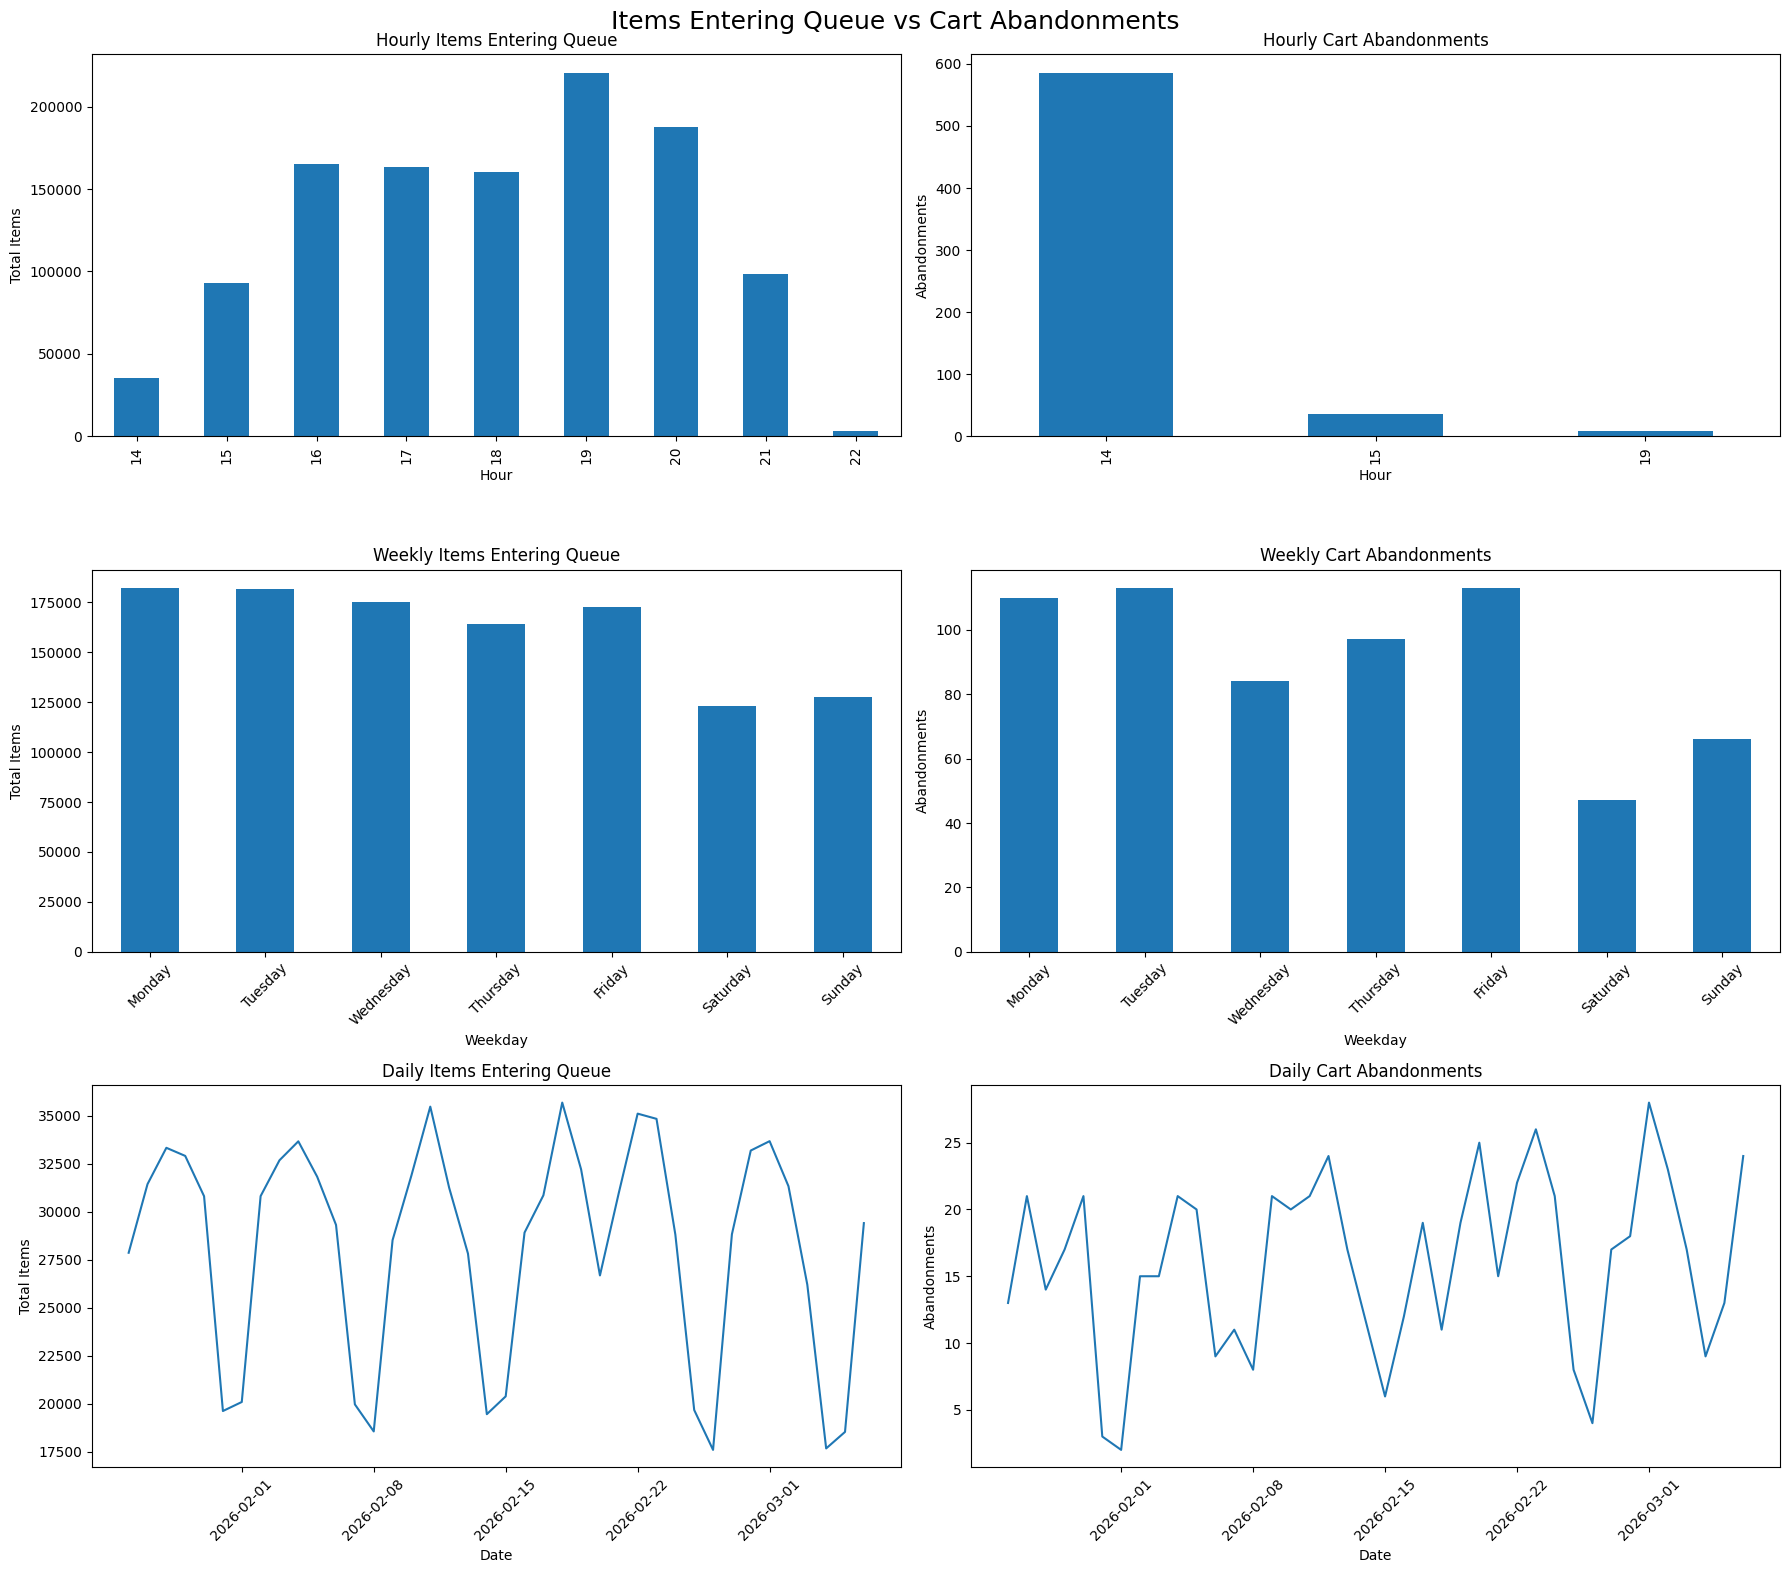

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

log_df_customer_sorted['time:timestamp'] = pd.to_datetime(
    log_df_customer_sorted['time:timestamp']
)

# ---------------------------------------------------
# ENTER QUEUE EVENTS
# ---------------------------------------------------
enter_queue = log_df_customer[
    log_df_customer['concept:name'] == 'Enter Queue'
].copy()

# ---------------------------------------------------
# ABANDONMENT EVENTS
# ---------------------------------------------------
abandonments = log_df_customer_sorted[
    log_df_customer_sorted['concept:name'] == 'Abandon cart and leave'
].copy()

# ===================================================
# HOURLY ANALYSIS
# ===================================================

# Hour extraction
enter_queue['hour'] = (
    enter_queue['time:timestamp'].dt.hour
)

abandonments['hour'] = (
    abandonments['time:timestamp'].dt.hour
)

# Total items entering queue hourly
hourly_items = (
    enter_queue.groupby('hour')['items']
    .sum()
)

# Hourly abandonments
hourly_abandonments = (
    abandonments.groupby('hour')
    .size()
)

# ===================================================
# WEEKDAY ANALYSIS
# ===================================================

# Weekday extraction
enter_queue['weekday'] = (
    enter_queue['time:timestamp'].dt.day_name()
)

abandonments['weekday'] = (
    abandonments['time:timestamp'].dt.day_name()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Weekly items
weekly_items = (
    enter_queue.groupby('weekday')['items']
    .sum()
    .reindex(weekday_order)
)

# Weekly abandonments
weekly_abandonments = (
    abandonments.groupby('weekday')
    .size()
    .reindex(weekday_order)
)

# ===================================================
# DAILY ANALYSIS
# ===================================================

# Date extraction
enter_queue['date'] = (
    enter_queue['time:timestamp'].dt.date
)

abandonments['date'] = (
    abandonments['time:timestamp'].dt.date
)

# Daily items
daily_items = (
    enter_queue.groupby('date')['items']
    .sum()
)

# Daily abandonments
daily_abandonments = (
    abandonments.groupby('date')
    .size()
)

# ===================================================
# VISUALIZATION
# Separate scales for each graph
# ===================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# ---------------- HOURLY ----------------

hourly_items.plot(
    kind='bar',
    ax=axes[0,0]
)

axes[0,0].set_title("Hourly Items Entering Queue")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Total Items")

hourly_abandonments.plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title("Hourly Cart Abandonments")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Abandonments")

# ---------------- WEEKLY ----------------

weekly_items.plot(
    kind='bar',
    ax=axes[1,0]
)

axes[1,0].set_title("Weekly Items Entering Queue")
axes[1,0].set_xlabel("Weekday")
axes[1,0].set_ylabel("Total Items")

axes[1,0].tick_params(axis='x', rotation=45)

weekly_abandonments.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Weekly Cart Abandonments")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Abandonments")

axes[1].tick_params(axis='x', rotation=45)

# ---------------- DAILY ----------------

daily_items.plot(
    ax=axes[2,0]
)

axes[2,0].set_title("Daily Items Entering Queue")
axes[2,0].set_xlabel("Date")
axes[2,0].set_ylabel("Total Items")

axes[2,0].tick_params(axis='x', rotation=45)

daily_abandonments.plot(
    ax=axes[2,1]
)

axes[2,1].set_title("Daily Cart Abandonments")
axes[2,1].set_xlabel("Date")
axes[2,1].set_ylabel("Abandonments")

axes[2,1].tick_params(axis='x', rotation=45)

# ---------------------------------------------------
# Main title
# ---------------------------------------------------
fig.suptitle(
    "Items Entering Queue vs Cart Abandonments",
    fontsize=18
)

plt.tight_layout()

plt.show()

## Hourly counter efficiency analysis

This cell computes, for each hour of day, the average number of unique customers, the average number of open counters, the average customers per open counter, and recommends the number of counters to open based on a target customers-per-counter threshold. It also plots the results and saves a CSV in `outputs/`.



COUNTER PERFORMANCE SUMMARY

            peak_customers  variability  active_hours  \
counter_id                                              
0                      734       203.81             9   
1                      423       167.96             8   
2                      423       155.19             8   
3                      446       175.61             7   
4                      430       159.13             7   
5                      379       154.88             7   
6                      533       190.05             6   
7                      548       188.11             7   
8                      509       180.33             7   
9                      481       178.26             6   
10                     516       173.82             6   
11                     524       208.75             5   
12                     343       134.44             5   
13                     306       122.69             5   
14                     295       102.72             4   
1

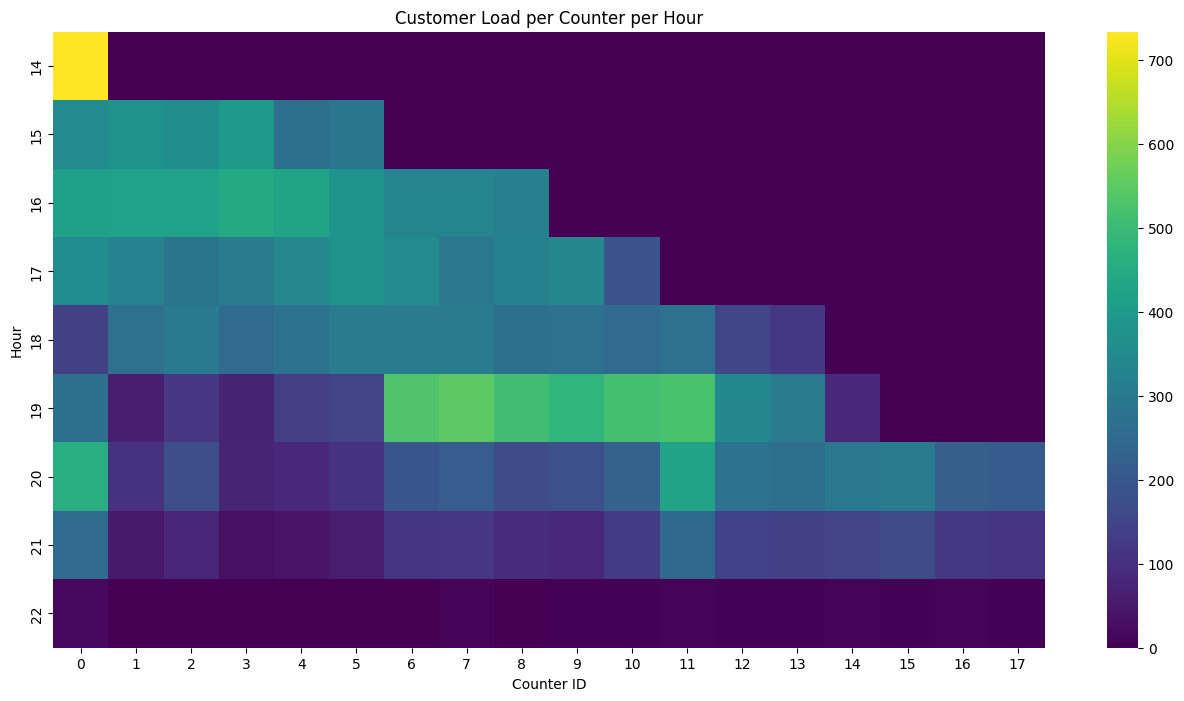

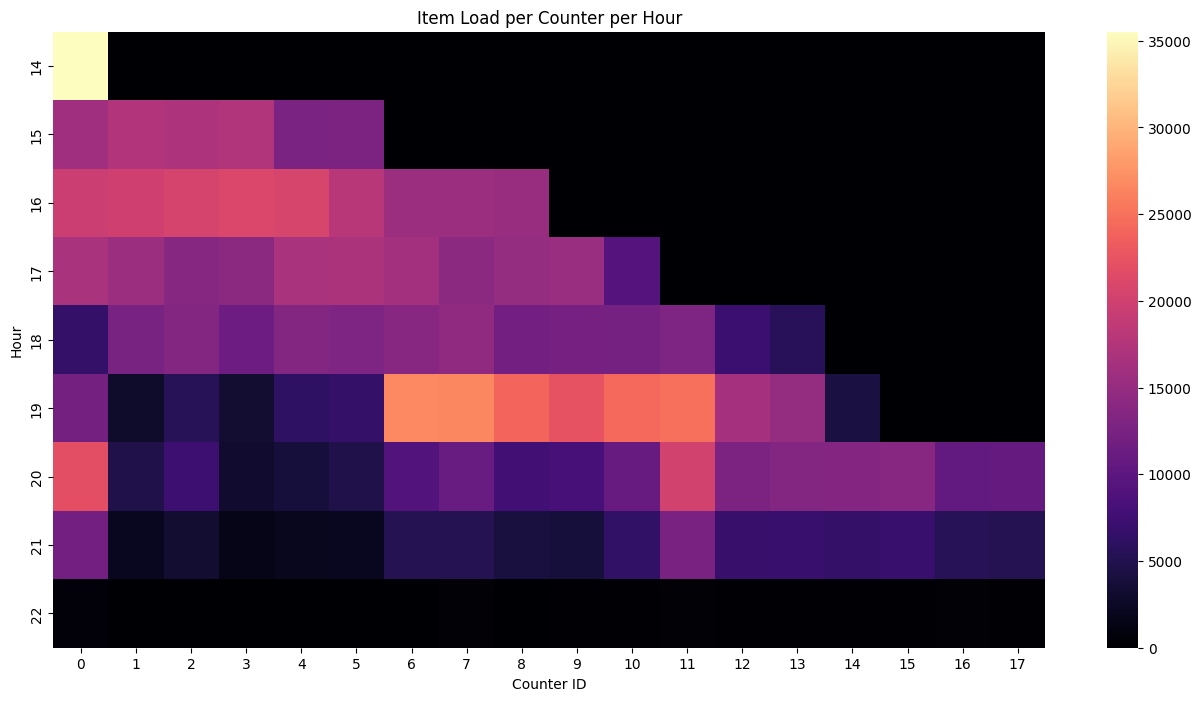

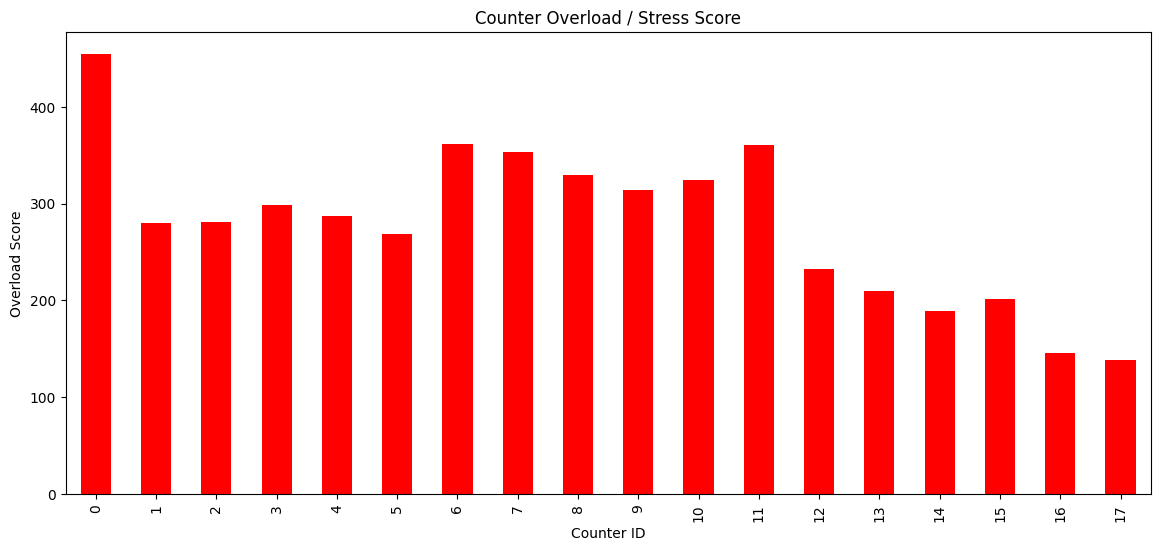

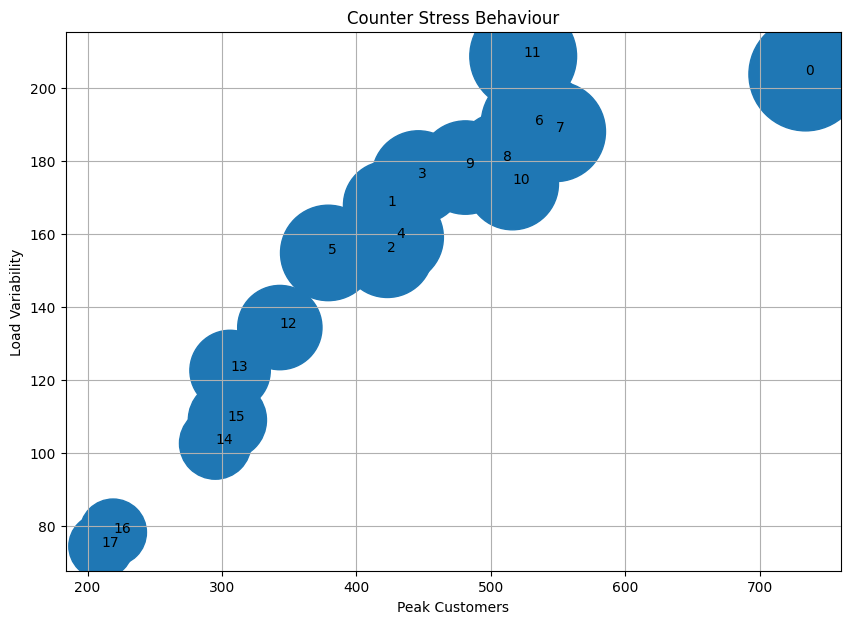

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. PREPARE DATA
# =========================================================

log_df_counter['time:timestamp'] = pd.to_datetime(
    log_df_counter['time:timestamp']
)

log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp']
)

# =========================================================
# 2. ENTER QUEUE EVENTS
# =========================================================

enter_queue = log_df_counter[
    log_df_counter['concept:name']
    == 'Enter Queue'
].copy()

# =========================================================
# 3. NORMALIZE IDS
# =========================================================

enter_queue['id'] = (
    enter_queue['id']
    .astype(float)
    .astype(int)
)

enter_queue['counter_id'] = (
    enter_queue['case:concept:name']
    .astype(int)
)

# =========================================================
# 4. TEMPORAL FEATURES
# =========================================================

enter_queue['hour'] = (
    enter_queue['time:timestamp']
    .dt.hour
)

# =========================================================
# 5. CUSTOMER LOAD PER COUNTER PER HOUR
# =========================================================

customer_load = (
    enter_queue.groupby(
        ['hour', 'counter_id']
    )['id']
    .nunique()
    .unstack(fill_value=0)
)

# =========================================================
# 6. ITEM LOAD PER COUNTER PER HOUR
# =========================================================

item_load = (
    enter_queue.groupby(
        ['hour', 'counter_id']
    )['items']
    .sum()
    .unstack(fill_value=0)
)

# =========================================================
# 7. VARIABILITY (VERY IMPORTANT)
# =========================================================

counter_variability = (
    customer_load.std()
)

# =========================================================
# 8. PEAK LOAD
# =========================================================

peak_load = (
    customer_load.max()
)

# =========================================================
# 9. ACTIVE HOURS here also includes start and end hours 
# =========================================================

active_hours = (
    customer_load.gt(0)
    .sum()
)

# =========================================================
# 10. CUSTOMERS PER ACTIVE HOUR
# =========================================================

customers_per_active_hour = (
    customer_load.sum()
    /
    active_hours
)

# =========================================================
# 11. ITEMS PER ACTIVE HOUR
# =========================================================

items_per_active_hour = (
    item_load.sum()
    /
    active_hours
)

# =========================================================
# 12. OVERLOAD SCORE
# =========================================================
#
# Stronger than simple averages
#
# Higher score means:
# - high peaks
# - high variability
# - high sustained load
#
# =========================================================
#when max cutomers (as that would influence waiting +counters with spikes+customer per hour
#is on scale of customer
overload_score = (
    (
        peak_load * 0.4
    )
    +
    (
        counter_variability * 0.3
    )
    +
    (
        customers_per_active_hour * 0.3
    )
)

# =========================================================
# 13. COMBINE EVERYTHING
# =========================================================

analysis_df = pd.DataFrame({

    'peak_customers':
        peak_load,

    'variability':
        counter_variability,

    'active_hours':
        active_hours,

    'customers_per_active_hour':
        customers_per_active_hour,

    'items_per_active_hour':
        items_per_active_hour,

    'overload_score':
        overload_score

})

analysis_df = (
    analysis_df
    .round(2)
)

analysis_df.index = (
    analysis_df.index.astype(int)
)

analysis_df = (
    analysis_df.sort_index()
)

# =========================================================
# 14. PRINT RESULTS
# =========================================================

print("\nCOUNTER PERFORMANCE SUMMARY\n")

print(analysis_df)

# =========================================================
# 15. HEATMAP — CUSTOMER LOAD
# =========================================================

plt.figure(figsize=(16,8))

sns.heatmap(
    customer_load,
    cmap='viridis',
    annot=False
)

plt.title(
    "Customer Load per Counter per Hour"
)

plt.xlabel("Counter ID")

plt.ylabel("Hour")

plt.show()

# =========================================================
# 16. HEATMAP — ITEM LOAD
# =========================================================

plt.figure(figsize=(16,8))

sns.heatmap(
    item_load,
    cmap='magma',
    annot=False
)

plt.title(
    "Item Load per Counter per Hour"
)

plt.xlabel("Counter ID")

plt.ylabel("Hour")

plt.show()

# =========================================================
# 17. OVERLOAD SCORE VISUALIZATION
# =========================================================

plt.figure(figsize=(14,6))

analysis_df[
    'overload_score'
].plot(
    kind='bar',
    color='red'
)

plt.title(
    "Counter Overload / Stress Score"
)

plt.xlabel("Counter ID")

plt.ylabel("Overload Score")

plt.show()

# =========================================================
# 18. PEAK VS VARIABILITY SCATTER
# =========================================================

plt.figure(figsize=(10,7))

plt.scatter(
    analysis_df['peak_customers'],
    analysis_df['variability'],
    s=analysis_df[
        'customers_per_active_hour'
    ] * 20
)

# Add counter labels
for counter_id, row in analysis_df.iterrows():

    plt.text(
        row['peak_customers'],
        row['variability'],
        str(counter_id)
    )

plt.xlabel("Peak Customers")

plt.ylabel("Load Variability")

plt.title(
    "Counter Stress Behaviour"
)

plt.grid(True)

plt.show()

CLERK HOURLY SUMMARY FOR KEY HOURS


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer
hour,,,,,
14,1288,749,2816,0.582,2.186
15,1750,2388,166,1.365,0.095
16,2446,4324,0,1.768,0.000
17,2425,4445,0,1.833,0.000
18,2459,4050,0,1.647,0.000
19,3070,5487,50,1.787,0.016
20,2848,5398,0,1.895,0.000
21,1824,2779,0,1.524,0.000
22,156,164,0,1.051,0.000


FULL HOURLY CLERK ACTIVITY SUMMARY


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer
hour,,,,,
14,1288,749,2816,0.582,2.186
15,1750,2388,166,1.365,0.095
16,2446,4324,0,1.768,0.000
17,2425,4445,0,1.833,0.000
18,2459,4050,0,1.647,0.000
19,3070,5487,50,1.787,0.016
20,2848,5398,0,1.895,0.000
21,1824,2779,0,1.524,0.000
22,156,164,0,1.051,0.000


ACTIVITY SHARE AT KEY HOURS


,Start Price Check,Cleanup abandoned item,other_clerk_activity
hour,,,
14,0.106,0.790,0.104
15,0.472,0.065,0.463
16,0.501,0.000,0.499
17,0.501,0.000,0.499
18,0.502,0.000,0.498
19,0.495,0.009,0.496
20,0.498,0.000,0.502
21,0.497,0.000,0.503
22,0.433,0.000,0.567


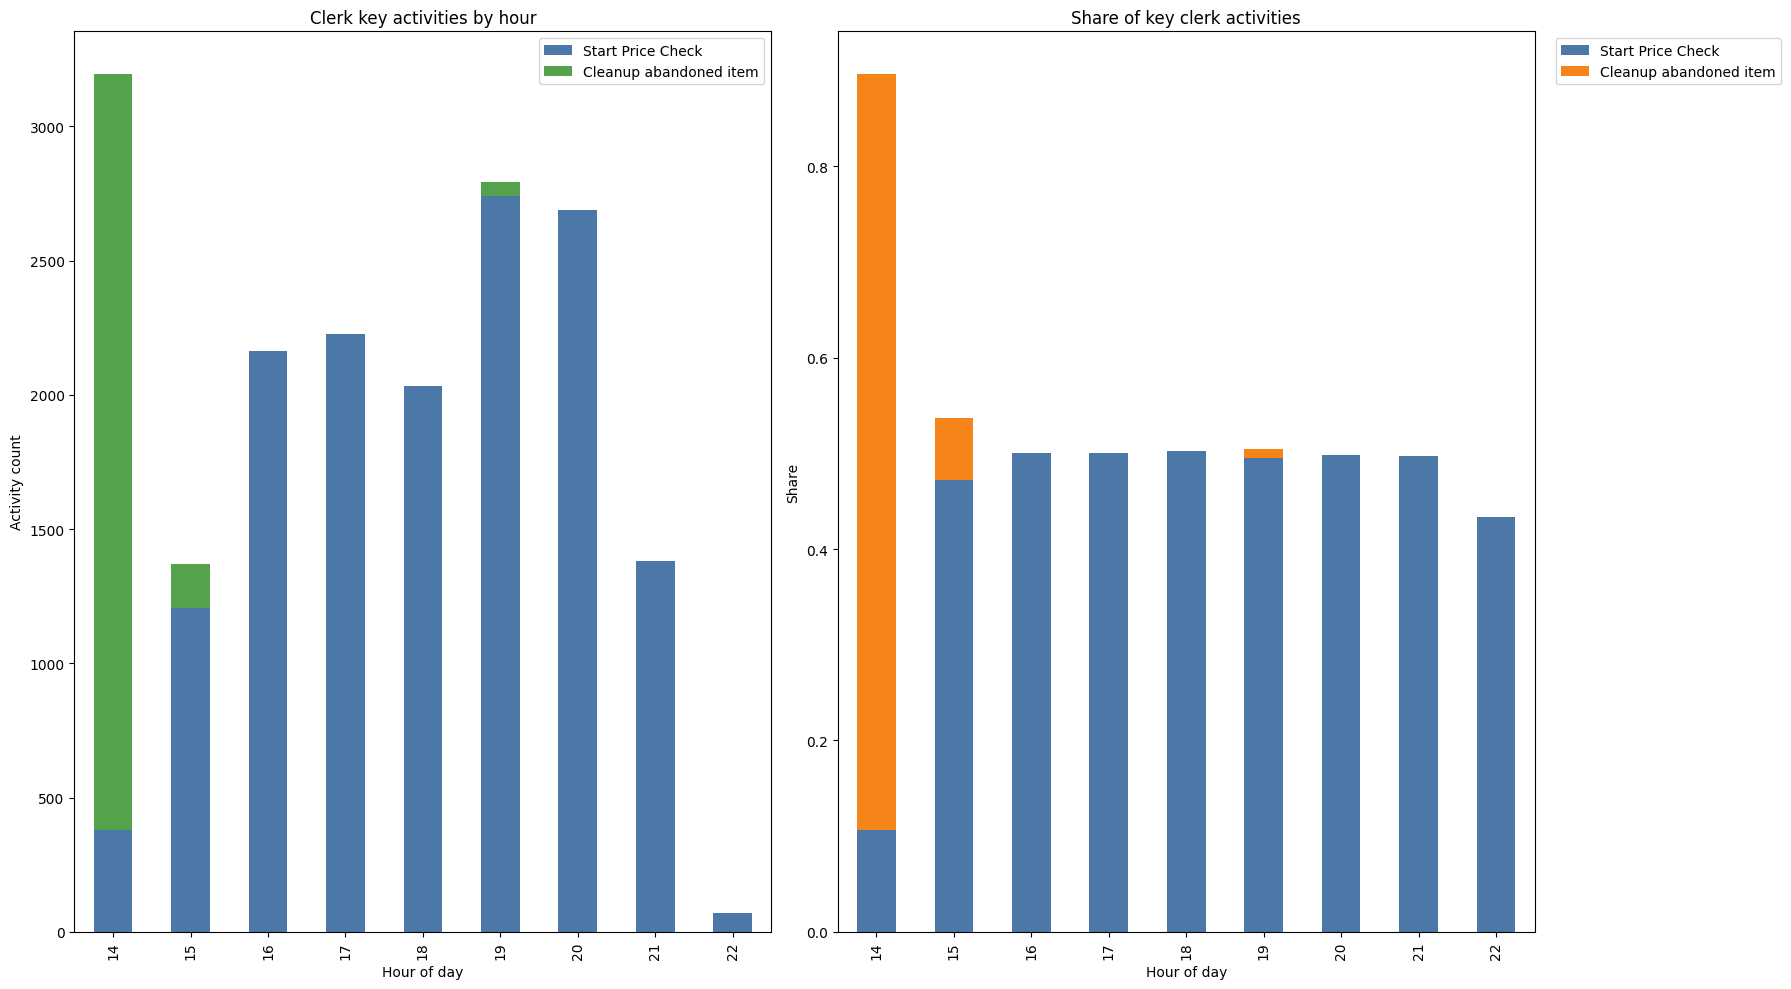

CRITICAL HOUR INTERPRETATION TABLE


,customers,price_checks,cleaning,price_checks_per_customer,cleaning_per_customer,price_checks_share,cleaning_share
hour,,,,,,,
14,1288,749,2816,0.582,2.186,0.210,0.790
15,1750,2388,166,1.365,0.095,0.935,0.065
16,2446,4324,0,1.768,0.000,1.000,0.000
17,2425,4445,0,1.833,0.000,1.000,0.000
18,2459,4050,0,1.647,0.000,1.000,0.000
19,3070,5487,50,1.787,0.016,0.991,0.009
20,2848,5398,0,1.895,0.000,1.000,0.000
21,1824,2779,0,1.524,0.000,1.000,0.000
22,156,164,0,1.051,0.000,1.000,0.000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# Clerk hourly activity analysis focused on price checks and cleaning
# -------------------------------------------------------------------

# Make sure timestamps are parsed correctly
log_df_clerk['time:timestamp'] = pd.to_datetime(log_df_clerk['time:timestamp'], errors='coerce')
log_df_customer['time:timestamp'] = pd.to_datetime(log_df_customer['time:timestamp'], errors='coerce')

clerk_df = log_df_clerk.dropna(subset=['time:timestamp']).copy()
customer_df = log_df_customer.dropna(subset=['time:timestamp']).copy()

# Hour of day
clerk_df['hour'] = clerk_df['time:timestamp'].dt.hour
customer_df['hour'] = customer_df['time:timestamp'].dt.hour

# Keep only the activities that matter for this analysis
activity_col = 'concept:name'
key_activities = [
    'Start Price Check',
    'Cleanup abandoned item'
]

# All clerk activities by hour
clerk_hourly = (
    clerk_df.groupby(['hour', activity_col])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Ensure key activity columns exist even if absent in some data slices
for activity in key_activities:
    if activity not in clerk_hourly.columns:
        clerk_hourly[activity] = 0

clerk_hourly = clerk_hourly.sort_index(axis=1)

# Aggregate the main activity groups
clerk_hourly['price_checks'] = clerk_hourly[[c for c in clerk_hourly.columns if 'price check' in str(c).lower()]].sum(axis=1)
clerk_hourly['cleaning'] = clerk_hourly[[c for c in clerk_hourly.columns if 'clean' in str(c).lower()]].sum(axis=1)
clerk_hourly['total_clerk_events'] = clerk_hourly.drop(columns=['price_checks', 'cleaning']).sum(axis=1)

# Customer load per hour for influence comparison
customer_hourly = (
    customer_df.groupby('hour')['case:concept:name']
    .nunique()
    .rename('customers')
    .sort_index()
)

clerk_hourly = clerk_hourly.join(customer_hourly, how='outer').fillna(0)
clerk_hourly['customers'] = clerk_hourly['customers'].astype(int)

# Normalize price checks and cleaning relative to customer load
clerk_hourly['price_checks_per_customer'] = clerk_hourly['price_checks'] / clerk_hourly['customers'].replace(0, np.nan)
clerk_hourly['cleaning_per_customer'] = clerk_hourly['cleaning'] / clerk_hourly['customers'].replace(0, np.nan)

# Key hours of interest
key_hours = [14, 15,16,17,18,19,20,21,22]
key_hours_summary = clerk_hourly.loc[clerk_hourly.index.intersection(key_hours), [
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].copy()

print('CLERK HOURLY SUMMARY FOR KEY HOURS')
display(key_hours_summary.round(3))

print('FULL HOURLY CLERK ACTIVITY SUMMARY')
display(clerk_hourly[[
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].round(3))

# Share of activities by hour for the main operational actions
main_ops = clerk_hourly[['Start Price Check', 'Cleanup abandoned item']].copy()
main_ops['other_clerk_activity'] = clerk_hourly['total_clerk_events'] - main_ops.sum(axis=1)
main_ops = main_ops.clip(lower=0)

activity_share = main_ops.div(main_ops.sum(axis=1).replace(0, np.nan), axis=0)

print('ACTIVITY SHARE AT KEY HOURS')
display(activity_share.loc[activity_share.index.intersection(key_hours)].round(3))

# -------------------------------------------------------------------
# Visualizations
# -------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 1) Stacked activity counts
clerk_hourly[['Start Price Check', 'Cleanup abandoned item']].plot(
    kind='bar', stacked=True, ax=axes[0], color=['#4C78A8', '#54A24B']
)
axes[0].set_title('Clerk key activities by hour')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Activity count')


# 4) Activity share at key hours
activity_share.loc[activity_share.index.intersection(key_hours), [
    'Start Price Check', 'Cleanup abandoned item'
]].plot(kind='bar', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Share of key clerk activities')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Share')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Short critical interpretation table
# -------------------------------------------------------------------

critical_hours = clerk_hourly.loc[clerk_hourly.index.intersection(key_hours), [
    'customers', 'price_checks', 'cleaning', 'price_checks_per_customer', 'cleaning_per_customer'
]].copy()
critical_hours['price_checks_share'] = critical_hours['price_checks'] / critical_hours[['price_checks', 'cleaning']].sum(axis=1).replace(0, np.nan)
critical_hours['cleaning_share'] = critical_hours['cleaning'] / critical_hours[['price_checks', 'cleaning']].sum(axis=1).replace(0, np.nan)

print('CRITICAL HOUR INTERPRETATION TABLE')
display(critical_hours.round(3))



ABANDONMENT ANALYSIS


CUSTOMER TYPES DURING ABANDONMENT

s
lCust      220
lItem      214
lRandom    196
Name: count, dtype: int64
s     lCust  lItem  lRandom
hour                       
14      203    192      191
15       12     19        5
19        5      3        0


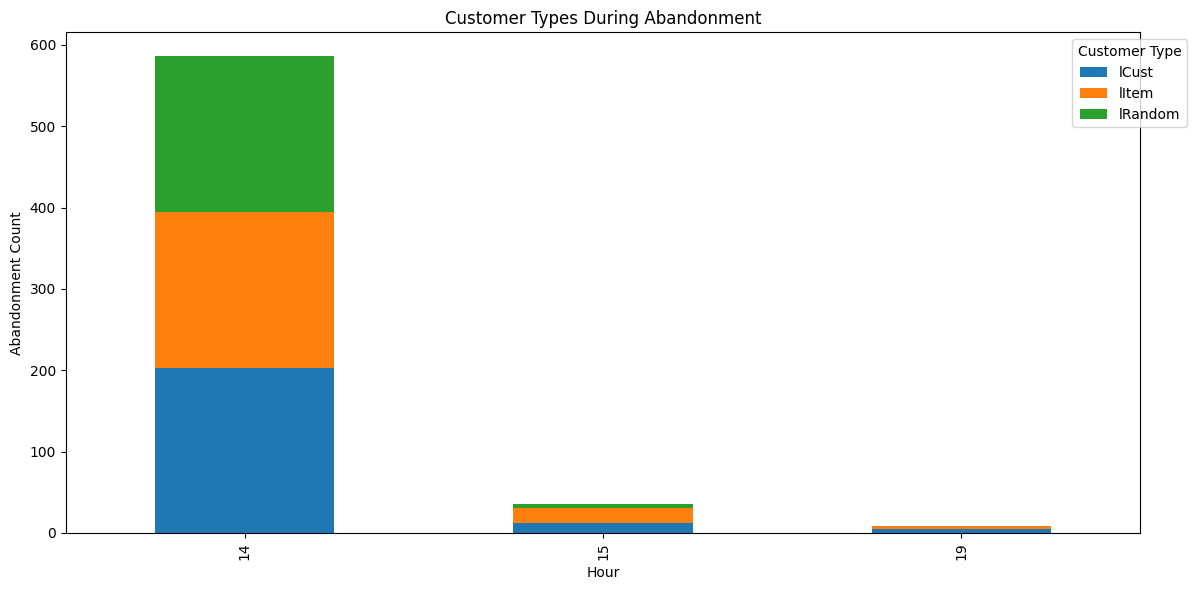


ABANDONMENT RATE (%)

s     lCust  lItem  lRandom
hour                       
14     0.58   0.55     0.59
15     0.02   0.03     0.01
19     0.00   0.00      NaN


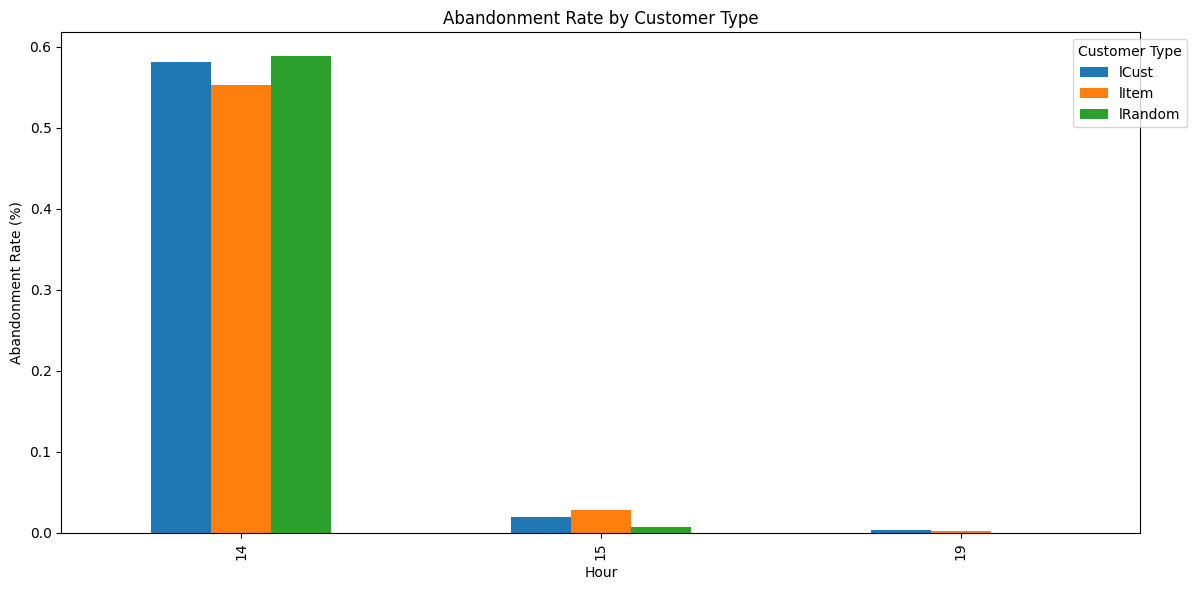


ITEM DISTRIBUTION DURING ABANDONMENT

      count   mean  median   max    std
hour                                   
14      586  43.48    55.0  85.0  25.93
15       36  40.78    50.0  74.0  23.35
19        8  59.25    65.0  75.0  19.17


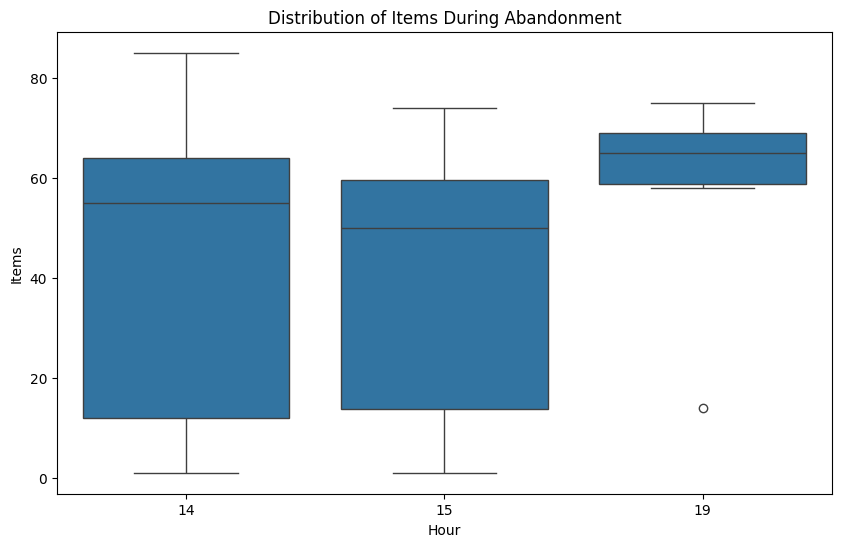

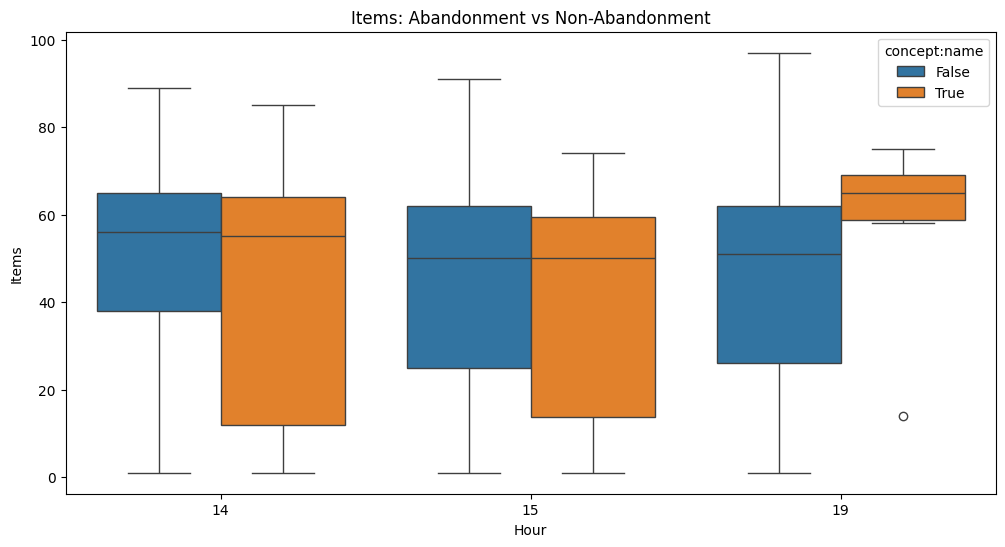


PAYMENT METHOD ANALYSIS

Unique payment methods:
[nan 'Pin' 'Cash']
p      Cash     Pin
hour               
14    12991   87595
15    24808  170850
16    45643  299555
17    48308  294003
18    45534  288636
19    57143  393269
20    50349  352116
21    25849  181422
22     1379    5881


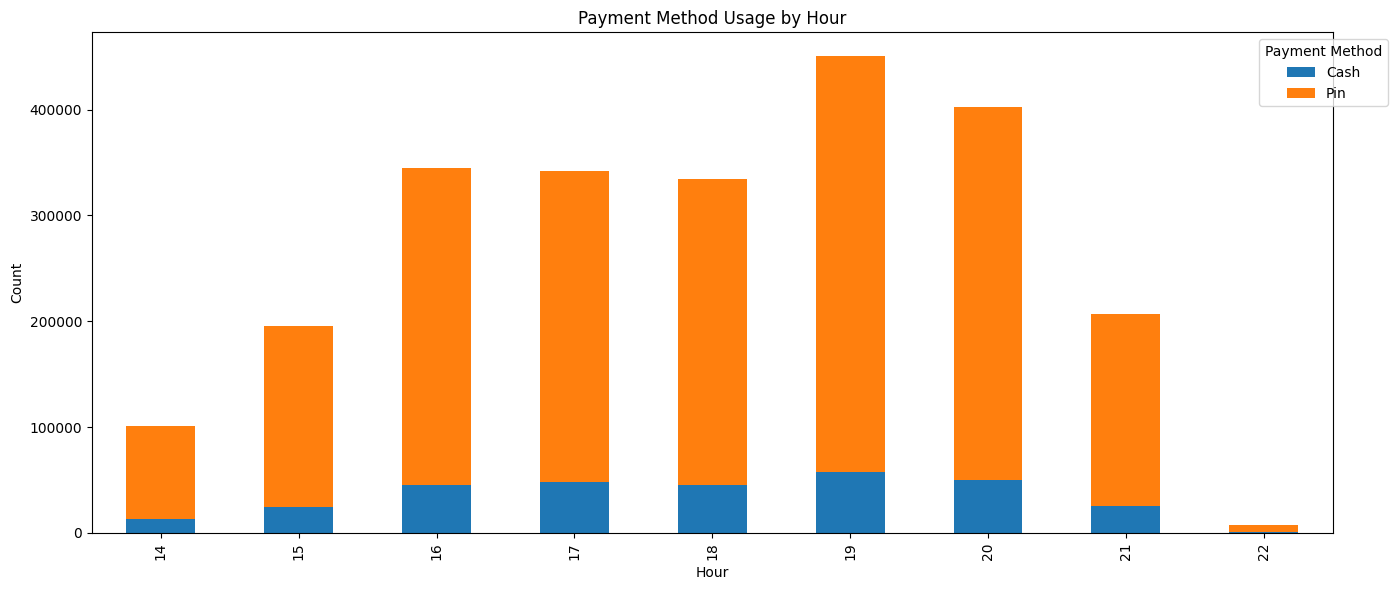


PAYMENT METHODS DURING ABANDONMENT

p     Cash  Pin
hour           
14     132  454
15       7   29
19       0    8


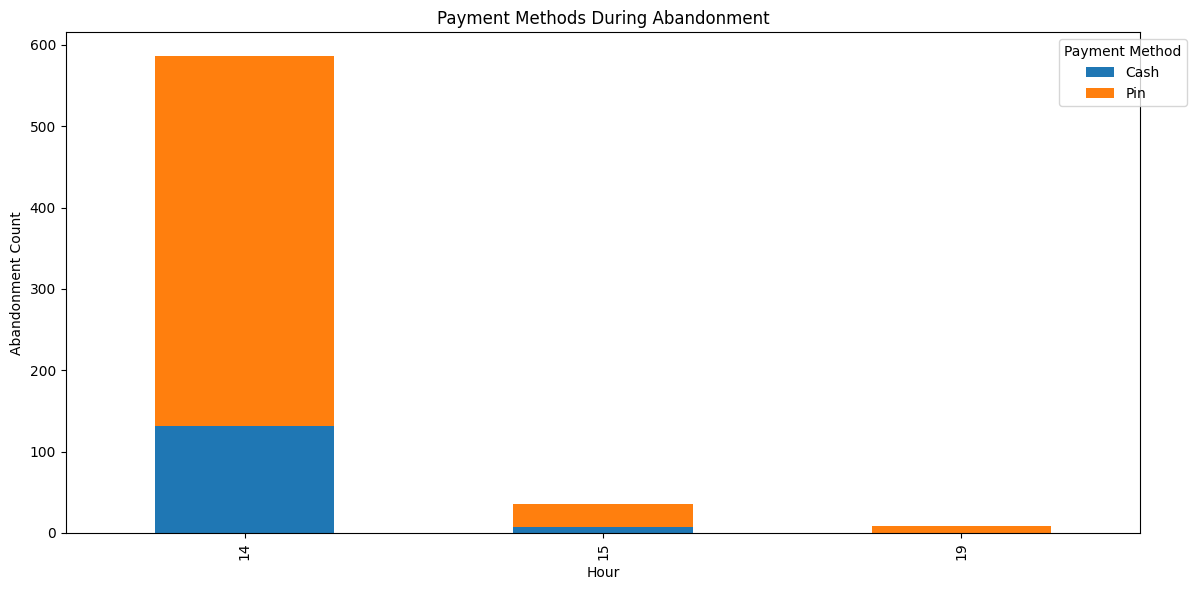

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# PREPARE DATA
# =========================================================

log_df_customer['time:timestamp'] = pd.to_datetime(
    log_df_customer['time:timestamp'],
    errors='coerce'
)

log_df_cashier['time:timestamp'] = pd.to_datetime(
    log_df_cashier['time:timestamp'],
    errors='coerce'
)

customer_df = log_df_customer.dropna(
    subset=['time:timestamp']
).copy()

cashier_df = log_df_cashier.dropna(
    subset=['time:timestamp']
).copy()

customer_df['hour'] = (
    customer_df['time:timestamp']
    .dt.hour
)

cashier_df['hour'] = (
    cashier_df['time:timestamp']
    .dt.hour
)

# =========================================================
# =========================================================
# 1. ABANDONMENT ANALYSIS
# =========================================================
# =========================================================

print("\n==============================")
print("ABANDONMENT ANALYSIS")
print("==============================\n")

# ---------------------------------------------------------
# ABANDONMENT EVENTS
# ---------------------------------------------------------

abandon_df = customer_df[
    customer_df['concept:name']
    == 'Abandon cart and leave'
].copy()

# Focus hours
target_hours = [14, 15, 19]

abandon_df = abandon_df[
    abandon_df['hour'].isin(target_hours)
]

# ---------------------------------------------------------
# CUSTOMER TYPES
# ---------------------------------------------------------

print("\nCUSTOMER TYPES DURING ABANDONMENT\n")

print(
    abandon_df['s']
    .value_counts()
)

customer_type_summary = (
    abandon_df.groupby(
        ['hour', 's']
    )
    .size()
    .unstack(fill_value=0)
)

print(customer_type_summary)

customer_type_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Customer Types During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Count")

plt.legend(
    title='Customer Type',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# ABANDONMENT RATE BY CUSTOMER TYPE
# MUCH STRONGER THAN RAW COUNTS
# ---------------------------------------------------------

all_customers = (
    customer_df[
        customer_df['hour'].isin(target_hours)
    ]
)

customer_totals = (
    all_customers.groupby(
        ['hour', 's']
    )
    .size()
)

abandon_totals = (
    abandon_df.groupby(
        ['hour', 's']
    )
    .size()
)

abandonment_rate = (
    abandon_totals
    /
    customer_totals
    * 100
)

abandonment_rate = (
    abandonment_rate
    .unstack(fill_value=0)
)

print("\nABANDONMENT RATE (%)\n")

print(
    abandonment_rate.round(2)
)

abandonment_rate.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Abandonment Rate by Customer Type"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Rate (%)")

plt.legend(
    title='Customer Type',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# ITEMS ANALYSIS
# ---------------------------------------------------------

print("\nITEM DISTRIBUTION DURING ABANDONMENT\n")

item_summary = (
    abandon_df.groupby('hour')
    ['items']
    .agg([
        'count',
        'mean',
        'median',
        'max',
        'std'
    ])
)

print(
    item_summary.round(2)
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=abandon_df,
    x='hour',
    y='items'
)

plt.title(
    "Distribution of Items During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Items")

plt.show()

# ---------------------------------------------------------
# COMPARE WITH NORMAL CUSTOMERS
# VERY IMPORTANT BASELINE
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.boxplot(
    data=customer_df[
        customer_df['hour'].isin(target_hours)
    ],
    x='hour',
    y='items',
    hue=customer_df[
        customer_df['hour'].isin(target_hours)
    ]['concept:name']
    == 'Abandon cart and leave'
)

plt.title(
    "Items: Abandonment vs Non-Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Items")

plt.show()


# =========================================================
# =========================================================
# 2. PAYMENT METHOD ANALYSIS
# =========================================================
# =========================================================

print("\n==============================")
print("PAYMENT METHOD ANALYSIS")
print("==============================\n")

print(
    "Unique payment methods:"
)

print(
    customer_df['p']
    .unique()
)

payment_hourly = (
    customer_df.groupby(
        ['hour', 'p']
    )
    .size()
    .unstack(fill_value=0)
)

print(payment_hourly)

payment_hourly.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title(
    "Payment Method Usage by Hour"
)

plt.xlabel("Hour")

plt.ylabel("Count")

plt.legend(
    title='Payment Method',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# PAYMENT METHOD DURING ABANDONMENT
# ---------------------------------------------------------

payment_abandon = (
    abandon_df.groupby(
        ['hour', 'p']
    )
    .size()
    .unstack(fill_value=0)
)

print("\nPAYMENT METHODS DURING ABANDONMENT\n")

print(payment_abandon)

payment_abandon.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Payment Methods During Abandonment"
)

plt.xlabel("Hour")

plt.ylabel("Abandonment Count")

plt.legend(
    title='Payment Method',
    bbox_to_anchor=(1.05,1)
)

plt.tight_layout()

plt.show()



## Analysing abandonments more closely

In [19]:
customer_df['weekday'] = (
    customer_df['time:timestamp']
    .dt.day_name()
)

customer_df['date'] = (
    customer_df['time:timestamp']
    .dt.date
)

abandon_df = customer_df[
    customer_df['concept:name']
    == 'Abandon cart and leave'
]

weekday_abandonments = (
    abandon_df.groupby('weekday')
    .size()
    .sort_values(ascending=False)
)

print("\nTOTAL WEEKDAY ABANDONMENTS\n")
print(weekday_abandonments)

top3_days = (
    weekday_abandonments
    .head(7)
    .index
)

print("\nTOP 3 DAYS\n")
print(top3_days.tolist())


TOTAL WEEKDAY ABANDONMENTS

weekday
Friday       113
Tuesday      113
Monday       110
Thursday      97
Wednesday     84
Sunday        66
Saturday      47
dtype: int64

TOP 3 DAYS

['Friday', 'Tuesday', 'Monday', 'Thursday', 'Wednesday', 'Sunday', 'Saturday']


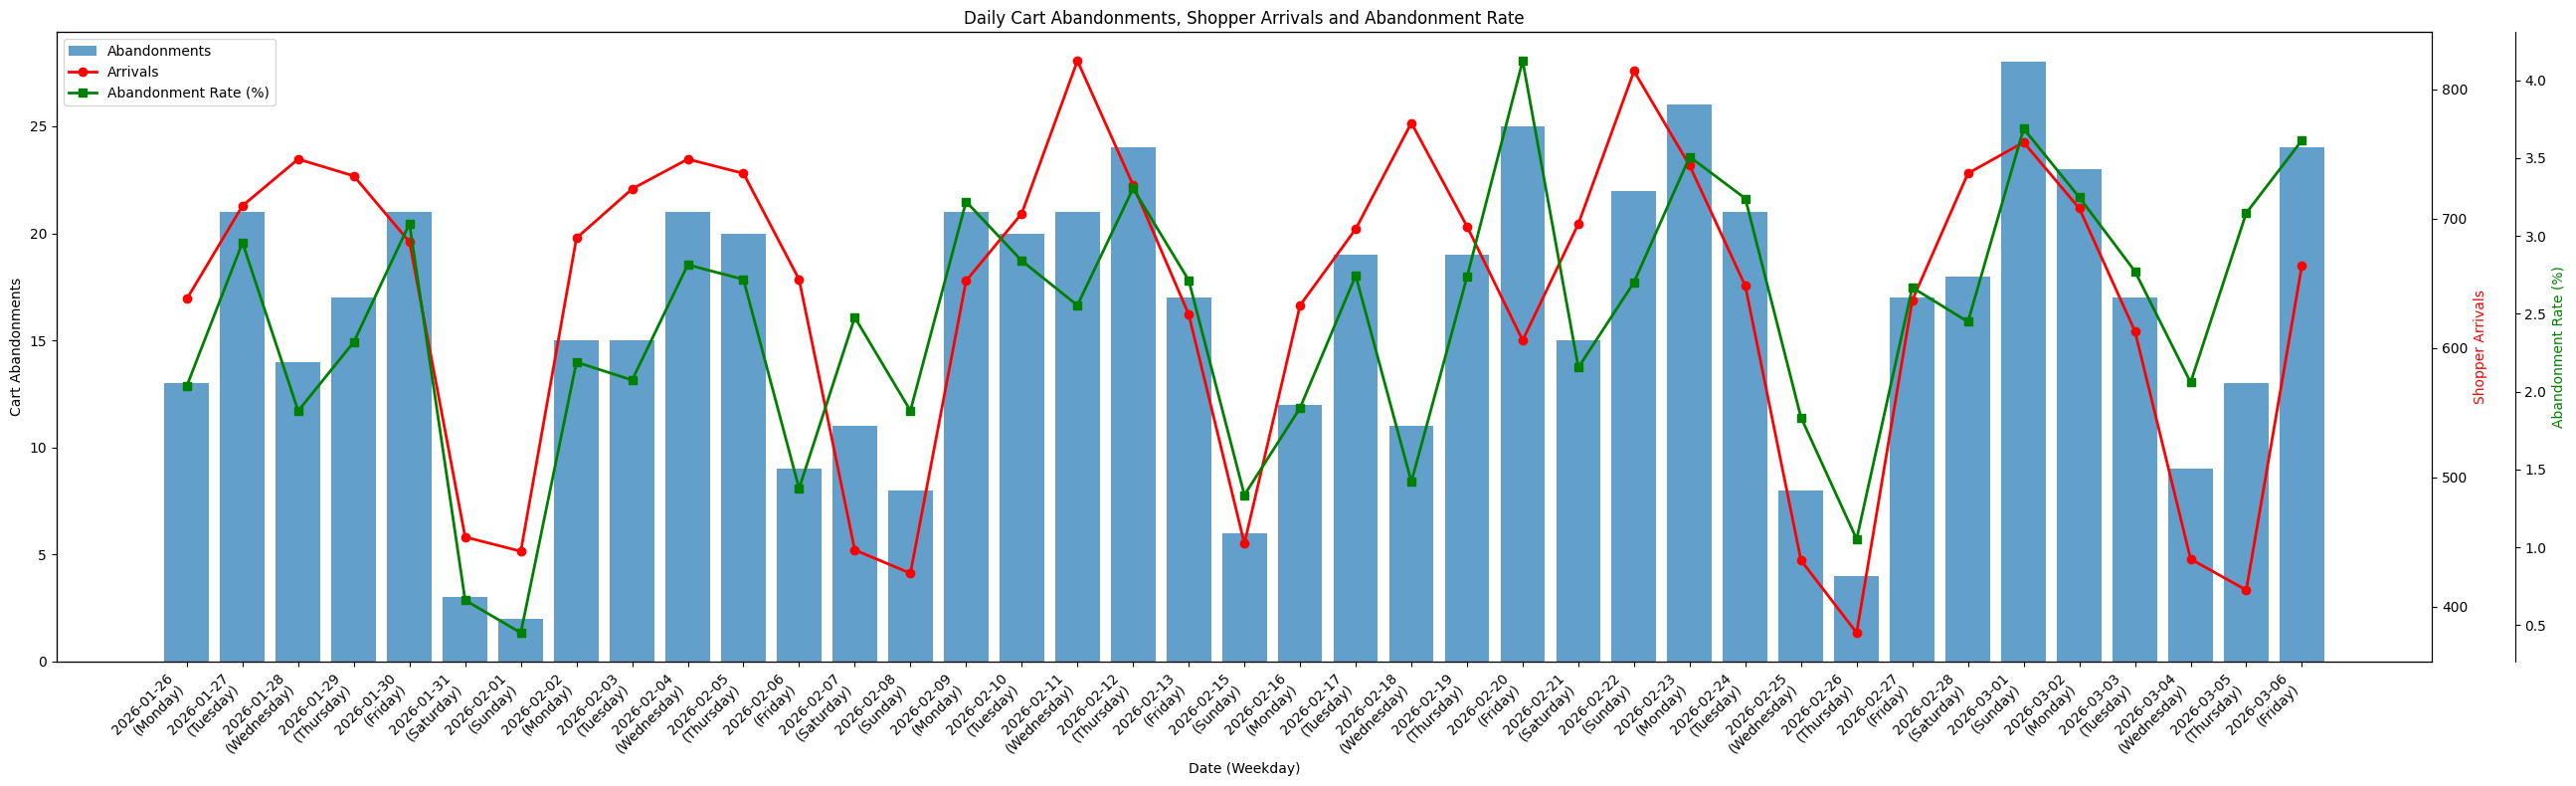

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# DAILY ABANDONMENTS
# --------------------------------------------------

daily_abandonments = (
    abandon_df
    .groupby(['date', 'weekday'])
    .size()
    .reset_index(name='abandonments')
)

# --------------------------------------------------
# DAILY ARRIVALS
# --------------------------------------------------

enter_queue = customer_df[
    customer_df['concept:name']
    == 'Enter Queue'
].copy()

daily_arrivals = (
    enter_queue
    .groupby('date')
    ['case:concept:name']
    .nunique()
    .reset_index(name='arrivals')
)

# --------------------------------------------------
# MERGE
# --------------------------------------------------

analysis_df = (
    daily_abandonments
    .merge(
        daily_arrivals,
        on='date',
        how='left'
    )
)

analysis_df = (
    analysis_df
    .sort_values('date')
)

# --------------------------------------------------
# ABANDONMENT RATE
# --------------------------------------------------

analysis_df['abandonment_rate'] = (
    analysis_df['abandonments']
    /
    analysis_df['arrivals']
    * 100
)

# --------------------------------------------------
# LABELS
# --------------------------------------------------

analysis_df['label'] = (
    analysis_df['date'].astype(str)
    + '\n('
    + analysis_df['weekday']
    + ')'
)

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------

fig, ax1 = plt.subplots(
    figsize=(26,8)
)

# ------------------------------------------
# BAR: ABANDONMENTS
# ------------------------------------------

ax1.bar(
    analysis_df['label'],
    analysis_df['abandonments'],
    alpha=0.7,
    label='Abandonments'
)

ax1.set_ylabel(
    "Cart Abandonments"
)

ax1.set_xlabel(
    "Date (Weekday)"
)

# ------------------------------------------
# LINE: ARRIVALS
# ------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    analysis_df['label'],
    analysis_df['arrivals'],
    color='red',
    marker='o',
    linewidth=2,
    label='Arrivals'
)

ax2.set_ylabel(
    "Shopper Arrivals",
    color='red'
)

# ------------------------------------------
# THIRD AXIS: ABANDONMENT RATE
# ------------------------------------------

ax3 = ax1.twinx()

ax3.spines['right'].set_position(
    ('outward', 60)
)

ax3.plot(
    analysis_df['label'],
    analysis_df['abandonment_rate'],
    color='green',
    marker='s',
    linewidth=2,
    label='Abandonment Rate (%)'
)

ax3.set_ylabel(
    "Abandonment Rate (%)",
    color='green'
)

# ------------------------------------------
# COMBINED LEGEND
# ------------------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc='upper left'
)

# ------------------------------------------
# TITLE
# ------------------------------------------

plt.title(
    "Daily Cart Abandonments, Shopper Arrivals and Abandonment Rate"
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=7
)
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

plt.tight_layout()

plt.show()

In [ ]:
#7-02, 11-02,15-02,18-02,25--2, 26-02, 03-03,05-03

## We see that cart abandonment even happens when customer arrival rate is not very high.

Analysing across all the dates

In [21]:
# ----------------------------------
# Daily arrivals
# ----------------------------------

arrivals = (

    customer_df

    .groupby('date')
    ['case:concept:name']

    .nunique()

)

# ----------------------------------
# Daily abandonments
# ----------------------------------

abandons = (

    abandon_df

    .groupby(['date','weekday'])

    .size()

    .reset_index(
        name='abandonments'
    )

)

# ----------------------------------
# Merge
# ----------------------------------

worst_dates = (
    abandons
    .merge(
        arrivals.rename('arrivals'),
        on='date'
    )
)

# ----------------------------------
# Abandonment Rate
# ----------------------------------

worst_dates['abandonment_rate'] = (

    worst_dates['abandonments']

    /

    worst_dates['arrivals']

    * 100

)

# ----------------------------------
# Top 20 worst dates
# ----------------------------------

worst_dates = (

    worst_dates

    .sort_values(
        'abandonment_rate',
        ascending=False
    )

    .head(20)

)

print(
    worst_dates[
        [
            'date',
            'weekday',
            'abandonments',
            'arrivals',
            'abandonment_rate'
        ]
    ]
)

          date    weekday  abandonments  arrivals  abandonment_rate
24  2026-02-20     Friday            25       631          3.961965
33  2026-03-01     Sunday            28       787          3.557814
38  2026-03-06     Friday            24       688          3.488372
27  2026-02-23     Monday            26       767          3.389831
17  2026-02-12   Thursday            24       750          3.200000
34  2026-03-02     Monday            23       731          3.146375
28  2026-02-24    Tuesday            21       669          3.139013
14  2026-02-09     Monday            21       673          3.120357
37  2026-03-05   Thursday            13       426          3.051643
4   2026-01-30     Friday            21       703          2.987198
1   2026-01-27    Tuesday            21       731          2.872777
15  2026-02-10    Tuesday            20       724          2.762431
9   2026-02-04  Wednesday            21       767          2.737940
35  2026-03-03    Tuesday            17       63

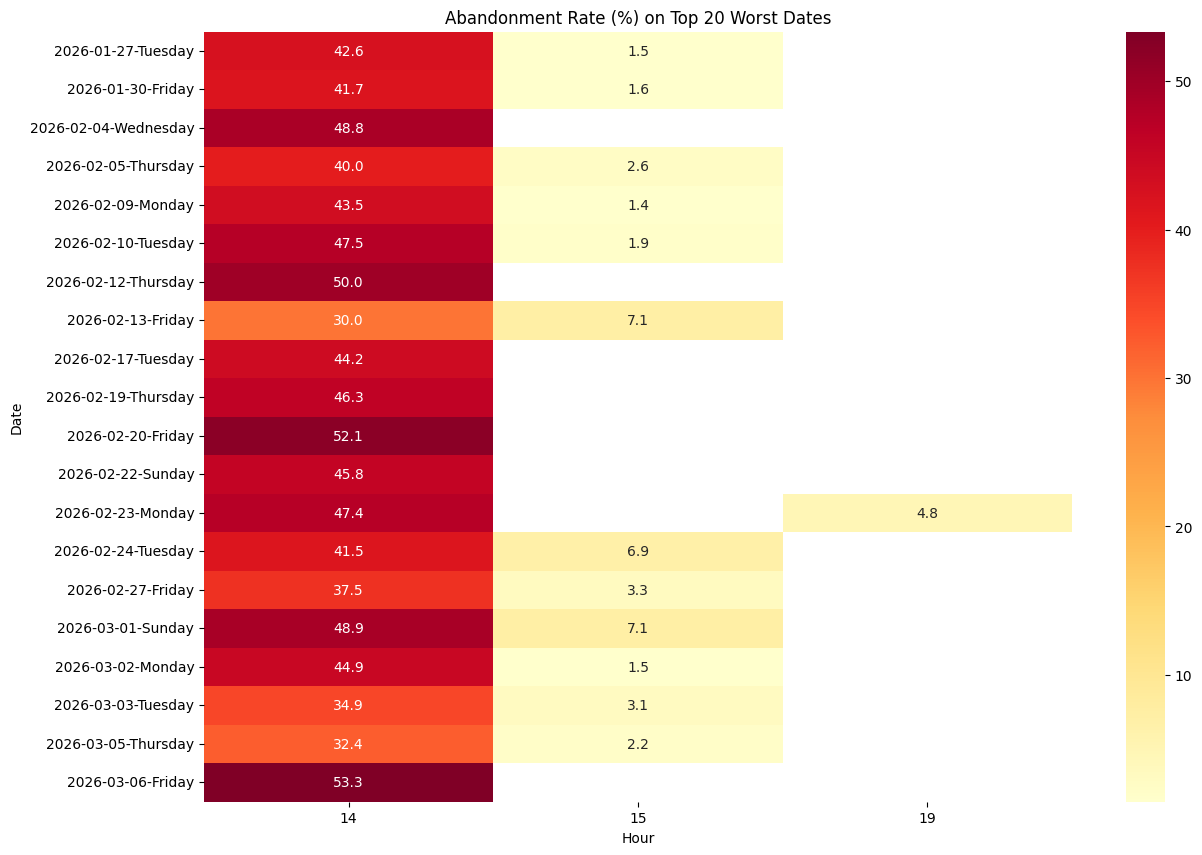

In [22]:
target_hours = [14,15,19]

# hourly arrivals
hourly_arrivals = (

    customer_df[
        (customer_df['date'].isin(
            worst_dates['date']
        ))
        &
        (customer_df['hour'].isin(
            target_hours
        ))
    ]

    .groupby(
        ['date','weekday','hour']
    )

    ['case:concept:name']

    .nunique()

)

# abandonments
hourly_abandons = (

    abandon_df[
        (abandon_df['date'].isin(
            worst_dates['date']
        ))
        &
        (abandon_df['hour'].isin(
            target_hours
        ))
    ]

    .groupby(
        ['date','weekday','hour']
    )
 ['case:concept:name']

    .nunique()

)

# rate
hourly_rate = (

    hourly_abandons

    /

    hourly_arrivals

    * 100

)

import seaborn as sns
import matplotlib.pyplot as plt

rate_plot = (

    hourly_rate

    .unstack()

)

rate_plot = rate_plot[
    [14,15,19]
]

plt.figure(
    figsize=(14,10)
)

sns.heatmap(
    rate_plot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title(
    "Abandonment Rate (%) on Top 20 Worst Dates"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Date"
)

plt.show()

#Confirming NaN values in heatmap

In [48]:
print("\nARRIVALS\n")
print(
    hourly_arrivals
    .unstack()
    .reindex(columns=[14,15,19])
)


ARRIVALS

hour                  14  15   19
date       weekday               
2026-01-27 Tuesday    47  66  163
2026-01-30 Friday     48  63  149
2026-02-04 Wednesday  43  80  172
2026-02-05 Thursday   45  76  170
2026-02-09 Monday     46  69  129
2026-02-10 Tuesday    40  52  145
2026-02-12 Thursday   48  66  158
2026-02-13 Friday     40  70  138
2026-02-17 Tuesday    43  71  142
2026-02-19 Thursday   41  70  148
2026-02-20 Friday     48  55  139
2026-02-22 Sunday     48  86  166
2026-02-23 Monday     38  68  166
2026-02-24 Tuesday    41  58  143
2026-02-27 Friday     40  60  155
2026-03-01 Sunday     47  70  156
2026-03-02 Monday     49  66  148
2026-03-03 Tuesday    43  65  130
2026-03-05 Thursday   37  46   83
2026-03-06 Friday     45  49  143


In [52]:
print("\nABANDONMENTS\n")
print(
    hourly_abandons
    .unstack()
    .reindex(columns=[14,15,19])
)


ABANDONMENTS

hour                    14   15   19
date       weekday                  
2026-01-27 Tuesday    20.0  1.0  NaN
2026-01-30 Friday     20.0  1.0  NaN
2026-02-04 Wednesday  21.0  NaN  NaN
2026-02-05 Thursday   18.0  2.0  NaN
2026-02-09 Monday     20.0  1.0  NaN
2026-02-10 Tuesday    19.0  1.0  NaN
2026-02-12 Thursday   24.0  NaN  NaN
2026-02-13 Friday     12.0  5.0  NaN
2026-02-17 Tuesday    19.0  NaN  NaN
2026-02-19 Thursday   19.0  NaN  NaN
2026-02-20 Friday     25.0  NaN  NaN
2026-02-22 Sunday     22.0  NaN  NaN
2026-02-23 Monday     18.0  NaN  8.0
2026-02-24 Tuesday    17.0  4.0  NaN
2026-02-27 Friday     15.0  2.0  NaN
2026-03-01 Sunday     23.0  5.0  NaN
2026-03-02 Monday     22.0  1.0  NaN
2026-03-03 Tuesday    15.0  2.0  NaN
2026-03-05 Thursday   12.0  1.0  NaN
2026-03-06 Friday     24.0  NaN  NaN


In [23]:
abandon_counts = (

    abandon_df

    .groupby(
        'case:concept:name'
    )

    .size()

)

print(
    abandon_counts
    .value_counts()
    .sort_index()
)

1    549
2     36
3      3
Name: count, dtype: int64


In [24]:
debug_df = pd.DataFrame({
    'arrivals': hourly_arrivals,
    'abandoners': hourly_abandons
})

debug_df['rate'] = (
    debug_df['abandoners']
    /
    debug_df['arrivals']
    * 100
)

print(
    debug_df.sort_values(
        'rate',
        ascending=False
    ).head(20)
)

                           arrivals  abandoners       rate
date       weekday   hour                                 
2026-03-06 Friday    14          45        24.0  53.333333
2026-02-20 Friday    14          48        25.0  52.083333
2026-02-12 Thursday  14          48        24.0  50.000000
2026-03-01 Sunday    14          47        23.0  48.936170
2026-02-04 Wednesday 14          43        21.0  48.837209
2026-02-10 Tuesday   14          40        19.0  47.500000
2026-02-23 Monday    14          38        18.0  47.368421
2026-02-19 Thursday  14          41        19.0  46.341463
2026-02-22 Sunday    14          48        22.0  45.833333
2026-03-02 Monday    14          49        22.0  44.897959
2026-02-17 Tuesday   14          43        19.0  44.186047
2026-02-09 Monday    14          46        20.0  43.478261
2026-01-27 Tuesday   14          47        20.0  42.553191
2026-01-30 Friday    14          48        20.0  41.666667
2026-02-24 Tuesday   14          41        17.0  41.4634

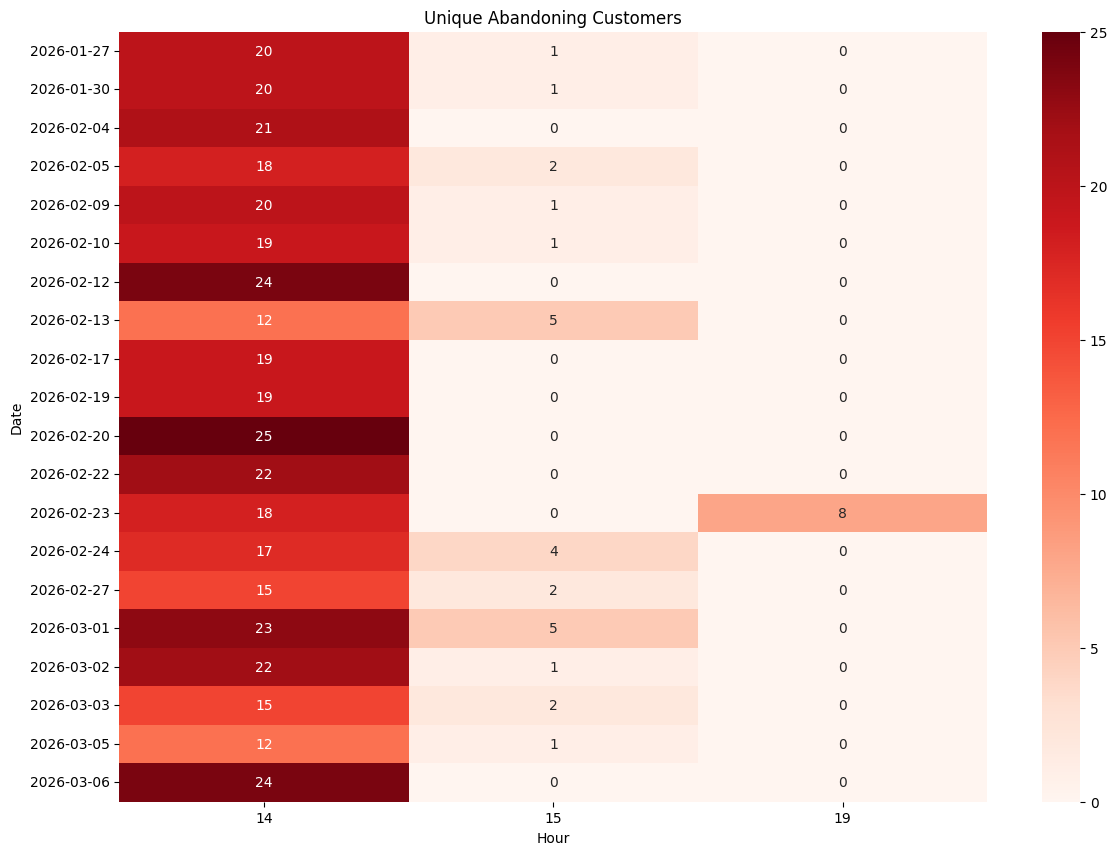

In [55]:
#Unique abandoning customers per hour on worst dates
target_hours = [14,15,19]

abandon_heat = (

    abandon_df[
        (abandon_df['date'].isin(
            worst_dates['date']
        ))
        &
        (abandon_df['hour'].isin(
            target_hours
        ))
    ]

    .groupby(
        ['date','hour']
    )

    ['case:concept:name']

    .nunique()

    .unstack(fill_value=0)

)

abandon_heat = abandon_heat[
    [14,15,19]
]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    abandon_heat,
    annot=True,
    fmt='g',
    cmap='Reds'
)

plt.title(
    "Unique Abandoning Customers"
)

plt.xlabel("Hour")
plt.ylabel("Date")

plt.show()

In [132]:
arrival_heat = (

    customer_df[
        
        (customer_df['date'].isin(
            worst_dates['date']
        ))
        &
        (customer_df['hour'].isin(
            target_hours
        ))
    ]

    .groupby(
        ['date','hour']
    )

    ['case:concept:name']

    .nunique()

    .unstack(fill_value=0)

)

arrival_heat = arrival_heat[
    [14,15,19]
]

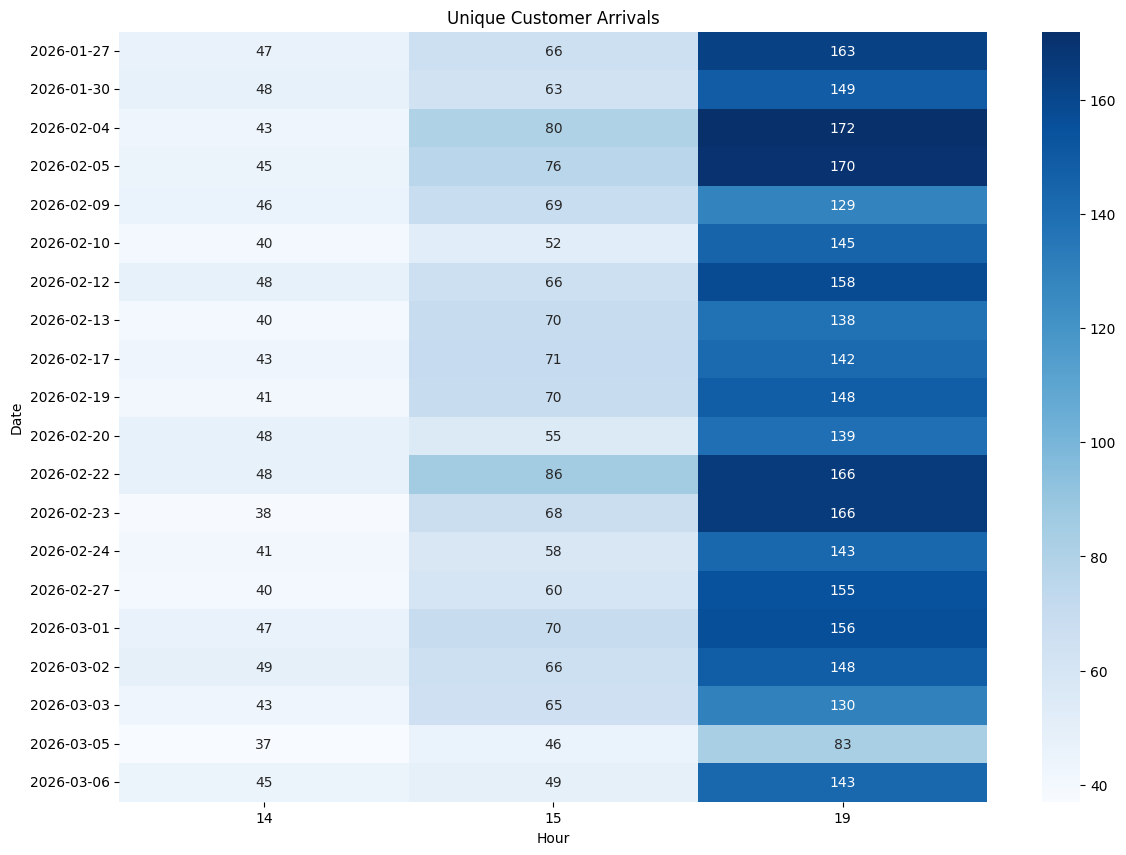

In [133]:
plt.figure(figsize=(14,10))

sns.heatmap(
    arrival_heat,
    annot=True,
    fmt='g',
    cmap='Blues'
)

plt.title(
    "Unique Customer Arrivals"
)

plt.xlabel("Hour")
plt.ylabel("Date")

plt.show()

In [63]:
open_events = log_df_counter[
    log_df_counter['concept:name']
    == 'Open counter'
]

print(
    open_events.groupby('case:concept:name')
    .size()
    .value_counts()
)

22    4
48    3
17    2
75    1
35    1
42    1
52    1
58    1
50    1
46    1
55    1
53    1
Name: count, dtype: int64


In [62]:
counter_events = log_df_counter[
    log_df_counter['concept:name'].isin(
        ['Open counter','Close counter']
    )
].copy()

counter_events = counter_events.sort_values(
    ['case:concept:name','time:timestamp']
)

In [126]:
counter_events = (
    log_df_counter[
        log_df_counter['concept:name'].isin(
            ['Open counter','Close counter']
        )
    ]
    .sort_values(
        ['case:concept:name','time:timestamp']
    )
)

simulation_end = (
    log_df_counter['time:timestamp']
    .max()
)

intervals = []

for counter_id, grp in counter_events.groupby(
    'case:concept:name'
):

    grp = grp.sort_values(
        'time:timestamp'
    )

    open_time = None

    for _, row in grp.iterrows():

        activity = row['concept:name']

        if activity == 'Open counter':

            # close previous interval if open exists
            if open_time is not None:

                intervals.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

            open_time = row['time:timestamp']

        elif activity == 'Close counter':

            if open_time is not None:

                intervals.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

                open_time = None

    # IMPORTANT
    # Counter opened but never closed

    if open_time is not None:

        intervals.append({

            'counter_id': counter_id,
            'start': open_time,
            'end': simulation_end

        })

intervals_df = pd.DataFrame(intervals)

print(intervals_df.head())

  counter_id                     start                              end
0          0 2026-01-26 14:00:00+00:00        2026-01-26 18:00:00+00:00
1          0 2026-01-26 18:00:00+00:00 2026-01-26 22:07:20.268000+00:00
2          0 2026-01-27 14:00:00+00:00        2026-01-27 18:00:00+00:00
3          0 2026-01-27 20:00:00+00:00 2026-01-27 22:08:06.956000+00:00
4          0 2026-01-28 14:00:00+00:00        2026-01-28 18:00:00+00:00


In [127]:
target_hours = [14,15,19]

results = []

for date in worst_dates['date']:

    for hour in target_hours:

        current_time = pd.Timestamp(
    f"{date} {hour}:00:00",
    tz='UTC'
)

        active = (

            (
                intervals_df['start']
                <= current_time
            )

            &

            (
                intervals_df['end']
                > current_time
            )

        ).sum()

        results.append({

            'date': date,
            'hour': hour,
            'active_counters': active

        })

active_counter_heat = pd.DataFrame(
    results
)

hour        14  15  19
date                  
2026-01-27   1   6   9
2026-01-30   1   6   8
2026-02-04   1   6   8
2026-02-05   1   6   7
2026-02-09   1   6   9
2026-02-10   1   6   9
2026-02-12   1   6   7
2026-02-13   1   6   8
2026-02-17   1   6   9
2026-02-19   1   6   7
2026-02-20   1   6   8
2026-02-22   1   6   8
2026-02-23   1   6   7
2026-02-24   1   6   8
2026-02-27   1   6   8
2026-03-01   1   6   8
2026-03-02   1   6   7
2026-03-03   1   6   8
2026-03-05   1   4   7
2026-03-06   1   6   9


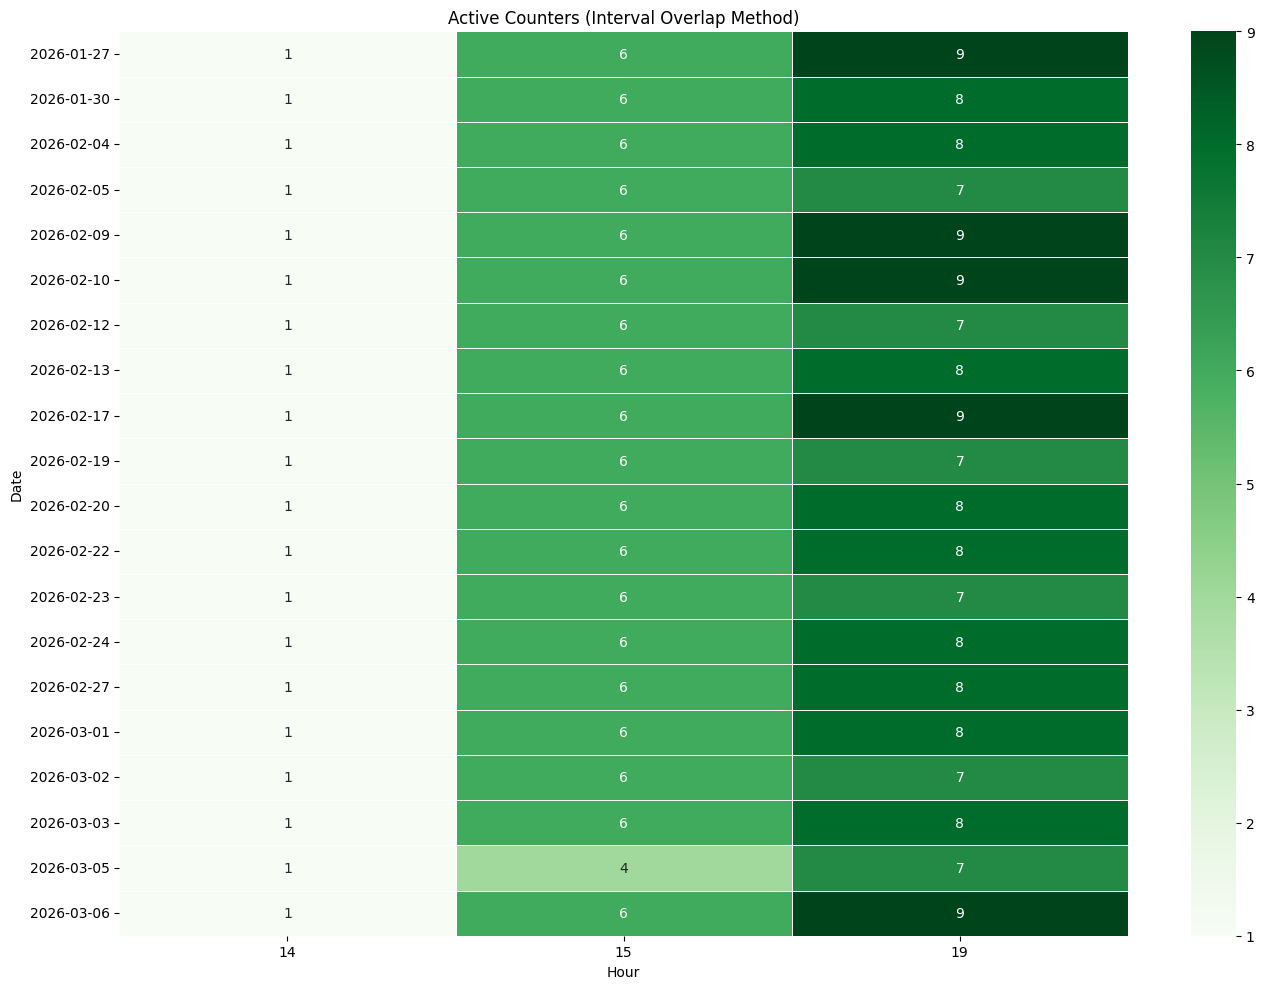

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Remove timezone if present
# ----------------------------------------

intervals_df['start'] = pd.to_datetime(
    intervals_df['start']
).dt.tz_localize(None)

intervals_df['end'] = pd.to_datetime(
    intervals_df['end']
).dt.tz_localize(None)

# ----------------------------------------
# Hours of interest
# ----------------------------------------

target_hours = [14, 15, 19]

# ----------------------------------------
# Count active counters using overlap
# ----------------------------------------

results = []

for date in worst_dates['date']:

    date = pd.to_datetime(date).date()

    for hour in target_hours:

        hour_start = pd.Timestamp(
            f"{date} {hour}:00:00"
        )

        hour_end = (
            hour_start
            + pd.Timedelta(hours=1)
        )

        # Counter active if interval overlaps hour

        active = (

            (
                intervals_df['start']
                < hour_end
            )

            &

            (
                intervals_df['end']
                > hour_start
            )

        ).sum()

        results.append({

            'date': str(date),

            'hour': hour,

            'active_counters': active

        })

# ----------------------------------------
# Create heatmap dataframe
# ----------------------------------------

active_counter_heat = pd.DataFrame(
    results
)

active_counter_heat = (

    active_counter_heat

    .pivot(
        index='date',
        columns='hour',
        values='active_counters'
    )

)

active_counter_heat = (
    active_counter_heat
    .reindex(columns=[14,15,19])
)

print(active_counter_heat)

# ----------------------------------------
# Heatmap
# ----------------------------------------

plt.figure(
    figsize=(14,10)
)

sns.heatmap(

    active_counter_heat,

    annot=True,

    fmt='g',

    cmap='Greens',

    linewidths=0.5

)

plt.title(
    "Active Counters (Interval Overlap Method)"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Date"
)

plt.tight_layout()

plt.show()

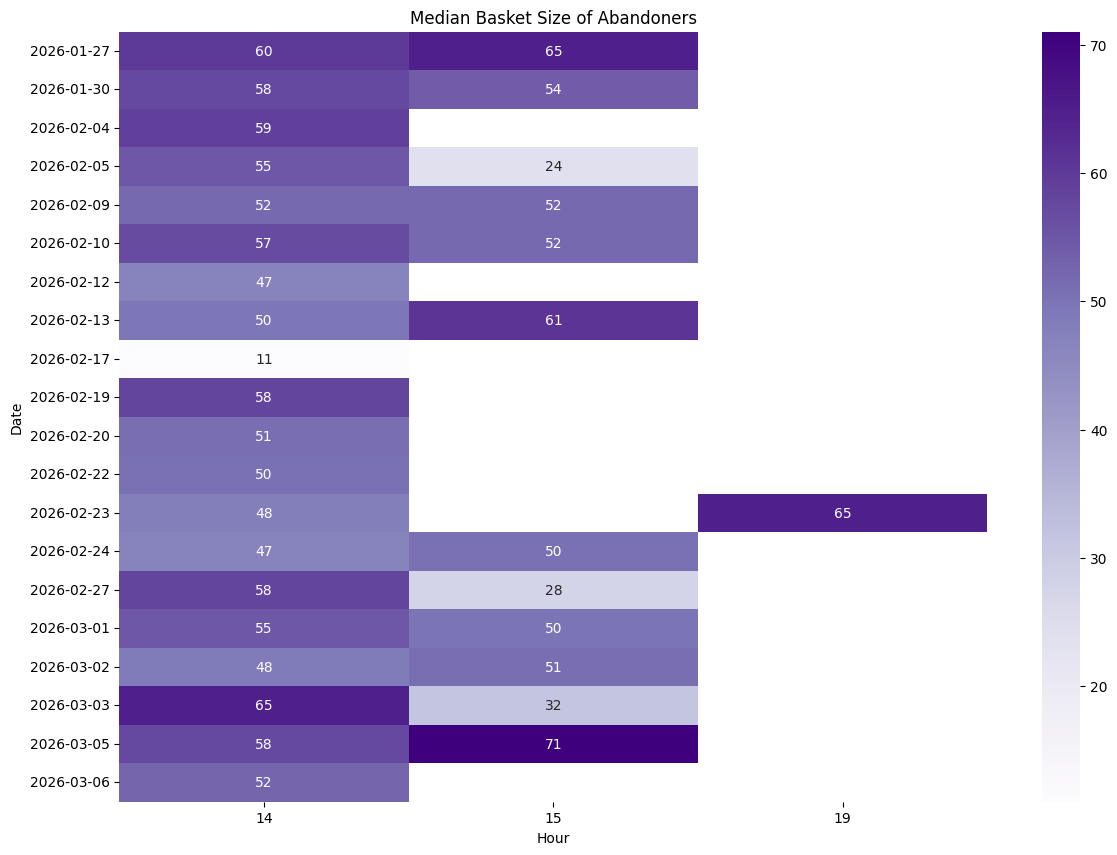

In [152]:
basket_heat = (

    abandon_df[
        (abandon_df['date'].isin(
            worst_dates['date']
        ))
        &
        (abandon_df['hour'].isin(
            target_hours
        ))
    ]

    .groupby(
        ['date','hour']
    )

    ['items']

    .median()

    .unstack()

)

basket_heat = basket_heat[
    [14,15,19]
]
plt.figure(figsize=(14,10))

sns.heatmap(
    basket_heat,
    annot=True,
    fmt='.0f',
    cmap='Purples'
)

plt.title(
    "Median Basket Size of Abandoners"
)

plt.xlabel("Hour")
plt.ylabel("Date")

plt.show()

How much load was each available counter facing on the worst abandonment dates?

then you want pressure per active counter, not just active counters.

The formula is:


Pressure=
Active Counters During Hour
Customers /Arriving During Hour
	​


In [150]:
arrival_heat.index = arrival_heat.index.astype(str)

active_counter_heat.index = active_counter_heat.index.astype(str)
pressure_heat = (
    arrival_heat
    /
    active_counter_heat.replace(0, pd.NA)
)

print(pressure_heat.head(30))

hour          14         15         19
date                                  
2026-01-27  47.0  11.000000  18.111111
2026-01-30  48.0  10.500000  18.625000
2026-02-04  43.0  13.333333  21.500000
2026-02-05  45.0  12.666667  24.285714
2026-02-09  46.0  11.500000  14.333333
2026-02-10  40.0   8.666667  16.111111
2026-02-12  48.0  11.000000  22.571429
2026-02-13  40.0  11.666667  17.250000
2026-02-17  43.0  11.833333  15.777778
2026-02-19  41.0  11.666667  21.142857
2026-02-20  48.0   9.166667  17.375000
2026-02-22  48.0  14.333333  20.750000
2026-02-23  38.0  11.333333  23.714286
2026-02-24  41.0   9.666667  17.875000
2026-02-27  40.0  10.000000  19.375000
2026-03-01  47.0  11.666667  19.500000
2026-03-02  49.0  11.000000  21.142857
2026-03-03  43.0  10.833333  16.250000
2026-03-05  37.0  11.500000  11.857143
2026-03-06  45.0   8.166667  15.888889


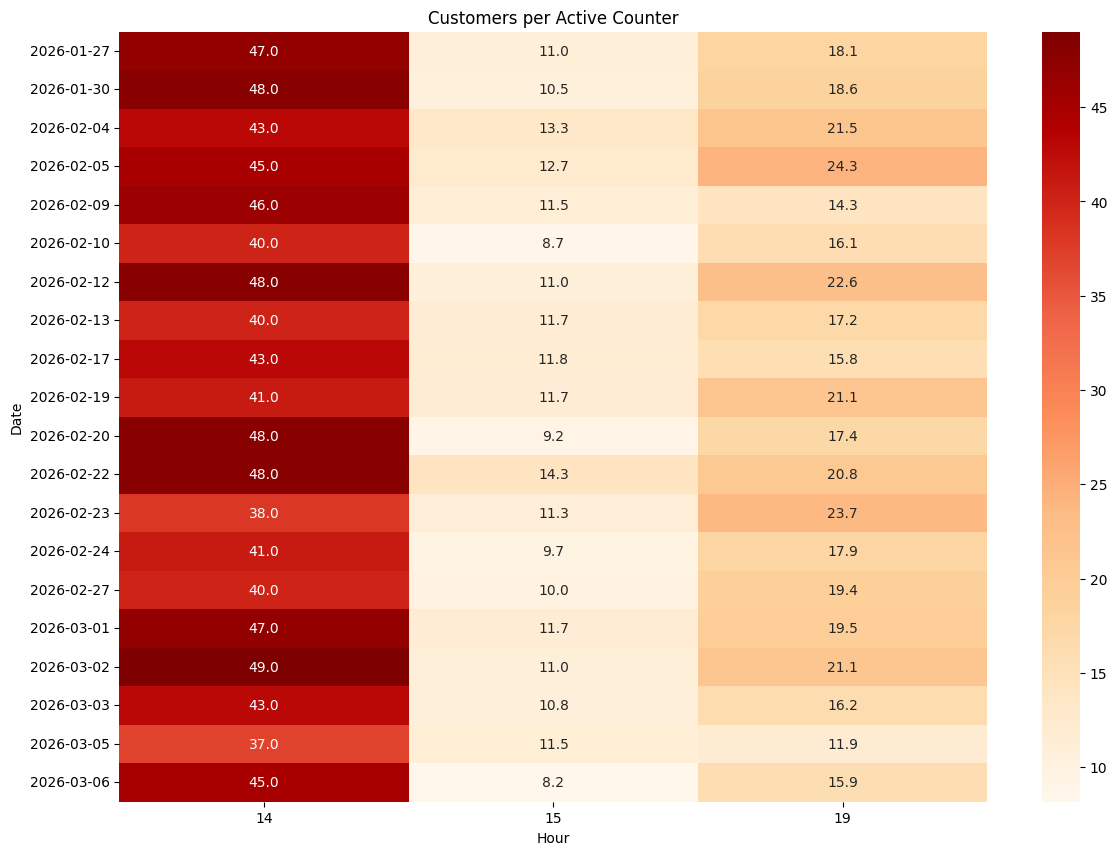

In [67]:
plt.figure(figsize=(14,10))

sns.heatmap(
    pressure_heat,
    annot=True,
    fmt='.1f',
    cmap='OrRd'
)

plt.title(
    "Customers per Active Counter"
)

plt.xlabel("Hour")
plt.ylabel("Date")

plt.show()

## Dividing deeper into queue length to identify if that is what causes abandonment at 14:00

In [81]:
first_scan = (

    log_df_customer[
        log_df_customer['concept:name']
        == 'Scan Item'
    ]

    .copy()

)

first_scan['date'] = (
    first_scan['time:timestamp']
    .dt.date
)

first_scan = (

    first_scan

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [82]:
print(first_scan.columns)

Index(['case:concept:name', 'date', 's', 'concept:name', 'cnt', 'x', 'y',
       'lifecycle:transition', 'items', 'time:timestamp', 'p', 'col', 'iMI',
       'i', 'q', 'pc', 'mC', 'mI', 'iMC', 'cid', 'b', 'clid'],
      dtype='object')


In [83]:
print(
    first_scan['concept:name']
    .value_counts(dropna=False)
)

concept:name
Scan Item    25325
Name: count, dtype: int64


In [96]:
enter_queue = (

    log_df_customer[
        log_df_customer['concept:name']
        == 'Enter Queue'
    ]

    .copy()

)

enter_queue['date'] = (
    enter_queue['time:timestamp']
    .dt.date
)

enter_queue = (

    enter_queue

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [97]:
print(
    enter_queue['concept:name']
    .value_counts(dropna=False)
)

concept:name
Enter Queue    25325
Name: count, dtype: int64


In [99]:
enter_queue[
    enter_queue["time:timestamp"]
    .dt.date
    ==
    pd.to_datetime("2026-02-23").date()
]

,case:concept:name,date,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,...,iMI,i,q,pc,mC,mI,iMC,cid,b,clid
3840,2178,2026-02-23,lRandom,Enter Queue,NaN,NaN,NaN,complete,59.0,2026-02-23 14:03:30.540000+00:00,...,0.0,0.0,[],0.0,0.0,0.0,0.0,0.0,None,NaN
3842,2179,2026-02-23,lCust,Enter Queue,NaN,NaN,NaN,complete,58.0,2026-02-23 14:03:31.407000+00:00,...,0.0,59.0,[2178],0.0,1.0,59.0,0.0,0.0,None,NaN
3848,2180,2026-02-23,lRandom,Enter Queue,NaN,NaN,NaN,complete,65.0,2026-02-23 14:04:59.024000+00:00,...,0.0,88.0,"[2178,2179]",0.0,2.0,88.0,0.0,0.0,None,NaN
3851,2181,2026-02-23,lCust,Enter Queue,NaN,NaN,NaN,complete,55.0,2026-02-23 14:07:50.240000+00:00,...,0.0,115.0,"[2179,2180,2182]",0.0,3.0,115.0,0.0,0.0,None,NaN
3854,2182,2026-02-23,lRandom,Enter Queue,NaN,NaN,NaN,complete,8.0,2026-02-23 14:07:07.056000+00:00,...,0.0,122.0,"[2179,2180]",0.0,2.0,122.0,0.0,0.0,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6296,2940,2026-02-23,lCust,Enter Queue,NaN,NaN,NaN,complete,76.0,2026-02-23 21:59:12.786000+00:00,...,1.0,0.0,[],0.0,0.0,0.0,1.0,11.0,None,NaN
6299,2941,2026-02-23,lItem,Enter Queue,NaN,NaN,NaN,complete,46.0,2026-02-23 21:58:13.177000+00:00,...,1.0,0.0,[2938],0.0,0.0,0.0,1.0,8.0,None,NaN
6302,2942,2026-02-23,lRandom,Enter Queue,NaN,NaN,NaN,complete,5.0,2026-02-23 21:58:03.900000+00:00,...,1.0,0.0,[],0.0,0.0,0.0,1.0,6.0,None,NaN
6305,2943,2026-02-23,lCust,Enter Queue,NaN,NaN,NaN,complete,54.0,2026-02-23 21:59:48.527000+00:00,...,1.0,0.0,[],0.0,0.0,0.0,1.0,10.0,None,NaN


In [100]:
log_df_customer[
    log_df_customer["time:timestamp"]
    .dt.date
    ==
    pd.to_datetime("2026-02-23").date()
]

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,i,q,pc,mC,mI,iMC,cid,b,clid,case:concept:name
366153,lRandom,Enter store,0.0,28.0,3.0,complete,59.0,2026-02-23 14:00:00+00:00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2178
366154,lRandom,Pickup Item,NaN,0.0,NaN,complete,59.0,2026-02-23 14:00:00+00:00,Cash,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2178
366155,lRandom,Pickup Item,NaN,1.0,NaN,complete,59.0,2026-02-23 14:00:03.254000+00:00,Cash,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2178
366156,lRandom,Pickup Item,NaN,2.0,NaN,complete,59.0,2026-02-23 14:00:05.661000+00:00,Cash,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2178
366157,lRandom,Pickup Item,NaN,3.0,NaN,complete,59.0,2026-02-23 14:00:09.968000+00:00,Cash,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606568,lRandom,Scan Item,NaN,NaN,NaN,complete,3.0,2026-02-23 22:07:37.125000+00:00,Pin,"[(0,0,0,true),(1,0,0,true),(2,0,0,false),(3,0,...",...,3.0,[],0.0,0.0,0.0,0.0,7.0,False,NaN,2944
606569,lRandom,Scan Item,NaN,NaN,NaN,complete,2.0,2026-02-23 22:07:39.739000+00:00,Pin,"[(0,0,0,true),(1,0,0,true),(2,0,0,false),(3,0,...",...,2.0,[],0.0,0.0,0.0,0.0,7.0,False,NaN,2944
606570,lRandom,Scan Item,NaN,NaN,NaN,complete,1.0,2026-02-23 22:07:42.688000+00:00,Pin,"[(0,0,0,true),(1,0,0,true),(2,0,0,false),(3,0,...",...,1.0,[],0.0,0.0,0.0,0.0,7.0,False,NaN,2944
606571,lRandom,Start Payment,NaN,NaN,NaN,complete,NaN,2026-02-23 22:07:45.509000+00:00,Pin,NaN,...,0.0,[],NaN,NaN,NaN,NaN,7.0,NaN,NaN,2944


In [103]:
wait_df = enter_queue.merge(

    first_scan[
        [
            'case:concept:name',
            'date',
            'time:timestamp'
        ]
    ],

    on=[
        'case:concept:name',
        'date'
    ],

    suffixes=(
        '_enter',
        '_scan'
    )

)
#Step 4: Compute Wait Time (it is  for those who entered the queue)
wait_df['wait_minutes'] = (

    wait_df['time:timestamp_scan']

    -

    wait_df['time:timestamp_enter']

).dt.total_seconds() / 60
#Step 5: Attach Date + Hour
wait_df['date'] = (
    wait_df['time:timestamp_enter']
    .dt.date
)

wait_df['hour'] = (
    wait_df['time:timestamp_enter']
    .dt.hour
)
#Step 6: Analyze Worst Dates
wait_heat = (

    wait_df[
        (wait_df['date'].isin(
            worst_dates['date']
        ))
        &
        (wait_df['hour'].isin(
            [14,15,19]
        ))
    ]

    .groupby(
        ['date','hour']
    )

    ['wait_minutes']

    .median()

    .unstack()

)

In [104]:
wait_summary = (

    wait_df[

        (wait_df['date'].isin(
            worst_dates['date']
        ))

        &

        (wait_df['hour'].isin(
            [14,15,19]
        ))

    ]

    .groupby(
        ['date','hour']
    )

    ['wait_minutes']

    .agg(
        median_wait='median',
        mean_wait='mean',
        p90_wait=lambda x: x.quantile(0.90),
        customers='count'
    )

    .reset_index()

)

In [105]:
wait_summary.head(40)

,date,hour,median_wait,mean_wait,p90_wait,customers
0,2026-01-27,14,9.406767,7.263605,12.861575,20
1,2026-01-27,15,0.054900,0.802023,3.337992,60
2,2026-01-27,19,0.365858,1.267021,3.823667,146
3,2026-01-30,14,9.122550,7.914617,11.168767,21
4,2026-01-30,15,0.056650,1.499620,3.851863,55
5,2026-01-30,19,1.266550,1.818842,4.833530,135
6,2026-02-04,14,9.457717,8.657265,13.047363,19
7,2026-02-04,15,0.058933,0.758552,2.781017,73
8,2026-02-04,19,3.918017,4.755570,10.488830,159
9,2026-02-05,14,9.513083,8.435141,13.091123,19


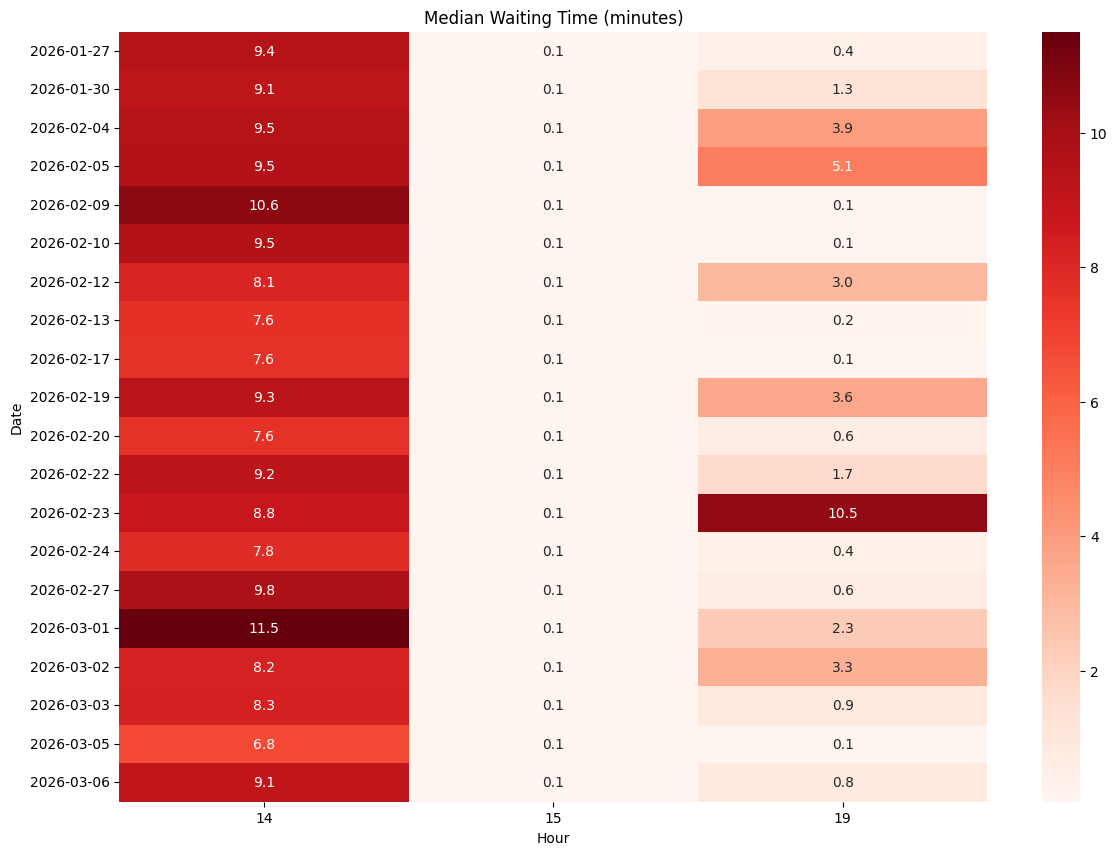

In [106]:
median_heat = (

    wait_summary

    .pivot(
        index='date',
        columns='hour',
        values='median_wait'
    )

)

plt.figure(figsize=(14,10))

sns.heatmap(

    median_heat,

    annot=True,

    fmt='.1f',

    cmap='Reds'

)

plt.title(
    'Median Waiting Time (minutes)'
)

plt.xlabel('Hour')
plt.ylabel('Date')

plt.show()

## Queue Length not Customer Arrival a reason for cart abandonment at 14:00 because that builds up and leads to a domino effect

In [166]:
wait_df[wait_df["date"]==pd.to_datetime("2026-03-02").date()]

,case:concept:name,date,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp_enter,...,pc,mC,mI,iMC,cid,b,clid,time:timestamp_scan,wait_minutes,hour
18363,6636,2026-03-02,lItem,Enter Queue,NaN,NaN,NaN,complete,59.0,2026-03-02 14:03:28.294000+00:00,...,0.0,1.0,0.0,0.0,0.0,None,NaN,2026-03-02 14:03:43.087000+00:00,0.246550,14
18366,6637,2026-03-02,lCust,Enter Queue,NaN,NaN,NaN,complete,48.0,2026-03-02 14:03:29.626000+00:00,...,0.0,2.0,59.0,0.0,0.0,None,NaN,2026-03-02 14:07:38.477000+00:00,4.147517,14
18369,6638,2026-03-02,lItem,Enter Queue,NaN,NaN,NaN,complete,5.0,2026-03-02 14:02:58.224000+00:00,...,0.0,0.0,0.0,0.0,0.0,None,NaN,2026-03-02 14:03:00.508000+00:00,0.038067,14
18372,6639,2026-03-02,lCust,Enter Queue,NaN,NaN,NaN,complete,49.0,2026-03-02 14:04:18.611000+00:00,...,0.0,2.0,95.0,0.0,0.0,None,NaN,2026-03-02 14:10:49.254000+00:00,6.510717,14
18377,6640,2026-03-02,lCust,Enter Queue,NaN,NaN,NaN,complete,56.0,2026-03-02 14:08:24.301000+00:00,...,0.0,3.0,129.0,0.0,0.0,None,NaN,2026-03-02 14:17:19.850000+00:00,8.925817,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20678,7362,2026-03-02,lCust,Enter Queue,NaN,NaN,NaN,complete,15.0,2026-03-02 21:53:25.174000+00:00,...,0.0,0.0,0.0,0.0,10.0,None,NaN,2026-03-02 21:53:28.261000+00:00,0.051450,21
20681,7363,2026-03-02,lRandom,Enter Queue,NaN,NaN,NaN,complete,51.0,2026-03-02 21:55:29.554000+00:00,...,0.0,0.0,0.0,0.0,11.0,None,NaN,2026-03-02 21:55:32.191000+00:00,0.043950,21
20684,7364,2026-03-02,lRandom,Enter Queue,NaN,NaN,NaN,complete,4.0,2026-03-02 21:54:49.920000+00:00,...,0.0,0.0,0.0,0.0,10.0,None,NaN,2026-03-02 21:54:53.917000+00:00,0.066617,21
20687,7365,2026-03-02,lItem,Enter Queue,NaN,NaN,NaN,complete,55.0,2026-03-02 21:58:38.050000+00:00,...,0.0,0.0,0.0,0.0,5.0,None,NaN,2026-03-02 21:58:40.808000+00:00,0.045967,21


In [109]:
date_to_check = '2026-02-27'
hour_to_check = 14
#Step 2: How many customers entered queue?
temp = customer_df[
    (customer_df['date'].astype(str) == date_to_check)
    &
    (customer_df['hour'] == hour_to_check)
    &
    (
        customer_df['concept:name']
        .isin([
            'Enter Queue',
            'Scan Item'
        ])
    )
]

In [110]:
temp.head()

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp,p,col,...,mC,mI,iMC,cid,b,clid,case:concept:name,hour,weekday,date
1079339,lItem,Enter Queue,NaN,NaN,NaN,complete,59.0,2026-02-27 14:03:28.995000+00:00,Pin,"[(0,0,0,true),(1,0,0,false),(2,0,0,false),(3,0...",...,0.0,0.0,0.0,0.0,NaN,NaN,4442,14,Friday,2026-02-27
1079340,lItem,Scan Item,NaN,NaN,NaN,complete,59.0,2026-02-27 14:03:32.263000+00:00,Pin,"[(0,1,59,true),(1,0,0,false),(2,0,0,false),(3,...",...,1.0,59.0,0.0,0.0,False,NaN,4442,14,Friday,2026-02-27
1079341,lItem,Scan Item,NaN,NaN,NaN,complete,58.0,2026-02-27 14:03:35.994000+00:00,Pin,"[(0,1,58,true),(1,0,0,false),(2,0,0,false),(3,...",...,1.0,58.0,0.0,0.0,False,NaN,4442,14,Friday,2026-02-27
1079342,lItem,Scan Item,NaN,NaN,NaN,complete,57.0,2026-02-27 14:03:39.339000+00:00,Pin,"[(0,1,57,true),(1,0,0,false),(2,0,0,false),(3,...",...,1.0,57.0,0.0,0.0,False,NaN,4442,14,Friday,2026-02-27
1079343,lItem,Scan Item,NaN,NaN,NaN,complete,56.0,2026-02-27 14:03:41.781000+00:00,Pin,"[(0,1,56,true),(1,0,0,false),(2,0,0,false),(3,...",...,1.0,56.0,0.0,0.0,False,NaN,4442,14,Friday,2026-02-27


In [111]:
target_date = pd.to_datetime(
    '2026-02-22'
).date()

found = False

for cid, trace in customer_df.groupby(
    'case:concept:name'
):

    trace = trace.sort_values(
        'time:timestamp'
    )

    # only events from target day
    day_trace = trace[
        trace['time:timestamp']
        .dt.date
        == target_date
    ]

    if len(day_trace) == 0:
        continue

    abandon_rows = day_trace[
        day_trace['concept:name']
        == 'Abandon cart and leave'
    ]

    if len(abandon_rows) == 0:
        continue

    abandon_time = abandon_rows[
        'time:timestamp'
    ].iloc[0]

    entered_before = (

        (
            day_trace['concept:name']
            == 'Enter Queue'
        )

        &

        (
            day_trace['time:timestamp']
            < abandon_time
        )

    ).any()

    if entered_before:

        print("="*70)
        print("Customer:", cid)
        print("Abandon Time:", abandon_time)
        print("="*70)

        print(
            day_trace[
                [
                    'time:timestamp',
                    'concept:name'
                ]
            ]
        )

        found = True
        break

if not found:
    print(
        "No queue abandoner found on",
        target_date
    )

No queue abandoner found on 2026-02-22


In [112]:

complete_cases = set(

    customer_df[
        customer_df['concept:name']
        == 'Complete Payment'
    ]['case:concept:name']

)

complete_df = customer_df[
    customer_df['case:concept:name']
    .isin(complete_cases)
]
print(
    abandon_df['items'].median()
)

print(
    complete_df['items'].median()
)

#and also:

print(
    abandon_df['items'].quantile(
        [0.25,0.5,0.75]
    )
)

print(
    complete_df['items'].quantile(
        [0.25,0.5,0.75]
    )
)


54.0
51.0
0.25    12.0
0.50    54.0
0.75    64.0
Name: items, dtype: float64
0.25    26.0
0.50    51.0
0.75    62.0
Name: items, dtype: float64


Items not the sole cause of abandonment but a contributor definitely, for abandoned median is 54 and not abandoned it is 51, and 75% of items abandoned are relatively heavy i.e above 12. So seeing heavy baskets definitely leads to abanadonment, at 14:00. 

## Looking in detail at the customers abandoning at 19:00 pm on 23-02-2026

In [113]:
problem_date = pd.to_datetime(
    '2026-02-23'
).date()

problem_hour = 19

In [114]:
abandoners = (

    abandon_df[
        (abandon_df['date'] == problem_date)
        &
        (abandon_df['hour'] == problem_hour)
    ]

    ['case:concept:name']

    .nunique()

)

print(
    "Unique abandoners:",
    abandoners
)

Unique abandoners: 8


In [115]:
arrivals = (

    customer_df[
        (customer_df['date'] == problem_date)
        &
        (customer_df['hour'] == problem_hour)
    
    ]

    ['case:concept:name']

    .nunique()

)

print(
    "Arrivals:",
    arrivals
)

print(
    "Abandonment Rate:",
    round(
        abandoners
        /
        arrivals
        * 100,
        2
    )
)

Arrivals: 166
Abandonment Rate: 4.82


In [122]:
abandon_cases = (

    abandon_df[
        (abandon_df['date'] == problem_date)
        &
        (abandon_df['hour'] == problem_hour)
    ]

    ['case:concept:name']

    .unique()

)

print(
    "Number of abandoning customers:",
    len(abandon_cases)
)
for cid in abandon_cases[:1]:

    print("\n")
    print("="*70)

    print(
        "Customer:",
        cid
    )

    print("="*70)

    print(

        customer_df[
            customer_df[
                'case:concept:name'
            ]
            == cid
        ]

        [
            [
                'time:timestamp',
                'concept:name'
            ]
        ]

        .sort_values(
            'time:timestamp'
        )

    )

Number of abandoning customers: 8


Customer: 2678
                         time:timestamp            concept:name
521432 2026-01-29 19:48:03.584000+00:00             Enter store
521433 2026-01-29 19:48:03.584000+00:00             Pickup Item
521434 2026-01-29 19:48:07.483000+00:00             Pickup Item
521435 2026-01-29 19:48:10.900000+00:00             Pickup Item
521436 2026-01-29 19:48:15.072000+00:00             Pickup Item
...                                 ...                     ...
521812 2026-02-23 19:21:40.290000+00:00             Pickup Item
521813 2026-02-23 19:21:43.372000+00:00             Pickup Item
521814 2026-02-23 19:21:46.846000+00:00             Pickup Item
521815 2026-02-23 19:21:50.983000+00:00          Go to Checkout
521816 2026-02-23 19:26:00.983000+00:00  Abandon cart and leave

[385 rows x 2 columns]


High waiting time no doubt experienced.
Checked active counters found 7 of them.
Customer Arrival not the reason


In [185]:
cashier_window = cashier_df[

    (cashier_df['time:timestamp']
     .dt.date == target_date)

    &

    (cashier_df['time:timestamp']
     .dt.hour.isin([18,19]))

]
print(
    cashier_window[
        'concept:name'
    ].value_counts()
)
print(

    cashier_window[
        [
            'case:concept:name',
            'time:timestamp',
            'concept:name'
        ]
    ]

)

concept:name
End shift        6
Close counter    6
Open counter     3
Start Shift      3
Name: count, dtype: int64
     case:concept:name                   time:timestamp   concept:name
196                 13        2026-02-23 18:00:00+00:00    Start Shift
197                 13        2026-02-23 18:00:00+00:00   Open counter
308                 14        2026-02-23 18:00:00+00:00    Start Shift
309                 14        2026-02-23 18:00:00+00:00   Open counter
420                 15        2026-02-23 18:00:00+00:00    Start Shift
421                 15        2026-02-23 18:00:00+00:00   Open counter
678                  2        2026-02-23 18:00:00+00:00  Close counter
679                  2        2026-02-23 18:00:00+00:00      End shift
1154                 3        2026-02-23 19:00:00+00:00  Close counter
1155                 3        2026-02-23 19:00:00+00:00      End shift
1538                 4        2026-02-23 19:00:00+00:00  Close counter
1539                 4 2026-02-23

In [186]:
for cashier in sorted(
    cashier_window[
        'case:concept:name'
    ].unique()
):

    print("\n")
    print("="*60)
    print("Cashier:", cashier)
    print("="*60)

    print(

        cashier_window[
            cashier_window[
                'case:concept:name'
            ]
            == cashier
        ]

        [
            [
                'time:timestamp',
                'concept:name'
            ]
        ]

        .sort_values(
            'time:timestamp'
        )

    )



Cashier: 13
               time:timestamp  concept:name
196 2026-02-23 18:00:00+00:00   Start Shift
197 2026-02-23 18:00:00+00:00  Open counter


Cashier: 14
               time:timestamp  concept:name
308 2026-02-23 18:00:00+00:00   Start Shift
309 2026-02-23 18:00:00+00:00  Open counter


Cashier: 15
               time:timestamp  concept:name
420 2026-02-23 18:00:00+00:00   Start Shift
421 2026-02-23 18:00:00+00:00  Open counter


Cashier: 2
               time:timestamp   concept:name
678 2026-02-23 18:00:00+00:00  Close counter
679 2026-02-23 18:00:00+00:00      End shift


Cashier: 3
                time:timestamp   concept:name
1154 2026-02-23 19:00:00+00:00  Close counter
1155 2026-02-23 19:00:00+00:00      End shift


Cashier: 4
                       time:timestamp   concept:name
1538        2026-02-23 19:00:00+00:00  Close counter
1539 2026-02-23 19:00:27.812000+00:00      End shift


Cashier: 5
                       time:timestamp   concept:name
1826        2026-02-23 19

In [139]:
clerk_window = log_df_clerk[

    (log_df_clerk['time:timestamp']
     .dt.date == target_date)

    &

    (log_df_clerk['time:timestamp']
     .dt.hour.isin([18,19]))

]
print(
    clerk_window[
        'concept:name'
    ].value_counts()
)

concept:name
Start Price Check         148
End price check           146
Cleanup abandoned item     50
Name: count, dtype: int64


In [149]:
target_date = pd.to_datetime(
    '2026-02-23'
).date()
manager_window = log_df_manager[

    (log_df_manager['time:timestamp']
     .dt.date == target_date)
]
print(
    manager_window[
        'concept:name'
    ].value_counts()
)

concept:name
Start Shift    1
End Shift      1
Name: count, dtype: int64


In [196]:
manager_window.head()

,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
68,complete,Start Shift,2026-02-23 14:00:00+00:00,0,202
69,complete,End Shift,2026-02-23 22:08:38.412000+00:00,0,202


I only notice shift changes which could be an area, but even payment type is PIN only. 

In [ ]:
cashiers_7pm = (

    cashier_df[
        cashier_df['time:timestamp']
        .dt.hour
        == 19
    ]

    .assign(
        date=lambda x:
        x['time:timestamp'].dt.date
    )

    .groupby('date')

    ['case:concept:name']

    .nunique()

    .rename(
        'active_cashiers'
    )

)
print(
    "Mean cashiers at 7 PM:",
    round(
        cashiers_7pm.mean(),
        2
    )
)

print(
    "Median cashiers at 7 PM:",
    cashiers_7pm.median()
)

Mean cashiers at 7 PM: 5.03
Median cashiers at 7 PM: 5.0


In [173]:
clerks_active = (

    log_df_clerk[

        (log_df_clerk['time:timestamp']
         .dt.date == target_date)

        &

        (log_df_clerk['time:timestamp']
         .dt.hour == target_hour)

    ]

    ['case:concept:name']

    .nunique()

)

print(
    "Active clerks:",
    clerks_active
)

Active clerks: 10


Only doing Pin Payments, They are either LItem or Loyalty customers who are abandoning
#Apart from high waiting time formed due to item size, I could not find any lack of resource (they all were above 60), although we have some other items that have similar median as well but at that time the arrivals had not peaked as well.
Cashiers mean is 5 on 7pm on other days it is ok, but problem occurs the week after carnival when people after work go to market to buy stuff. Yes for other weeks cashiers maybe low as well but they are not met with same basket size as waiting time encountered is less.Price checks happen more at 19:00, and if already large carts, and they are abandoned they would occupy aisle as well leading to more abandonment

In [ ]:
#Check for total clerks and cashiers including ones from previous hours again
#Items purchased at 7pm on other days (esp when cashier count is low)

In [187]:
complete_df.groupby('hour')['items'].median()

hour
14    56.0
15    50.0
16    51.0
17    51.0
18    51.0
19    51.0
20    50.0
21    50.0
22    35.0
Name: items, dtype: float64

In [188]:
abandon_df.groupby('hour')['items'].median()

hour
14    55.0
15    50.0
19    65.0
Name: items, dtype: float64

In [ ]:
log_df_customer['date'] = (
    log_df_customer['time:timestamp']
    .dt.date
)

log_df_customer['hour'] = (
    log_df_customer['time:timestamp']
    .dt.hour
)

items_7pm = (

    log_df_customer[
        log_df_customer['hour']==19
    ]

    ['items']
)

target_day = pd.to_datetime(
    '2026-02-23'
).date()

target_items = (

    log_df_customer[
        (log_df_customer['date']==target_day)
        &
        (log_df_customer['hour']==19)
    ]

    ['items']
)

In [195]:
print(
    "Typical 7PM basket:",
    items_7pm.median()
)

print(
    "23-Feb 7PM basket:",
    target_items.median()
)

Typical 7PM basket: 51.0
23-Feb 7PM basket: 54.0


Inspecting resources again

In [197]:
print(
    cashier_df['concept:name']
    .value_counts()
)

concept:name
Start Shift      732
Open counter     732
Close counter    732
End shift        732
Name: count, dtype: int64


In [198]:
print(
    sorted(
        cashier_df['concept:name']
        .unique()
    )
)

['Close counter', 'End shift', 'Open counter', 'Start Shift']


In [200]:
print(
    sorted(
        log_df_clerk['concept:name']
        .unique()
    )
)

['Cleanup abandoned item', 'End price check', 'Start Price Check']


In [201]:
cashier_df['date'] = (
    cashier_df['time:timestamp']
    .dt.date
)

cashier_start = (

    cashier_df[
        cashier_df['concept:name']
        == 'Start Shift'
    ]

    .groupby(
        ['case:concept:name','date']
    )

    ['time:timestamp']

    .min()

    .reset_index(
        name='start_time'
    )

)

cashier_end = (

    cashier_df[
        cashier_df['concept:name']
        == 'End shift'
    ]

    .groupby(
        ['case:concept:name','date']
    )

    ['time:timestamp']

    .max()

    .reset_index(
        name='end_time'
    )

)

cashier_intervals = (

    cashier_start.merge(

        cashier_end,

        on=[
            'case:concept:name',
            'date'
        ]

    )

)

In [204]:
target_hours = [14,15,19]

cashier_duty_data = []

for d in worst_dates['date']:

    weekday = (

        worst_dates[
            worst_dates['date']
            == d
        ]

        ['weekday']

        .iloc[0]

    )

    for h in target_hours:

        ts = pd.Timestamp(
            str(d)
            +
            f' {h:02d}:00:00',tz="UTC"
        )

        n_cashiers = (

            cashier_intervals[

                (cashier_intervals['date']
                 == d)

                &

                (
                    cashier_intervals['start_time']
                    <= ts
                )

                &

                (
                    cashier_intervals['end_time']
                    >= ts
                )

            ]

            ['case:concept:name']

            .nunique()

        )

        cashier_duty_data.append(
            [
                d,
                weekday,
                h,
                n_cashiers
            ]
        )

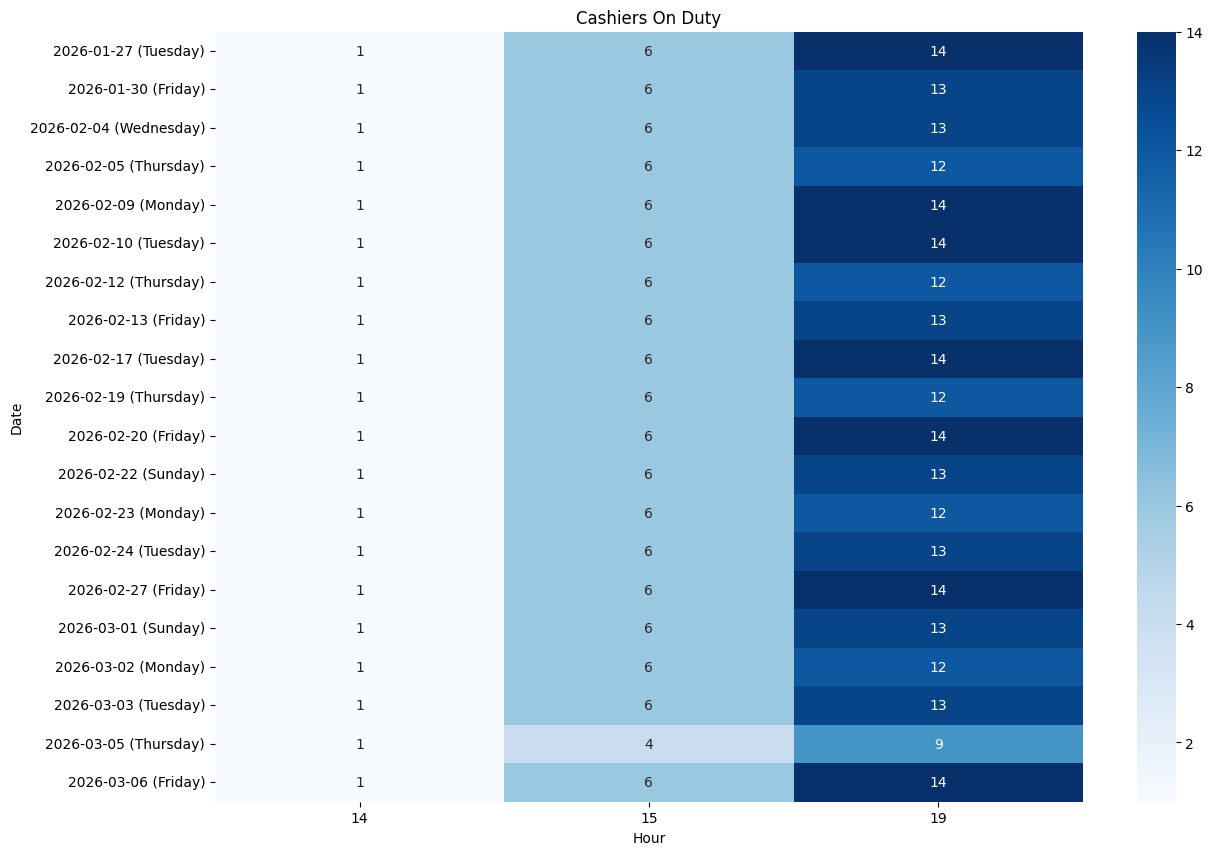

In [205]:
cashier_duty_data = pd.DataFrame(

    cashier_duty_data,

    columns=[
        'date',
        'weekday',
        'hour',
        'cashiers_on_duty'
    ]

)

cashier_duty_data['date_label'] = (

    cashier_duty_data['date']
    .astype(str)

    +

    ' ('

    +

    cashier_duty_data['weekday']

    +

    ')'

)

cashier_duty_heat = (

    cashier_duty_data

    .pivot(

        index='date_label',

        columns='hour',

        values='cashiers_on_duty'

    )

)

plt.figure(
    figsize=(14,10)
)

sns.heatmap(

    cashier_duty_heat,

    annot=True,

    fmt='g',

    cmap='Blues'

)

plt.title(
    'Cashiers On Duty'
)

plt.xlabel('Hour')
plt.ylabel('Date')

plt.show()

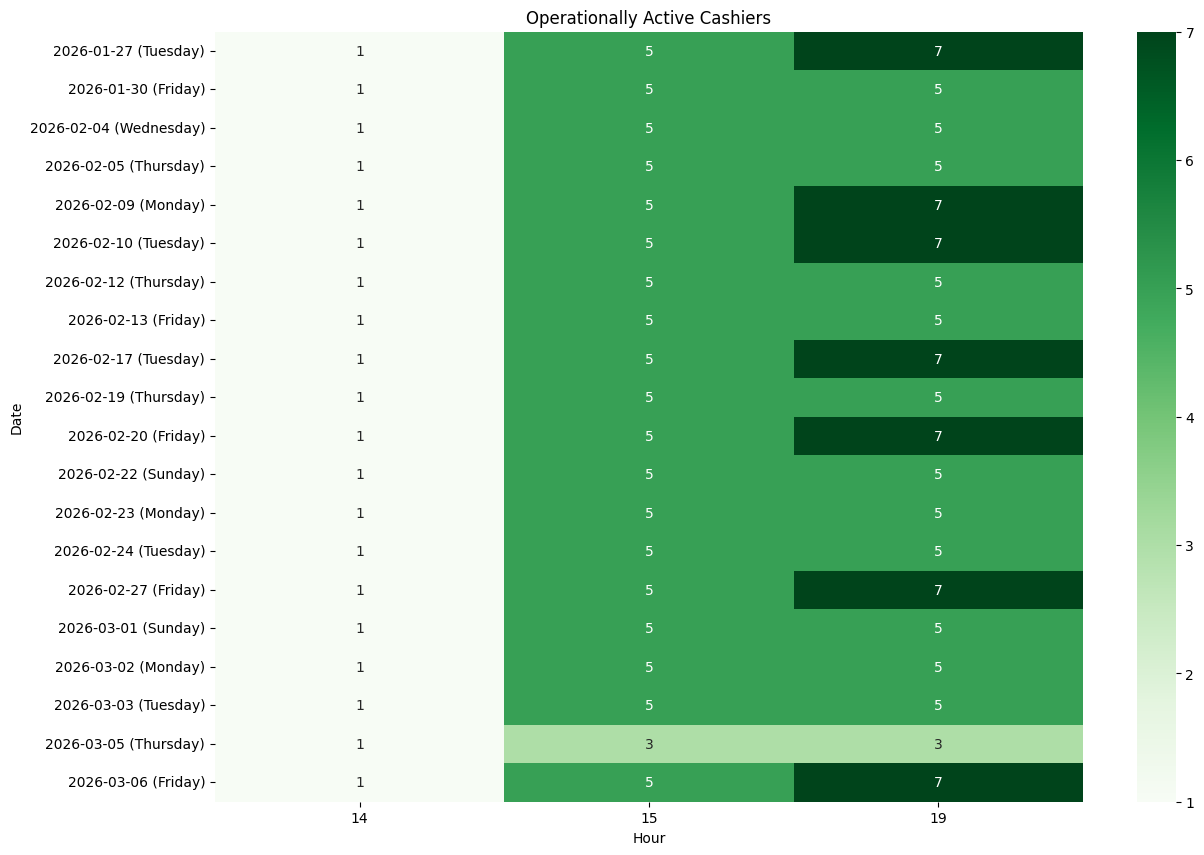

In [207]:
#Cashiers that generate atleast one event in the hour (not just on duty)
cashier_df['date'] = (
    cashier_df['time:timestamp']
    .dt.date
)

cashier_df['hour'] = (
    cashier_df['time:timestamp']
    .dt.hour
)
cashier_active_heat = (

    cashier_df[

        (cashier_df['date'].isin(
            worst_dates['date']
        ))

        &

        (cashier_df['hour'].isin(
            [14,15,19]
        ))

    ]

    .groupby(
        ['date','hour']
    )

    ['case:concept:name']

    .nunique()

    .unstack(
        fill_value=0
    )

)
date_labels = (

    worst_dates

    .set_index('date')

    ['weekday']

)

cashier_active_heat.index = [

    f"{d} ({date_labels[d]})"

    for d in cashier_active_heat.index

]
plt.figure(
    figsize=(14,10)
)

sns.heatmap(

    cashier_active_heat,

    annot=True,

    fmt='g',

    cmap='Greens'

)

plt.title(
    'Operationally Active Cashiers'
)

plt.xlabel('Hour')
plt.ylabel('Date')

plt.show()

# Establishing how much do the variables affect waiting time

In [37]:
go_checkout = (

    log_df_customer[
        log_df_customer['concept:name']
        == 'Go to Checkout'
    ]

    .copy()

)

go_checkout['date'] = (
    go_checkout['time:timestamp']
    .dt.date
)

multiple_visits = (

    go_checkout

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .size()

    .reset_index(
        name='checkout_visits'
    )

)

multiple_visits = multiple_visits[
    multiple_visits['checkout_visits'] > 1
]

print(
    multiple_visits
)

Empty DataFrame
Columns: [case:concept:name, date, checkout_visits]
Index: []


In [38]:
print(
    "Customer-day combinations with >1 Go to Checkout:",
    len(multiple_visits)
)

Customer-day combinations with >1 Go to Checkout: 0


In [ ]:
#For person at checkout counter area do we know the counter he is associated with? Unbel to map currently
go_checkout = log_df_customer[
    log_df_customer['concept:name'] == 'Go to Checkout'
]

print(
    go_checkout[
        [
            'case:concept:name',
            'time:timestamp',
            'cid'
        ]
    ].head(50)
)

     case:concept:name                   time:timestamp  cid
59                   0 2026-01-26 14:03:17.627000+00:00  NaN
185                  0 2026-02-09 14:03:32.324000+00:00  NaN
311                  0 2026-02-20 14:03:16.511000+00:00  NaN
381                  1 2026-01-26 14:05:47.614000+00:00  NaN
460                  1 2026-02-09 14:07:13.361000+00:00  NaN
603                  1 2026-02-20 14:06:22.932000+00:00  NaN
679                 10 2026-01-26 14:15:16.371000+00:00  NaN
739                 10 2026-02-09 14:21:09.587000+00:00  NaN
783                 10 2026-02-20 14:16:11.612000+00:00  NaN
846                100 2026-01-26 16:16:58.923000+00:00  NaN
965                100 2026-02-09 15:59:56.734000+00:00  NaN
1086               100 2026-02-20 16:05:31.737000+00:00  NaN
1215              1000 2026-01-27 18:30:35.856000+00:00  NaN
1351              1000 2026-02-10 18:21:11.938000+00:00  NaN
1497              1000 2026-02-21 18:45:28.835000+00:00  NaN
1618              1001 2

In [39]:
#Creating date column
log_df_customer['date'] = (
    log_df_customer['time:timestamp']
    .dt.date
)


In [40]:
#Now I go to Checkout Event
go_checkout = (

    log_df_customer[

        log_df_customer['concept:name']
        == 'Go to Checkout'

    ]

    .copy()

)

In [41]:
#Keep one Go to Checkout per customer-day
go_checkout = (

    go_checkout

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [42]:
go_checkout = go_checkout[

    [
        'case:concept:name',
        'date',
        'time:timestamp',
        'items'
    ]

]

In [43]:
#renaming for clarity
go_checkout = go_checkout.rename(

    columns={

        'time:timestamp':
            'checkout_time',

        'items':
            'basket_size'

    }

)

In [44]:
go_checkout.head()

,case:concept:name,date,checkout_time,basket_size
0,0,2026-01-26,2026-01-26 14:03:17.627000+00:00,58.0
1,0,2026-02-09,2026-02-09 14:03:32.324000+00:00,61.0
2,0,2026-02-20,2026-02-20 14:03:16.511000+00:00,60.0
3,1,2026-01-26,2026-01-26 14:05:47.614000+00:00,5.0
4,1,2026-02-09,2026-02-09 14:07:13.361000+00:00,69.0


In [56]:
#enter queue event
enter_queue = (

    log_df_customer[

        log_df_customer['concept:name']
        == 'Enter Queue'

    ]

    .copy()

)

enter_queue['date'] = (

    enter_queue['time:timestamp']

    .dt.date

)

In [57]:
#First Enter Queue per customer-day
enter_queue = (

    enter_queue

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [58]:
#first scan df
first_scan = (

    log_df_customer[

        log_df_customer['concept:name']
        == 'Scan Item'

    ]

    .copy()

)

first_scan['date'] = (

    first_scan['time:timestamp']

    .dt.date

)

In [59]:
#first scan per customer per day
first_scan = (

    first_scan

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [60]:
#Merge wait time
wait_df = enter_queue.merge(

    first_scan[
        [
            'case:concept:name',
            'date',
            'time:timestamp'
        ]
    ],

    on=[
        'case:concept:name',
        'date'
    ],

    suffixes=(
        '_enter',
        '_scan'
    )

)

In [ ]:
#in minutes
wait_df['wait_minutes'] = (

    wait_df['time:timestamp_scan']

    -

    wait_df['time:timestamp_enter']

).dt.total_seconds() / 60

In [62]:
#no negatives ->verify
wait_df[
    wait_df['wait_minutes'] < 0
]

,case:concept:name,date,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp_enter,...,q,pc,mC,mI,iMC,cid,b,clid,time:timestamp_scan,wait_minutes


In [ ]:
#merging
regression_df = go_checkout.merge(

    wait_df[
        [
            'case:concept:name',
            'date',
            'wait_minutes'
        ]
    ],

    on=[
        'case:concept:name',
        'date'
    ],

    how='inner'

)

In [64]:
regression_df.head()

,case:concept:name,date,checkout_time,basket_size,active_counters_at_checkout,wait_minutes
0,0,2026-01-26,2026-01-26 14:03:17.627000+00:00,58.0,1,0.047317
1,0,2026-02-09,2026-02-09 14:03:32.324000+00:00,61.0,1,0.047433
2,0,2026-02-20,2026-02-20 14:03:16.511000+00:00,60.0,1,0.042333
3,1,2026-01-26,2026-01-26 14:05:47.614000+00:00,5.0,1,1.338367
4,1,2026-02-09,2026-02-09 14:07:13.361000+00:00,69.0,1,0.253017


In [ ]:
#rechecking for wait time
target_date = pd.Timestamp(
    "2026-02-25"
).date()

day_df = regression_df[
    regression_df['checkout_time'].dt.date
    == target_date
].copy()

hourly_wait = (

    day_df

    .groupby(
        day_df['checkout_time'].dt.hour
    )['wait_minutes']

    .agg(
        [
            'count',
            'mean',
            'median',
            'max'
        ]
    )

)

print(hourly_wait)

               count      mean    median        max
checkout_time                                      
14                22  7.167326  9.096367  13.649367
15                50  1.876980  1.081367   8.012383
16                63  0.319846  0.052583   3.681367
17                58  0.466387  0.052050   4.425567
18                61  0.236425  0.054583   2.629917
19                81  0.593677  0.054617   5.607083
20                74  1.292164  0.462092  12.066200
21                26  0.535399  0.054125   5.362400
22                 1  0.516600  0.516600   0.516600


In [65]:
# Getting active counters from counter log at the time when customer neters checkout area
#Ensuring intervals_Df exists
counter_events = log_df_counter[
    log_df_counter['concept:name'].isin(
        ['Open counter','Close counter']
    )
].copy()

counter_events = counter_events.sort_values(
    ['case:concept:name','time:timestamp']
)
counter_events = (
    log_df_counter[
        log_df_counter['concept:name'].isin(
            ['Open counter','Close counter']
        )
    ]
    .sort_values(
        ['case:concept:name','time:timestamp']
    )
)

simulation_end = (
    log_df_counter['time:timestamp']
    .max()
)

intervals = []

for counter_id, grp in counter_events.groupby(
    'case:concept:name'
):

    grp = grp.sort_values(
        'time:timestamp'
    )

    open_time = None

    for _, row in grp.iterrows():

        activity = row['concept:name']

        if activity == 'Open counter':

            # close previous interval if open exists
            if open_time is not None:

                intervals.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

            open_time = row['time:timestamp']

        elif activity == 'Close counter':

            if open_time is not None:

                intervals.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

                open_time = None

    # IMPORTANT
    # Counter opened but never closed

    if open_time is not None:

        intervals.append({

            'counter_id': counter_id,
            'start': open_time,
            'end': simulation_end

        })

intervals_df = pd.DataFrame(intervals)

print(intervals_df.head())
#-----------------------------------------
import pandas as pd

# -----------------------------------------
# Ensure timestamps are datetime
# -----------------------------------------

intervals_df['start'] = pd.to_datetime(
    intervals_df['start']
)

intervals_df['end'] = pd.to_datetime(
    intervals_df['end']
)

regression_df['checkout_time'] = pd.to_datetime(
    regression_df['checkout_time']
)

# -----------------------------------------
# Function:
# Count counters active at checkout time
# -----------------------------------------

def active_counters_at_time(ts):

    return (

        (
            intervals_df['start']
            <= ts
        )

        &

        (
            intervals_df['end']
            > ts
        )

    ).sum()

# -----------------------------------------
# Compute active counters
# -----------------------------------------

regression_df[
    'active_counters_at_checkout'
] = (

    regression_df[
        'checkout_time'
    ]

    .apply(
        active_counters_at_time
    )

)

# -----------------------------------------
# Verify
# -----------------------------------------

print(

    regression_df[
        [
            'checkout_time',
            'active_counters_at_checkout'
        ]
    ]

    .head()

)

print(
    regression_df[
        'active_counters_at_checkout'
    ].describe()
)

  counter_id                     start                              end
0          0 2026-01-26 14:00:00+00:00        2026-01-26 18:00:00+00:00
1          0 2026-01-26 18:00:00+00:00 2026-01-26 22:07:20.268000+00:00
2          0 2026-01-27 14:00:00+00:00        2026-01-27 18:00:00+00:00
3          0 2026-01-27 20:00:00+00:00 2026-01-27 22:08:06.956000+00:00
4          0 2026-01-28 14:00:00+00:00        2026-01-28 18:00:00+00:00
                     checkout_time  active_counters_at_checkout
0 2026-01-26 14:03:17.627000+00:00                            1
1 2026-02-09 14:03:32.324000+00:00                            1
2 2026-02-20 14:03:16.511000+00:00                            1
3 2026-01-26 14:05:47.614000+00:00                            1
4 2026-02-09 14:07:13.361000+00:00                            1
count    25325.000000
mean         8.418045
std          2.507760
min          1.000000
25%          7.000000
50%          9.000000
75%         10.000000
max         13.000000
Name: ac

In [ ]:
regression_df.head()

,case:concept:name,date,checkout_time,basket_size,active_counters_at_checkout,wait_minutes
0,0,2026-01-26,2026-01-26 14:03:17.627000+00:00,58.0,1,0.047317
1,0,2026-02-09,2026-02-09 14:03:32.324000+00:00,61.0,1,0.047433
2,0,2026-02-20,2026-02-20 14:03:16.511000+00:00,60.0,1,0.042333
3,1,2026-01-26,2026-01-26 14:05:47.614000+00:00,5.0,1,1.338367
4,1,2026-02-09,2026-02-09 14:07:13.361000+00:00,69.0,1,0.253017


In [ ]:
#checking if counter are working fine
target_date = pd.Timestamp("2026-02-25", tz="UTC").date()

day_intervals = intervals_df.copy()

# Convert columns properly
day_intervals['start'] = pd.to_datetime(
    day_intervals['start'],
    utc=True
)

day_intervals['end'] = pd.to_datetime(
    day_intervals['end'],
    utc=True
)

results = []

for hour in range(24):

    hour_start = pd.Timestamp(
        f"{target_date} {hour:02d}:00:00",
        tz="UTC"
    )

    hour_end = hour_start + pd.Timedelta(hours=1)

    active = (

        (day_intervals['start'] < hour_end)

        &

        (day_intervals['end'] > hour_start)

    ).sum()

    results.append({
        'hour': hour,
        'active_counters': active
    })

hourly_active = pd.DataFrame(results)

print(hourly_active)

    hour  active_counters
0      0                0
1      1                0
2      2                0
3      3                0
4      4                0
5      5                0
6      6                0
7      7                0
8      8                0
9      9                0
10    10                0
11    11                0
12    12                0
13    13                0
14    14                1
15    15                4
16    16                6
17    17                8
18    18               10
19    19                8
20    20                5
21    21                5
22    22                5
23    23                0


In [100]:
#queue state
import pandas as pd
log_df_counter['date'] = (
    pd.to_datetime(
        log_df_counter['time:timestamp']
    ).dt.date
)
counter_log = log_df_counter.copy()

counter_log['date'] = (
    counter_log['time:timestamp']
    .dt.date
)

scan_events = counter_log[
    counter_log['concept:name']
    == 'Scan Item'
].copy()
# ------------------------------------------
# Queue Entry Events
# ------------------------------------------

queue_entries = (

    log_df_counter[
        log_df_counter['concept:name']
        == 'Enter Queue'
    ]

    [
        [
            'id',
            'date',
            'case:concept:name',
            'time:timestamp'
        ]
    ]

    .copy()

)

queue_entries.columns = [

    'customer_id',
    'date',
    'counter_id',
    'enter_time'

]

# ------------------------------------------
# First Scan Event
# (customer starts being served)
# ------------------------------------------

first_scan = (

    log_df_counter[
        log_df_counter['concept:name']
        == 'Scan Item'
    ]

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'id',
            'date',
            'case:concept:name'
        ]
    )

    .first()

    .reset_index()

)

first_scan = first_scan[
    [
        'id',
        'date',
        'case:concept:name',
        'time:timestamp'
    ]
]

first_scan.columns = [

    'customer_id',
    'date',
    'counter_id',
    'scan_start'

]

# ------------------------------------------
# Merge
# ------------------------------------------

queue_state = (

    queue_entries

    .merge(

        first_scan,

        on=[
            'customer_id',
            'date',
            'counter_id',
        ],

        how='left'

    )

)

# ------------------------------------------
# Waiting time in queue
# (sanity check)
# ------------------------------------------

queue_state[
    'queue_wait_minutes'
] = (

    queue_state['scan_start']
    -
    queue_state['enter_time']

).dt.total_seconds() / 60

# ------------------------------------------
# Inspect
# ------------------------------------------

print(
    queue_state.head()
)

print(
    queue_state.columns
)

   customer_id        date counter_id                       enter_time  \
0          0.0  2026-01-26          0 2026-01-26 14:03:27.627000+00:00   
1          1.0  2026-01-26          0 2026-01-26 14:05:57.614000+00:00   
2          2.0  2026-01-26          0 2026-01-26 14:11:37.839000+00:00   
3          6.0  2026-01-26          0 2026-01-26 14:13:55.893000+00:00   
4          8.0  2026-01-26          0 2026-01-26 14:14:24.888000+00:00   

                        scan_start  queue_wait_minutes  
0 2026-01-26 14:03:30.466000+00:00            0.047317  
1 2026-01-26 14:07:17.916000+00:00            1.338367  
2 2026-01-26 14:11:40.251000+00:00            0.040200  
3 2026-01-26 14:15:40.207000+00:00            1.738567  
4 2026-01-26 14:20:19.953000+00:00            5.917750  
Index(['customer_id', 'date', 'counter_id', 'enter_time', 'scan_start',
       'queue_wait_minutes'],
      dtype='object')


In [ ]:
#not being used anywhere
def queue_length_at_counter(counter_id, ts):

    return (

        queue_state[

            (queue_state['counter_id'] == counter_id)

            &

            (queue_state['enter_time'] <= ts)

            &

            (queue_state['scan_start'] > ts)

        ]

    ).shape[0]



In [102]:
all_counters = (

    queue_state[
        'counter_id'
    ]

    .unique()

)

In [103]:
regression_df['checkout_time']

0       2026-01-26 14:03:17.627000+00:00
1       2026-02-09 14:03:32.324000+00:00
2       2026-02-20 14:03:16.511000+00:00
3       2026-01-26 14:05:47.614000+00:00
4       2026-02-09 14:07:13.361000+00:00
                      ...               
25320   2026-02-10 18:17:49.565000+00:00
25321   2026-02-21 18:43:17.781000+00:00
25322   2026-01-27 18:27:39.526000+00:00
25323   2026-02-10 18:19:38.202000+00:00
25324   2026-02-21 18:45:09.356000+00:00
Name: checkout_time, Length: 25325, dtype: datetime64[ns, UTC]

In [104]:
queue_lengths = []

for ts in regression_df['checkout_time']:

    q_len = (

        (
            queue_state['enter_time']
            <= ts
        )

        &

        (
            queue_state['scan_start']
            > ts
        )

    ).sum()

    queue_lengths.append(
        q_len
    )

regression_df[
    'queue_length_at_checkout'
] = queue_lengths

In [105]:
regression_df[
    'queue_length_at_checkout'
].describe()

count    25325.000000
mean         2.403988
std          3.963125
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         31.000000
Name: queue_length_at_checkout, dtype: float64

In [106]:
#checking for a particular date
target_date = pd.to_datetime("2026-02-25").date()

regression_df[
    regression_df['checkout_time'].dt.date == target_date
][
    [
        'checkout_time',
        'queue_length_at_checkout'
    ]
].sort_values('checkout_time').head(20)

,checkout_time,queue_length_at_checkout
8489,2026-02-25 14:02:00+00:00,0
8492,2026-02-25 14:03:27.245000+00:00,0
8495,2026-02-25 14:05:12.856000+00:00,0
8498,2026-02-25 14:05:55.077000+00:00,1
8501,2026-02-25 14:06:26.073000+00:00,2
8510,2026-02-25 14:07:47.589000+00:00,2
8504,2026-02-25 14:08:40.225000+00:00,1
8516,2026-02-25 14:11:24.484000+00:00,0
8513,2026-02-25 14:13:44.697000+00:00,1
8522,2026-02-25 14:15:57.310000+00:00,1


In [ ]:
#rechecking queue state
queue_state['queue_wait_minutes'].describe()

count    25325.000000
mean         1.462825
std          2.653612
min          0.037500
25%          0.048317
50%          0.058950
75%          1.895917
max         20.680000
Name: queue_wait_minutes, dtype: float64

In [107]:
regression_df.head()

,case:concept:name,date,checkout_time,basket_size,active_counters_at_checkout,wait_minutes,queue_length_at_checkout
0,0,2026-01-26,2026-01-26 14:03:17.627000+00:00,58.0,1,0.047317,0
1,0,2026-02-09,2026-02-09 14:03:32.324000+00:00,61.0,1,0.047433,0
2,0,2026-02-20,2026-02-20 14:03:16.511000+00:00,60.0,1,0.042333,0
3,1,2026-01-26,2026-01-26 14:05:47.614000+00:00,5.0,1,1.338367,0
4,1,2026-02-09,2026-02-09 14:07:13.361000+00:00,69.0,1,0.253017,0


In [108]:
#Including price checks as indicator behaviour only
log_df_counter['date'] = (
    log_df_counter['time:timestamp']
    .dt.date
)
price_check_df = (

    log_df_counter[
        log_df_counter['concept:name']
        == 'Start Price Check'
    ]

    [
        [
            'id',
            'date'
        ]
    ]

    .drop_duplicates()

    .copy()

)

price_check_df.columns = [

    'customer_id',
    'date'

]

price_check_df[
    'price_check'
] = 1

In [129]:
log_df_counter.groupby('id')['date'].nunique().describe()

count    9554.000000
mean        2.650722
std         0.605417
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: date, dtype: float64

In [130]:
print(regression_df['customer_id'].dtype)
print(price_check_df['customer_id'].dtype)

print(regression_df['date'].dtype)
print(price_check_df['date'].dtype)

object
object
object
object


In [132]:
regression_df['customer_id'] = (
    regression_df['customer_id']
    .astype(float)
)

price_check_df['customer_id'] = (
    price_check_df['customer_id']
    .astype(float)
)

regression_df['date'] = pd.to_datetime(
    regression_df['date']
).dt.date

price_check_df['date'] = pd.to_datetime(
    price_check_df['date']
).dt.date

In [ ]:
#test overlap
test = regression_df.merge(

    price_check_df,

    on=['customer_id','date'],

    how='inner'

)

print(len(test))

10414


In [ ]:
#ACtual merge

regression_df = regression_df.merge(

    price_check_df,

    on=['customer_id','date'],

    how='left'

)

In [139]:
regression_df['price_check'] = (

    regression_df['price_check']

    .fillna(0)

    .astype(int)

)

In [140]:
print(
    regression_df['price_check']
    .value_counts()
)


price_check
0    14911
1    10414
Name: count, dtype: int64


In [142]:
regression_df.groupby(
    'price_check'
)['wait_minutes'].mean()

price_check
0    1.454444
1    1.474825
Name: wait_minutes, dtype: float64

In [143]:
regression_df.head()

,customer_id,date,checkout_time,basket_size,active_counters_at_checkout,wait_minutes,queue_length_at_checkout,price_check
0,0.0,2026-01-26,2026-01-26 14:03:17.627000+00:00,58.0,1,0.047317,0,1
1,0.0,2026-02-09,2026-02-09 14:03:32.324000+00:00,61.0,1,0.047433,0,0
2,0.0,2026-02-20,2026-02-20 14:03:16.511000+00:00,60.0,1,0.042333,0,0
3,1.0,2026-01-26,2026-01-26 14:05:47.614000+00:00,5.0,1,1.338367,0,0
4,1.0,2026-02-09,2026-02-09 14:07:13.361000+00:00,69.0,1,0.253017,0,1


In [ ]:
#saving for future use
regression_df.to_csv(
    'regression_df.csv',
    index=False
)

In [152]:
! pip install statsmodels

  Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
#fitting the model
import pandas as pd
import statsmodels.api as sm

# Features
X = regression_df[
    [
        'queue_length_at_checkout',
        'active_counters_at_checkout',
        'basket_size',
        'price_check'
    ]
]

# Target
y = regression_df['wait_minutes']

# Add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           wait_minutes   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     4685.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:52:18   Log-Likelihood:                -53635.
No. Observations:               25325   AIC:                         1.073e+05
Df Residuals:                   25320   BIC:                         1.073e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

t-statistic = "How loud is this variable's signal compared to the noise?"
f statistic="Does the ENTIRE model matter?"

# OLS chooses the line (or hyperplane) that minimizes the sum of squared differences between actual values and predicted values. 

1. Prob (F-statistic) = 0.000

Interpretation:

The model as a whole is highly significant.

This means at least one predictor is strongly related to waiting time.

2. Queue Length
coef = 0.3726
p-value = 0.000
95% CI = [0.366 , 0.379]

Interpretation:

Every additional customer in the queue increases waiting time by approximately 0.373 minutes (about 22 seconds).

The confidence interval does not include 0:

0.366 → 0.379

so this effect is highly significant.

This is likely your most important finding.

3. Active Counters
coef = -0.3011
p-value = 0.000
95% CI = [-0.311 , -0.291]

Interpretation:

Opening one additional counter reduces waiting time by roughly 0.30 minutes (18 seconds).

Again:

CI does not cross 0

so this effect is highly significant.

This directly supports the intervention.

4. Basket Size
coef = 0.0005
p-value = 0.383
95% CI = [-0.001 , 0.002]

Interpretation:

Basket size has no statistically significant effect on waiting time in your simulation.

Because:

p = 0.383 > 0.05

and

CI includes 0

4. rice Check
coef = 0.0133
p-value = 0.640
95% CI = [-0.043 , 0.069]

Interpretation:

Price checks are not statistically significant.

Exactly what we'd expect for a "noise variable."

We can write:

Price checks were included as a control variable but did not have a statistically significant effect on waiting time.

The key conclusion

Ranked by importance:

Significant
1. Queue Length       (+)
2. Active Counters    (-)
Not Significant
3. Basket Size
4. Price Check

In [154]:
coef_table = pd.DataFrame({
    'Coefficient': model.params,
    'P_value': model.pvalues,
    'Lower_95': model.conf_int()[0],
    'Upper_95': model.conf_int()[1]
})

print(coef_table)

                             Coefficient   P_value  Lower_95  Upper_95
const                           3.075223  0.000000  2.975399  3.175047
queue_length_at_checkout        0.372552  0.000000  0.366262  0.378843
active_counters_at_checkout    -0.301135  0.000000 -0.311077 -0.291194
basket_size                     0.000482  0.382916 -0.000601  0.001566
price_check                     0.013336  0.640177 -0.042581  0.069252


How we read it as :
Based on the data, the true effect of queue length is likely between 0.366 and 0.379 minutes per additional customer, with 95% confidence.

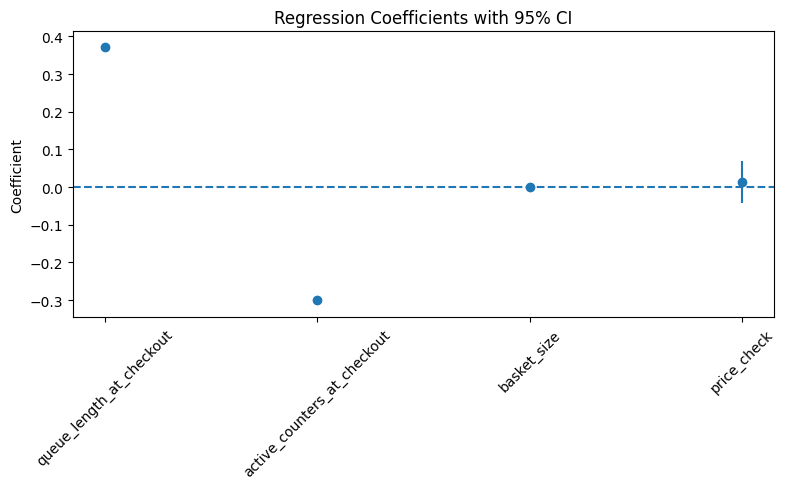

In [155]:
import matplotlib.pyplot as plt

coef_table_no_intercept = coef_table.drop('const')

plt.figure(figsize=(8,5))

plt.errorbar(
    coef_table_no_intercept.index,
    coef_table_no_intercept['Coefficient'],
    yerr=[
        coef_table_no_intercept['Coefficient']
        - coef_table_no_intercept['Lower_95'],

        coef_table_no_intercept['Upper_95']
        - coef_table_no_intercept['Coefficient']
    ],
    fmt='o'
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Regression Coefficients with 95% CI'
)

plt.ylabel(
    'Coefficient'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [157]:
regression_df['predicted_wait'] = (
    model.predict(X)
)

In [158]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(

    regression_df['wait_minutes'],
    regression_df['predicted_wait']

)

print("MAE =", mae)

MAE = 1.3637965995889645


In [159]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(

    regression_df['wait_minutes'],
    regression_df['predicted_wait']

)

print("RMSE =", rmse)

RMSE = 2.011618535081514


In [160]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(

    regression_df['wait_minutes'],
    regression_df['predicted_wait']

)

print("RMSE =", rmse)

RMSE = 2.011618535081514


In [162]:
regression_df['residual'] = (

    regression_df['wait_minutes']

    -

    regression_df['predicted_wait']

)

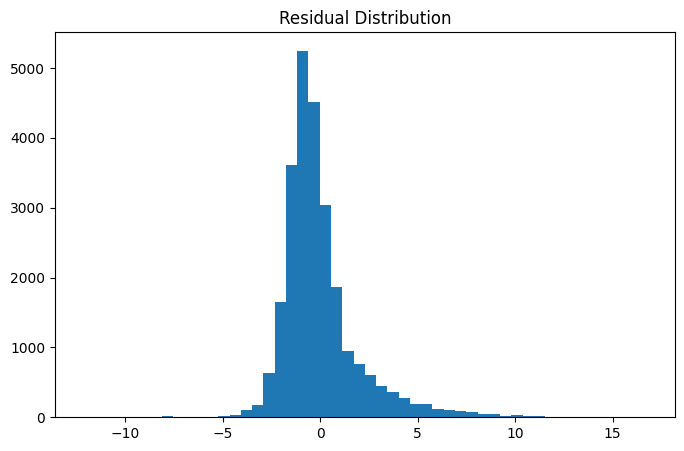

In [164]:
plt.figure(figsize=(8,5))

plt.hist(
    regression_df['residual'],
    bins=50
)

plt.title(
    'Residual Distribution'
)

plt.show()

The residuals are centered around zero, indicating that the model does not exhibit strong systematic bias. However, the distribution is positively skewed 
(towards right as that side has longer tail), suggesting that the model occasionally underestimates waiting times during periods of severe congestion. This indicates that queue length and active counters explain a substantial portion of the waiting time variability, but additional factors may contribute to extreme waiting times.

## Comparing old and new log

In [ ]:
folder_path="Simulated_Dataset/"
xes_path_new = folder_path + "Supermarket_Cashier_Group04.xes"
xes_path2_new = folder_path + "Supermarket_Clerk_Group04.xes"
xes_path3_new = folder_path + "Supermarket_Counter_Group04.xes"
xes_path4_new = folder_path + "Supermarket_Customer_Group04.xes"
xes_path5_new = folder_path + "Supermarket_Manager_Group04.xes"



In [168]:
log_cashier_new = xes_importer.apply(xes_path_new)
log_clerk_new = xes_importer.apply(xes_path2_new)
log_counter_new = xes_importer.apply(xes_path3_new)
log_customer_new = xes_importer.apply(xes_path4_new)
log_manager_new = xes_importer.apply(xes_path5_new)

parsing log, completed traces ::   0%|          | 0/37 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/10 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/18 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/4545 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1 [00:00<?, ?it/s]

In [172]:

log_df_cashier_new = log_converter.apply(log_cashier_new, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_clerk_new = log_converter.apply(log_clerk_new, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_counter_new = log_converter.apply(log_counter_new, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_customer_new = log_converter.apply(log_customer_new, variant=log_converter.Variants.TO_DATA_FRAME)
log_df_manager_new = log_converter.apply(log_manager_new, variant=log_converter.Variants.TO_DATA_FRAME)
#log_df_cashier_new.head(10)

In [173]:
go_checkout_2 = (

    log_df_customer_new[
        log_df_customer_new['concept:name']
        == 'Go to Checkout'
    ]

    .copy()

)

go_checkout_2['date'] = (
    go_checkout_2['time:timestamp']
    .dt.date
)

multiple_visits = (

    go_checkout_2

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .size()

    .reset_index(
        name='checkout_visits'
    )

)

multiple_visits_ = multiple_visits[
    multiple_visits['checkout_visits'] > 1
]

print(
    multiple_visits_
)


Empty DataFrame
Columns: [case:concept:name, date, checkout_visits]
Index: []


In [174]:
print(
    "Customer-day combinations with >1 Go to Checkout:",
    len(multiple_visits_)
)

Customer-day combinations with >1 Go to Checkout: 0


In [175]:
#Creating date column
log_df_customer_new['date'] = (
    log_df_customer_new['time:timestamp']
    .dt.date
)

In [176]:
#Now I go to Checkout Event
go_checkout_2 = (

    log_df_customer_new[

        log_df_customer_new['concept:name']
        == 'Go to Checkout'

    ]

    .copy()

)

In [177]:
#Keep one Go to Checkout per customer-day
go_checkout_2 = (

    go_checkout_2

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [179]:
go_checkout_2 = go_checkout_2[

    [
        'case:concept:name',
        'date',
        'time:timestamp',
        'items'
    ]

]

In [180]:
#renaming for clarity
go_checkout_2 = go_checkout_2.rename(

    columns={

        'time:timestamp':
            'checkout_time',

        'items':
            'basket_size'

    }

)

In [182]:
go_checkout_2.head()

,case:concept:name,date,checkout_time,basket_size
0,0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0
1,1,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0
2,10,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0
3,100,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0
4,1000,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0


In [183]:
#enter queue event
enter_queue_2 = (

    log_df_customer_new[

        log_df_customer_new['concept:name']
        == 'Enter Queue'

    ]

    .copy()

)

enter_queue_2['date'] = (

    enter_queue_2['time:timestamp']

    .dt.date

)

In [184]:
#First Enter Queue per customer-day
enter_queue__2 = (

    enter_queue_2

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [186]:
#first scan df
first_scan_2 = (

    log_df_customer_new[

        log_df_customer_new['concept:name']
        == 'Scan Item'

    ]

    .copy()

)

first_scan_2['date'] = (

    first_scan_2['time:timestamp']

    .dt.date

)

In [187]:
#first scan per customer per day
first_scan_2 = (

    first_scan_2

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'case:concept:name',
            'date'
        ]
    )

    .first()

    .reset_index()

)

In [188]:
#Merge wait time
wait_df_2 = enter_queue_2.merge(

    first_scan_2[
        [
            'case:concept:name',
            'date',
            'time:timestamp'
        ]
    ],

    on=[
        'case:concept:name',
        'date'
    ],

    suffixes=(
        '_enter',
        '_scan'
    )

)

In [189]:
#in minutes
wait_df_2['wait_minutes'] = (

    wait_df_2['time:timestamp_scan']

    -

    wait_df_2['time:timestamp_enter']

).dt.total_seconds() / 60

In [190]:
#no negatives ->verify
wait_df_2[
    wait_df_2['wait_minutes'] < 0
]

,s,concept:name,cnt,x,y,lifecycle:transition,items,time:timestamp_enter,case:concept:name,p,...,pc,mC,mI,iMC,cid,b,clid,date,time:timestamp_scan,wait_minutes


In [193]:
#merging
regression_df_2 = go_checkout_2.merge(

    wait_df_2[
        [
            'case:concept:name',
            'date',
            'wait_minutes'
        ]
    ],

    on=[
        'case:concept:name',
        'date'
    ],

    how='inner'

)

In [194]:
regression_df_2.head()

,case:concept:name,date,checkout_time,basket_size,wait_minutes
0,0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0,0.056233
1,1,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0,0.060083
2,10,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0,0.057000
3,100,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0,0.061383
4,1000,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0,0.043567


In [197]:
# Getting active counters from counter log at the time when customer neters checkout area
#Ensuring intervals_Df exists
counter_events_2 = log_df_counter_new[
    log_df_counter_new['concept:name'].isin(
        ['Open counter','Close counter']
    )
].copy()

counter_events_2 = counter_events_2.sort_values(
    ['case:concept:name','time:timestamp']
)
counter_events_2 = (
    log_df_counter_new[
        log_df_counter_new['concept:name'].isin(
            ['Open counter','Close counter']
        )
    ]
    .sort_values(
        ['case:concept:name','time:timestamp']
    )
)

simulation_end = (
    log_df_counter_new['time:timestamp']
    .max()
)

intervals_2 = []

for counter_id, grp in counter_events_2.groupby(
    'case:concept:name'
):

    grp = grp.sort_values(
        'time:timestamp'
    )

    open_time = None

    for _, row in grp.iterrows():

        activity = row['concept:name']

        if activity == 'Open counter':

            # close previous interval if open exists
            if open_time is not None:

                intervals_2.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

            open_time = row['time:timestamp']

        elif activity == 'Close counter':

            if open_time is not None:

                intervals_2.append({

                    'counter_id': counter_id,
                    'start': open_time,
                    'end': row['time:timestamp']

                })

                open_time = None

    # IMPORTANT
    # Counter opened but never closed

    if open_time is not None:

        intervals_2.append({

            'counter_id': counter_id,
            'start': open_time,
            'end': simulation_end

        })

intervals_df_2 = pd.DataFrame(intervals_2)

print(intervals_df_2.head())
#-----------------------------------------
import pandas as pd

# -----------------------------------------
# Ensure timestamps are datetime
# -----------------------------------------

intervals_df_2['start'] = pd.to_datetime(
    intervals_df_2['start']
)

intervals_df_2['end'] = pd.to_datetime(
    intervals_df_2['end']
)

regression_df_2['checkout_time'] = pd.to_datetime(
    regression_df_2['checkout_time']
)

# -----------------------------------------
# Function:
# Count counters active at checkout time
# -----------------------------------------

def active_counters_at_time(ts):

    return (

        (
            intervals_df_2['start']
            <= ts
        )

        &

        (
            intervals_df_2['end']
            > ts
        )

    ).sum()

# -----------------------------------------
# Compute active counters
# -----------------------------------------

regression_df_2[
    'active_counters_at_checkout'
] = (

    regression_df_2[
        'checkout_time'
    ]

    .apply(
        active_counters_at_time
    )

)

# -----------------------------------------
# Verify
# -----------------------------------------

print(

    regression_df_2[
        [
            'checkout_time',
            'active_counters_at_checkout'
        ]
    ]

    .head()

)

print(
    regression_df_2[
        'active_counters_at_checkout'
    ].describe()
)

  counter_id                     start                              end
0          0 2026-05-17 14:00:00+00:00        2026-05-17 18:00:00+00:00
1          0 2026-05-17 19:00:00+00:00 2026-05-17 22:06:18.088000+00:00
2          0 2026-05-18 14:00:00+00:00        2026-05-18 18:00:00+00:00
3          0 2026-05-18 20:00:00+00:00 2026-05-18 22:06:35.884000+00:00
4          0 2026-05-19 14:00:00+00:00        2026-05-19 18:00:00+00:00
                     checkout_time  active_counters_at_checkout
0 2026-05-17 14:02:23.057000+00:00                            3
1 2026-05-17 14:02:15.112000+00:00                            3
2 2026-05-17 14:18:58.811000+00:00                            3
3 2026-05-17 16:08:52.124000+00:00                            9
4 2026-05-18 18:01:28.569000+00:00                           10
count    4545.000000
mean        7.880748
std         2.631630
min         3.000000
25%         6.000000
50%         9.000000
75%        10.000000
max        11.000000
Name: active_cou

In [198]:
regression_df_2.head()

,case:concept:name,date,checkout_time,basket_size,wait_minutes,active_counters_at_checkout
0,0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0,0.056233,3
1,1,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0,0.060083,3
2,10,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0,0.057000,3
3,100,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0,0.061383,9
4,1000,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0,0.043567,10


In [199]:
#queue state
import pandas as pd
log_df_counter_new['date'] = (
    pd.to_datetime(
        log_df_counter_new['time:timestamp']
    ).dt.date
)
counter_log_2 = log_df_counter_new.copy()

counter_log_2['date'] = (
    counter_log_2['time:timestamp']
    .dt.date
)

scan_events = counter_log_2[
    counter_log_2['concept:name']
    == 'Scan Item'
].copy()
# ------------------------------------------
# Queue Entry Events
# ------------------------------------------

queue_entries_2 = (

    log_df_counter_new[
        log_df_counter_new['concept:name']
        == 'Enter Queue'
    ]

    [
        [
            'id',
            'date',
            'case:concept:name',
            'time:timestamp'
        ]
    ]

    .copy()

)

queue_entries_2.columns = [

    'customer_id',
    'date',
    'counter_id',
    'enter_time'

]

# ------------------------------------------
# First Scan Event
# (customer starts being served)
# ------------------------------------------

first_scan_2 = (

    log_df_counter_new[
        log_df_counter_new['concept:name']
        == 'Scan Item'
    ]

    .sort_values(
        'time:timestamp'
    )

    .groupby(
        [
            'id',
            'date',
            'case:concept:name'
        ]
    )

    .first()

    .reset_index()

)

first_scan_2 = first_scan_2[
    [
        'id',
        'date',
        'case:concept:name',
        'time:timestamp'
    ]
]

first_scan_2.columns = [

    'customer_id',
    'date',
    'counter_id',
    'scan_start'

]

# ------------------------------------------
# Merge
# ------------------------------------------

queue_state_2 = (

    queue_entries_2

    .merge(

        first_scan_2,

        on=[
            'customer_id',
            'date',
            'counter_id',
        ],

        how='left'

    )

)

# ------------------------------------------
# Waiting time in queue
# (sanity check)
# ------------------------------------------

queue_state_2[
    'queue_wait_minutes'
] = (

    queue_state_2['scan_start']
    -
    queue_state_2['enter_time']

).dt.total_seconds() / 60

# ------------------------------------------
# Inspect
# ------------------------------------------

print(
    queue_state_2.head()
)

print(
    queue_state_2.columns
)

   customer_id        date counter_id                       enter_time  \
0          1.0  2026-05-17          0 2026-05-17 14:02:25.112000+00:00   
1          3.0  2026-05-17          0 2026-05-17 14:07:44.745000+00:00   
2          9.0  2026-05-17          0 2026-05-17 14:17:02.996000+00:00   
3         13.0  2026-05-17          0 2026-05-17 14:21:38.385000+00:00   
4         14.0  2026-05-17          0 2026-05-17 14:23:45.328000+00:00   

                        scan_start  queue_wait_minutes  
0 2026-05-17 14:02:28.717000+00:00            0.060083  
1 2026-05-17 14:07:47.540000+00:00            0.046583  
2 2026-05-17 14:17:06.346000+00:00            0.055833  
3 2026-05-17 14:21:41.306000+00:00            0.048683  
4 2026-05-17 14:23:48.045000+00:00            0.045283  
Index(['customer_id', 'date', 'counter_id', 'enter_time', 'scan_start',
       'queue_wait_minutes'],
      dtype='object')


In [ ]:
#not being used anywhere
def queue_length_at_counter_2(counter_id, ts):

    return (

        queue_state_2[

            (queue_state_2['counter_id'] == counter_id)

            &

            (queue_state_2['enter_time'] <= ts)

            &

            (queue_state_2['scan_start'] > ts)

        ]

    ).shape[0]



In [218]:
all_counters_2 = (

    queue_state_2[
        'counter_id'
    ]

    .unique()

)

In [219]:
regression_df_2['checkout_time']

0      2026-05-17 14:02:23.057000+00:00
1      2026-05-17 14:02:15.112000+00:00
2      2026-05-17 14:18:58.811000+00:00
3      2026-05-17 16:08:52.124000+00:00
4      2026-05-18 18:01:28.569000+00:00
                     ...               
4540   2026-05-18 17:54:28.383000+00:00
4541   2026-05-18 17:56:43.503000+00:00
4542   2026-05-18 17:56:48.855000+00:00
4543   2026-05-18 17:58:20.090000+00:00
4544   2026-05-18 17:59:39.482000+00:00
Name: checkout_time, Length: 4545, dtype: datetime64[ns, UTC]

In [220]:
queue_lengths_2 = []

for ts in regression_df_2['checkout_time']:

    q_len = (

        (
            queue_state_2['enter_time']
            <= ts
        )

        &

        (
            queue_state_2['scan_start']
            > ts
        )

    ).sum()

    queue_lengths_2.append(
        q_len
    )

regression_df_2[
    'queue_length_at_checkout'
] = queue_lengths_2

In [221]:
regression_df_2[
    'queue_length_at_checkout'
].describe()

count    4545.000000
mean        1.555336
std         1.848958
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: queue_length_at_checkout, dtype: float64

In [222]:
#rechecking queue state
queue_state_2['queue_wait_minutes'].describe()

count    4545.000000
mean        1.007263
std         1.914915
min         0.037500
25%         0.047450
50%         0.057650
75%         1.103567
max        18.276400
Name: queue_wait_minutes, dtype: float64

In [223]:
regression_df_2.head()

,case:concept:name,date,checkout_time,basket_size,wait_minutes,active_counters_at_checkout,queue_length_at_checkout
0,0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0,0.056233,3,0
1,1,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0,0.060083,3,0
2,10,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0,0.057000,3,0
3,100,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0,0.061383,9,1
4,1000,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0,0.043567,10,0


In [224]:
#Including price checks as indicator behaviour only
log_df_counter_new['date'] = (
    log_df_counter_new['time:timestamp']
    .dt.date
)
price_check_df_2 = (

    log_df_counter_new[
        log_df_counter_new['concept:name']
        == 'Start Price Check'
    ]

    [
        [
            'id',
            'date'
        ]
    ]

    .drop_duplicates()

    .copy()

)

price_check_df_2.columns = [

    'customer_id',
    'date'

]

price_check_df_2[
    'price_check'
] = 1

In [225]:
log_df_counter_new.groupby('id')['date'].nunique().describe()

count    4545.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: date, dtype: float64

In [228]:
print(regression_df_2.head())

  case:concept:name        date                    checkout_time  basket_size  \
0                 0  2026-05-17 2026-05-17 14:02:23.057000+00:00         44.0   
1                 1  2026-05-17 2026-05-17 14:02:15.112000+00:00          8.0   
2                10  2026-05-17 2026-05-17 14:18:58.811000+00:00         77.0   
3               100  2026-05-17 2026-05-17 16:08:52.124000+00:00         73.0   
4              1000  2026-05-18 2026-05-18 18:01:28.569000+00:00         67.0   

   wait_minutes  active_counters_at_checkout  queue_length_at_checkout  
0      0.056233                            3                         0  
1      0.060083                            3                         0  
2      0.057000                            3                         0  
3      0.061383                            9                         1  
4      0.043567                           10                         0  


In [234]:
log_df_counter_new.groupby('id')['date'].nunique().describe()

count    4545.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: date, dtype: float64

In [238]:
print(regression_df_2['customer_id'].dtype)
print(price_check_df_2['customer_id'].dtype)

print(regression_df_2['date'].dtype)
print(price_check_df_2['date'].dtype)

float64
float64
object
object


In [239]:
regression_df['customer_id'] = (
    regression_df['customer_id']
    .astype(float)
)

price_check_df['customer_id'] = (
    price_check_df['customer_id']
    .astype(float)
)

regression_df['date'] = pd.to_datetime(
    regression_df['date']
).dt.date

price_check_df['date'] = pd.to_datetime(
    price_check_df['date']
).dt.date

In [241]:
#test overlap
test_2 = regression_df_2.merge(

    price_check_df_2,

    on=['customer_id','date'],

    how='inner'

)

print(len(test_2))

1819


In [242]:
#ACtual merge

regression_df_2 = regression_df_2.merge(

    price_check_df_2,

    on=['customer_id','date'],

    how='left'

)

In [243]:
regression_df_2['price_check'] = (

    regression_df_2['price_check']

    .fillna(0)

    .astype(int)

)

In [244]:
print(
    regression_df_2['price_check']
    .value_counts()
)


price_check
0    2726
1    1819
Name: count, dtype: int64


In [245]:
regression_df_2.groupby(
    'price_check'
)['wait_minutes'].mean()

price_check
0    1.006408
1    1.008545
Name: wait_minutes, dtype: float64

In [246]:
regression_df_2.head()

,customer_id,date,checkout_time,basket_size,wait_minutes,active_counters_at_checkout,queue_length_at_checkout,price_check
0,0.0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0,0.056233,3,0,1
1,1.0,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0,0.060083,3,0,1
2,10.0,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0,0.057000,3,0,1
3,100.0,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0,0.061383,9,1,1
4,1000.0,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0,0.043567,10,0,1


In [247]:
#saving for future use
regression_df_2.to_csv(
    'regression_df_2.csv',
    index=False
)

In [248]:
regression_df_2.head()

,customer_id,date,checkout_time,basket_size,wait_minutes,active_counters_at_checkout,queue_length_at_checkout,price_check
0,0.0,2026-05-17,2026-05-17 14:02:23.057000+00:00,44.0,0.056233,3,0,1
1,1.0,2026-05-17,2026-05-17 14:02:15.112000+00:00,8.0,0.060083,3,0,1
2,10.0,2026-05-17,2026-05-17 14:18:58.811000+00:00,77.0,0.057000,3,0,1
3,100.0,2026-05-17,2026-05-17 16:08:52.124000+00:00,73.0,0.061383,9,1,1
4,1000.0,2026-05-18,2026-05-18 18:01:28.569000+00:00,67.0,0.043567,10,0,1


In [264]:
regression_df['wait_minutes'].describe()

count    25325.000000
mean         1.462825
std          2.653612
min          0.037500
25%          0.048317
50%          0.058950
75%          1.895917
max         20.680000
Name: wait_minutes, dtype: float64

In [249]:
comparison = pd.DataFrame({

    'Metric': [

        'Mean Wait',
        'Median Wait',
        'P95 Wait',

        'Mean Queue',
        'Median Queue',
        'P95 Queue',

        'Mean Counters'
    ],

    'Old': [

        regression_df['wait_minutes'].mean(),
        regression_df['wait_minutes'].median(),
        regression_df['wait_minutes'].quantile(0.95),

        regression_df['queue_length_at_checkout'].mean(),
        regression_df['queue_length_at_checkout'].median(),
        regression_df['queue_length_at_checkout'].quantile(0.95),

        regression_df['active_counters_at_checkout'].mean()

    ],

    'New': [

        regression_df_2['wait_minutes'].mean(),
        regression_df_2['wait_minutes'].median(),
        regression_df_2['wait_minutes'].quantile(0.95),

        regression_df_2['queue_length_at_checkout'].mean(),
        regression_df_2['queue_length_at_checkout'].median(),
        regression_df_2['queue_length_at_checkout'].quantile(0.95),

        regression_df_2['active_counters_at_checkout'].mean()

    ]

})

print(comparison)

          Metric        Old       New
0      Mean Wait   1.462825  1.007263
1    Median Wait   0.058950  0.057650
2       P95 Wait   7.363343  4.957820
3     Mean Queue   2.403988  1.555336
4   Median Queue   1.000000  1.000000
5      P95 Queue  10.000000  5.000000
6  Mean Counters   8.418045  7.880748


Why mean and median are so different

You have:

Mean   = 1.46 min
Median = 0.059 min

When:

Mean >> Median

it almost always indicates:

Right-skewed distribution

A few large values are dragging the average upward.

What does this imply for your intervention?

This is the key insight:

Your intervention is not improving the typical customer.

The typical customer already waits:


which is essentially nothing.

The intervention is improving the customers who experience congestion.

That's why:

Median Wait
0.059 → 0.058

barely changes.

But:

P95 Wait
7.36 → 4.96

improves substantially.

The intervention had little effect on customers who already experienced negligible waiting times, but substantially reduced congestion-related delays, reducing the 95th percentile waiting time by approximately 33%.

Old vs new comparison

In [269]:
(
    regression_df['wait_minutes'] >= 4
).mean() * 100

np.float64(12.80157946692991)

In [270]:
(
    regression_df_2['wait_minutes'] >= 4
).mean() * 100

np.float64(7.326732673267326)

Why Mann-Whitney Test
Waiting times were highly skewed and violated normality assumptions. Therefore a non-parametric Mann–Whitney U test was preferred over a two-sample t-test when comparing waiting-time distributions between the old and new simulation scenarios.

In [251]:
from scipy.stats import mannwhitneyu

stat,p = mannwhitneyu(

    regression_df['wait_minutes'],
    regression_df_2['wait_minutes'],

    alternative='two-sided'
)

print(p)

1.1443378763393534e-11


If:

p < 0.05

then improvement is statistically significant.

In [262]:
import scipy.stats as st
import numpy as np

def ci95(series):
    series = series.dropna()

    mean = np.mean(series)

    ci = st.t.interval(

        0.95,

        len(series)-1,

        loc=mean,

        scale=st.sem(series)

    )

    return mean, ci[0], ci[1]

print(ci95(regression_df['wait_minutes']))
print(ci95(regression_df_2['wait_minutes']))

(np.float64(1.4628246140177692), np.float64(1.4301408883235054), np.float64(1.495508339712033))
(np.float64(1.007262951961863), np.float64(0.9515769176739284), np.float64(1.0629489862497976))


1.4628246140177692
1.4301408883235054
1.495508339712033
1.007262951961863
0.9515769176739284
1.0629489862497976
  Scenario  Mean Wait  Lower 95% CI  Upper 95% CI
0      Old       1.46          1.43          1.50
1      New       1.01          0.95          1.06


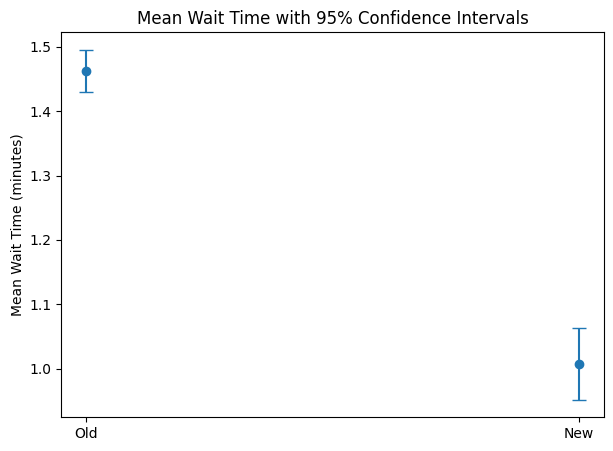

In [263]:
old_mean, old_lower, old_upper = ci95(
    regression_df['wait_minutes']
)

print(old_mean)
print(old_lower)
print(old_upper)
new_mean, new_lower, new_upper = ci95(
    regression_df_2['wait_minutes']
)

print(new_mean)
print(new_lower)
print(new_upper)
ci_table = pd.DataFrame({

    'Scenario': ['Old','New'],

    'Mean Wait': [
        old_mean,
        new_mean
    ],

    'Lower 95% CI': [
        old_lower,
        new_lower
    ],

    'Upper 95% CI': [
        old_upper,
        new_upper
    ]

})

print(ci_table.round(2))

import matplotlib.pyplot as plt

means = [old_mean, new_mean]

lower = [
    old_mean - old_lower,
    new_mean - new_lower
]

upper = [
    old_upper - old_mean,
    new_upper - new_mean
]

plt.figure(figsize=(7,5))

plt.errorbar(

    ['Old','New'],

    means,

    yerr=[lower, upper],

    fmt='o',

    capsize=5

)

plt.ylabel('Mean Wait Time (minutes)')

plt.title(
    'Mean Wait Time with 95% Confidence Intervals'
)

plt.show()

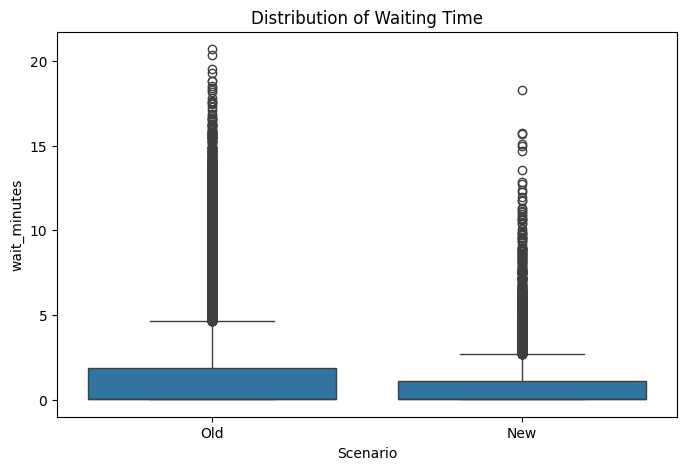

In [255]:
import seaborn as sns

plot_df = pd.concat([

    pd.DataFrame({
        'wait_minutes':
            regression_df['wait_minutes'],
        'Scenario':
            'Old'
    }),

    pd.DataFrame({
        'wait_minutes':
            regression_df_2['wait_minutes'],
        'Scenario':
            'New'
    })

])

plt.figure(figsize=(8,5))

sns.boxplot(

    data=plot_df,

    x='Scenario',

    y='wait_minutes'

)

plt.title(
    'Distribution of Waiting Time'
)

plt.show()

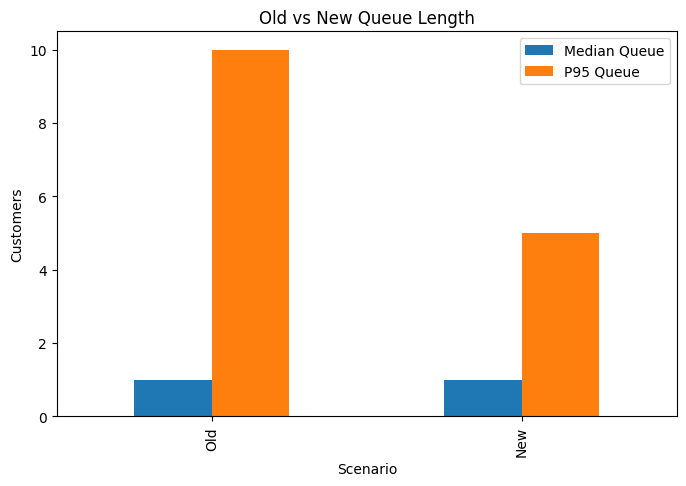

In [257]:
comparison_queue = pd.DataFrame({

    'Scenario': ['Old','New'],

    'Median Queue': [
        regression_df['queue_length_at_checkout'].median(),
        regression_df_2['queue_length_at_checkout'].median()
    ],

    'P95 Queue': [
        regression_df['queue_length_at_checkout'].quantile(0.95),
        regression_df_2['queue_length_at_checkout'].quantile(0.95)
    ]

})

comparison_queue.plot(
    x='Scenario',
    y=['Median Queue','P95 Queue'],
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Customers')
plt.title('Old vs New Queue Length')
plt.show()

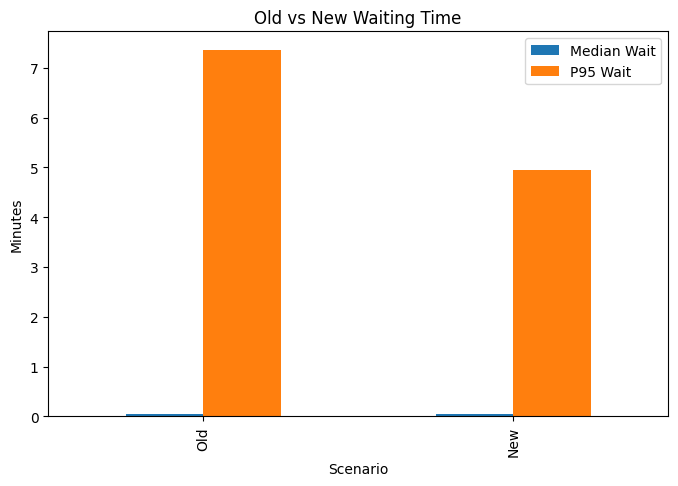

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({

    'Scenario': ['Old','New'],

    'Median Wait': [
        regression_df['wait_minutes'].median(),
        regression_df_2['wait_minutes'].median()
    ],

    'P95 Wait': [
        regression_df['wait_minutes'].quantile(0.95),
        regression_df_2['wait_minutes'].quantile(0.95)
    ]

})

comparison.plot(
    x='Scenario',
    y=['Median Wait','P95 Wait'],
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Minutes')
plt.title('Old vs New Waiting Time')
plt.show()